<img src="https://drive.google.com/uc?id=1DGTpUjounhSh27ZaMRaqmMSC2eYIbXhJ" alt="Alt Text" width="150">


# Boulder County Assessors Office
Analysts:
- Bridget Liesman (East Section)
- Miguel Madrigal (West Section)
- Steven Villalon (East Section)

<br>
<p>Report Date: December 2024</p>

# Introduction

Welcome back to the project, data scientist! Our team has been working diligently to review the available property data and create a KNN algorithm for predicting the home valuation. Our main question throughout this analysis will be to determine the factors that have the greatest affect on the valuation of the home. We will look into physical characteristics of the home, such as number of bathrooms or square footage, as well as location (market area), and quality rating scores. We have multiple tables of raw data available to us and so we will first spend some time reviewing and merging these tables, cleaning the data, and exploring the remaining variables. After this exploration, we will perform statistcal analysis on the variables of interest and use these results to build a KNN model.

In [1]:
# Load dependencies
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
import statistics
from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from scipy.stats import t
import math
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

# Allow all columns to display when we call .head()
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format) #remove scientific notation
#pd.reset_option('display.max_columns') #remove the option above if necessary

# Mount our shared Google Drive so we can load files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Part A - Defining the Question

1.   ### **In your own words, define the objectives that the Boulder County Assessor's Office is asking you to address.**<br>
We are interested in identifying the factors that impact the valuation of residential single family homes in Boulder County. Once we understand the factors that affect home valuation, we will create a KNN algorithm that can predict the value of a home based on those factors.
2.   ### **What is the population of interest? What data is actually available? How could this affect your analysis?**<br>
The population of interest is residential single-family homes in Boulder, CO. In particular, we are looking at Boulder County Market Areas (101, 102, 103, 105, 107, and 109). Six (6) datasets were provided that include details about each building/property.  There may be some factors that affect home valuation that are not included here, such as proximity to a school or renovations done on the home.
3. ### **Provide at least three questions that are interesting, specific, and actionable that could be used to help solve the problem that you defined in Q1.**<br>
  - Which Market Area has the highest/lowest market values?
  - Are the "central features" that legislators feel should be used for property valuation the best or most relevant factors? Are there any others that make a difference, like basement type or gargage?
  - How have sales prices (or valuations) changed over time?
  - Are livable square footage and land acreage valued differently? Is a sq. ft of house valued the same as a sq. ft. of land.
  - Are the home quality assessments doing a good job of reflecting prices?
  - Are new homes valued higher than historic homes?
  - Are there opportunities to collect tax revenue that is currently unrealized?



# Part B - Getting the Data

## 1 - Load the Data

We were provided with 6 datasets for this project. Let's read them all in and have a look at their structure.

In [2]:
# Read building data
building = pd.read_csv("/content/drive/Shareddrives/FALL2024-FinalPythonProject/datasets/building.csv")
building.head()

,strap,bld_num,effective_year_built,design_code,design,quality,quality_code,bldg_class_code,bldg_class,construction_type_code,construction_type,nbr_bed_room,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_rooms_nobath,total_finished_sqft,mainfloor_sqft,bsmt_sqft,bsmt_type_code,bsmt_type,car_storage_type_code,car_storage_type,ext_wall_code,ext_wall,ac,heating
0,R0000008,1,1954,10,1 Story - Ranch,AVERAGE +,31,1212,SINGLE FAM RES IMPROVEMENTS,320.00,Masonry,3.00,1.00,0.00,1.00,5.00,"1,558.00","1,558.00",NaN,NaN,NaN,NaN,NaN,40.00,Brick Veneer,False,True
1,R0000019,1,1970,10,1 Story - Ranch,AVERAGE,30,1212,SINGLE FAM RES IMPROVEMENTS,310.00,Frame,4.00,1.00,1.00,0.00,9.00,942.00,942.00,850.00,BGF,GARDEN BASEMENT FINISHED AREA,NaN,NaN,10.00,Frame Wood/Shake,True,True
2,R0000021,2,1985,60,Studio,GOOD,40,1212,SINGLE FAM RES IMPROVEMENTS,310.00,Frame,1.00,0.00,0.00,0.00,2.00,360.00,NaN,NaN,NaN,NaN,GRD,DETACHED GARAGE,10.00,Frame Wood/Shake,False,True
3,R0000021,1,1990,20,2-3 Story,GOOD +,41,1212,SINGLE FAM RES IMPROVEMENTS,310.00,Frame,3.00,1.00,2.00,1.00,7.00,"2,042.00","1,170.00",334.00,BSF,SUBTERRANEAN BASEMENT FINISHED AREA,GRC,CARPORT AREA,10.00,Frame Wood/Shake,False,True
4,R0000024,1,1960,20,2-3 Story,GOOD,40,1212,SINGLE FAM RES IMPROVEMENTS,320.00,Masonry,3.00,2.00,0.00,1.00,8.00,"1,370.00",799.00,465.00,BGF,GARDEN BASEMENT FINISHED AREA,GRA,ATTACHED GARAGE AREA,70.00,Brick on Block,False,True


In [3]:
building.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3957 entries, 0 to 3956
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   strap                   3957 non-null   object 
 1   bld_num                 3957 non-null   int64  
 2   effective_year_built    3957 non-null   int64  
 3   design_code             3957 non-null   int64  
 4   design                  3957 non-null   object 
 5   quality                 3957 non-null   object 
 6   quality_code            3957 non-null   int64  
 7   bldg_class_code         3957 non-null   int64  
 8   bldg_class              3957 non-null   object 
 9   construction_type_code  3743 non-null   float64
 10  construction_type       3736 non-null   object 
 11  nbr_bed_room            3957 non-null   float64
 12  nbr_full_baths          3957 non-null   float64
 13  nbr_three_qtr_baths     3957 non-null   float64
 14  nbr_half_baths          3957 non-null   

In [4]:
building.describe(include="all")

,strap,bld_num,effective_year_built,design_code,design,quality,quality_code,bldg_class_code,bldg_class,construction_type_code,construction_type,nbr_bed_room,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_rooms_nobath,total_finished_sqft,mainfloor_sqft,bsmt_sqft,bsmt_type_code,bsmt_type,car_storage_type_code,car_storage_type,ext_wall_code,ext_wall,ac,heating
count,3957,"3,957.00","3,957.00","3,957.00",3957,3957,"3,957.00","3,957.00",3957,"3,743.00",3736,"3,957.00","3,957.00","3,957.00","3,957.00","3,957.00","3,560.00","3,549.00","2,241.00",2241,2241,2374,2374,"3,793.00",3785,3957,3957
unique,3429,NaN,NaN,NaN,17,15,NaN,NaN,3,NaN,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,9,6,6,NaN,14,2,2
top,R0006297,NaN,NaN,NaN,2-3 Story,AVERAGE,NaN,NaN,SINGLE FAM RES IMPROVEMENTS,NaN,Frame,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BSF,SUBTERRANEAN BASEMENT FINISHED AREA,GRD,DETACHED GARAGE,NaN,Frame Wood/Shake,False,True
freq,4,NaN,NaN,NaN,2139,932,NaN,NaN,3433,NaN,1931,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,965,965,1029,1029,NaN,1496,2899,3769
mean,NaN,1.14,"1,986.50",37.94,NaN,NaN,38.35,"1,212.24",NaN,314.90,NaN,3.18,1.51,0.65,0.36,7.00,"1,998.97","1,360.68",853.15,NaN,NaN,NaN,NaN,39.04,NaN,NaN,NaN
std,NaN,0.37,16.08,76.82,NaN,NaN,8.73,9.79,NaN,5.79,NaN,1.77,1.00,0.86,0.54,3.26,965.51,577.32,471.16,NaN,NaN,NaN,NaN,29.07,NaN,NaN,NaN
min,NaN,1.00,"1,905.00",10.00,NaN,NaN,5.00,600.00,NaN,300.00,NaN,0.00,0.00,0.00,0.00,0.00,144.00,30.00,47.00,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN
25%,NaN,1.00,"1,975.00",10.00,NaN,NaN,31.00,"1,212.00",NaN,310.00,NaN,2.00,1.00,0.00,0.00,5.00,"1,303.50",980.00,504.00,NaN,NaN,NaN,NaN,10.00,NaN,NaN,NaN
50%,NaN,1.00,"1,985.00",20.00,NaN,NaN,40.00,"1,212.00",NaN,310.00,NaN,3.00,1.00,0.00,0.00,7.00,"1,847.00","1,275.00",791.00,NaN,NaN,NaN,NaN,30.00,NaN,NaN,NaN
75%,NaN,1.00,"1,999.00",20.00,NaN,NaN,42.00,"1,212.00",NaN,320.00,NaN,4.00,2.00,1.00,1.00,9.00,"2,479.00","1,650.00","1,122.00",NaN,NaN,NaN,NaN,70.00,NaN,NaN,NaN


In [5]:
# Read land data
land = pd.read_csv("/content/drive/Shareddrives/FALL2024-FinalPythonProject/datasets/land.csv")
land.head()

,strap,land_class,land_class_dscr,sqft,acreage
0,R0000008,1112,SINGLE FAM.RES.-LAND,6801,0.16
1,R0000019,1112,SINGLE FAM.RES.-LAND,3606,0.08
2,R0000021,1112,SINGLE FAM.RES.-LAND,6884,0.16
3,R0000024,1112,SINGLE FAM.RES.-LAND,7245,0.17
4,R0000026,1112,SINGLE FAM.RES.-LAND,12737,0.29


In [6]:
land.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3433 entries, 0 to 3432
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   strap            3433 non-null   object 
 1   land_class       3433 non-null   int64  
 2   land_class_dscr  3433 non-null   object 
 3   sqft             3433 non-null   int64  
 4   acreage          3433 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 134.2+ KB


In [7]:
land.describe(include="all")

,strap,land_class,land_class_dscr,sqft,acreage
count,3433,"3,433.00",3433,"3,433.00","3,433.00"
unique,3431,NaN,4,NaN,NaN
top,R0000110,NaN,SINGLE FAM.RES.-LAND,NaN,NaN
freq,2,NaN,2927,NaN,NaN
mean,NaN,"1,112.16",NaN,"8,807.52",0.20
std,NaN,17.33,NaN,"11,813.44",0.27
min,NaN,100.00,NaN,25.00,0.00
25%,NaN,"1,112.00",NaN,"5,552.00",0.13
50%,NaN,"1,112.00",NaN,"6,911.00",0.16
75%,NaN,"1,112.00",NaN,"9,747.00",0.22


In [8]:
property = pd.read_csv("/content/drive/Shareddrives/FALL2024-FinalPythonProject/datasets/property.csv")
property.head()

,strap,market_area,address,unincorporated,sub_code,sub_dscr,section,township,range,mill_levy,folio
0,R0000008,102,"2002 COLUMBINE AVE, BOULDER CO",False,3822,INTERURBAN PARK - BO,6,1S,70,86.36,157706112001
1,R0000019,109,"2434 BLUFF ST, BOULDER CO",False,850,BOURGOGNE-PINOT SUB - BO,30,1N,70,86.36,146330639001
2,R0000021,105,"1219 6TH ST, BOULDER CO",False,8424,VERMONT - BO,36,1N,71,86.36,146136135006
3,R0000024,105,"655 MARINE ST, BOULDER CO",False,7434,SMITHS TO WEST BOULDER - BO,36,1N,71,86.36,146136122012
4,R0000026,102,"907 12TH ST, BOULDER CO",False,8343,UNIVERSITY PLACE - BO,31,1N,70,86.36,146331314010


In [9]:
property.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3431 entries, 0 to 3430
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   strap           3431 non-null   object 
 1   market_area     3431 non-null   int64  
 2   address         3431 non-null   object 
 3   unincorporated  3431 non-null   bool   
 4   sub_code        3431 non-null   int64  
 5   sub_dscr        3431 non-null   object 
 6   section         3431 non-null   int64  
 7   township        3431 non-null   object 
 8   range           3431 non-null   int64  
 9   mill_levy       3431 non-null   float64
 10  folio           3431 non-null   object 
dtypes: bool(1), float64(1), int64(4), object(5)
memory usage: 271.5+ KB


In [10]:
property.describe(include="all")

,strap,market_area,address,unincorporated,sub_code,sub_dscr,section,township,range,mill_levy,folio
count,3431,"3,431.00",3431,3431,"3,431.00",3431,"3,431.00",3431,"3,431.00","3,431.00",3431
unique,3431,NaN,3425,2,NaN,262,NaN,2,NaN,NaN,3429
top,R0000008,NaN,"2425 PINE ST, BOULDER CO",False,NaN,UNIVERSITY PLACE - BO,NaN,1N,NaN,NaN,146330442009
freq,1,NaN,2,3413,NaN,563,NaN,2966,NaN,NaN,2
mean,NaN,104.71,NaN,NaN,"4,988.67",NaN,27.77,NaN,70.33,86.61,NaN
std,NaN,2.85,NaN,NaN,"3,099.82",NaN,9.22,NaN,0.47,2.26,NaN
min,NaN,101.00,NaN,NaN,9.00,NaN,1.00,NaN,70.00,74.71,NaN
25%,NaN,102.00,NaN,NaN,"1,913.00",NaN,29.00,NaN,70.00,86.36,NaN
50%,NaN,103.00,NaN,NaN,"4,888.00",NaN,30.00,NaN,70.00,86.36,NaN
75%,NaN,107.00,NaN,NaN,"8,343.00",NaN,31.00,NaN,71.00,86.36,NaN


In [11]:
sales = pd.read_csv("/content/drive/Shareddrives/FALL2024-FinalPythonProject/datasets/sales.csv")
sales.head()

,strap,transaction_date,sales_cd,sales_cd_dscr,price
0,R0000008,1978-01-03,Q,qualified,65000
1,R0000019,1980-08-13,U,unqualified,75000
2,R0000019,1985-04-08,U,unqualified,110600
3,R0000019,1992-04-22,Q,qualified,126400
4,R0000019,2000-06-02,Q,qualified,332000


In [12]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9598 entries, 0 to 9597
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   strap             9598 non-null   object
 1   transaction_date  9598 non-null   object
 2   sales_cd          9598 non-null   object
 3   sales_cd_dscr     9598 non-null   object
 4   price             9598 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 375.0+ KB


In [13]:
sales.describe(include="all")

,strap,transaction_date,sales_cd,sales_cd_dscr,price
count,9598,9598,9598,9598,"9,598.00"
unique,3239,6318,3,3,NaN
top,R0081613,2005-06-30,Q,qualified,NaN
freq,11,9,5865,5865,NaN
mean,NaN,NaN,NaN,NaN,"593,005.16"
std,NaN,NaN,NaN,NaN,"804,135.11"
min,NaN,NaN,NaN,NaN,100.00
25%,NaN,NaN,NaN,NaN,"127,500.00"
50%,NaN,NaN,NaN,NaN,"335,000.00"
75%,NaN,NaN,NaN,NaN,"741,479.50"


In [14]:
time_trend_adjustments = pd.read_csv("/content/drive/Shareddrives/FALL2024-FinalPythonProject/datasets/time_trend_adjustments.csv", index_col=0)
time_trend_adjustments.head()

,year,month,market_area_101,market_area_102,market_area_103,market_area_104,market_area_105,market_area_106,market_area_107,market_area_108,market_area_109
0,2017,7,1.46,1.61,1.64,1.52,1.55,1.57,1.59,1.30,1.41
1,2017,8,1.45,1.60,1.63,1.51,1.55,1.57,1.58,1.30,1.41
2,2017,9,1.44,1.59,1.62,1.50,1.54,1.56,1.57,1.30,1.41
3,2017,10,1.43,1.58,1.61,1.49,1.54,1.55,1.56,1.30,1.39
4,2017,11,1.42,1.57,1.60,1.48,1.53,1.54,1.55,1.30,1.38


In [15]:
time_trend_adjustments.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, 0 to 59
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   year             60 non-null     int64  
 1   month            60 non-null     int64  
 2   market_area_101  60 non-null     float64
 3   market_area_102  60 non-null     float64
 4   market_area_103  60 non-null     float64
 5   market_area_104  60 non-null     float64
 6   market_area_105  60 non-null     float64
 7   market_area_106  60 non-null     float64
 8   market_area_107  60 non-null     float64
 9   market_area_108  60 non-null     float64
 10  market_area_109  60 non-null     float64
dtypes: float64(9), int64(2)
memory usage: 5.6 KB


In [16]:
time_trend_adjustments.describe(include="all")

,year,month,market_area_101,market_area_102,market_area_103,market_area_104,market_area_105,market_area_106,market_area_107,market_area_108,market_area_109
count,60.00,60.00,60.00,60.00,60.00,60.00,60.00,60.00,60.00,60.00,60.00
mean,"2,019.50",6.50,1.29,1.38,1.38,1.34,1.39,1.36,1.37,1.24,1.26
std,1.51,3.48,0.14,0.18,0.19,0.14,0.17,0.18,0.16,0.10,0.12
min,"2,017.00",1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,"2,018.00",3.75,1.18,1.26,1.24,1.29,1.31,1.22,1.28,1.18,1.20
50%,"2,019.50",6.50,1.37,1.46,1.46,1.40,1.48,1.46,1.45,1.30,1.30
75%,"2,021.00",9.25,1.40,1.50,1.50,1.43,1.50,1.47,1.45,1.30,1.34
max,"2,022.00",12.00,1.46,1.61,1.64,1.52,1.55,1.57,1.59,1.30,1.41


In [17]:
valuations = pd.read_csv("/content/drive/Shareddrives/FALL2024-FinalPythonProject/datasets/valuations.csv")
valuations.head()

,strap,tax_yr,bld_appraised_val,land_appraised_val,total_appraised_val,bld_assessed_val,land_assessed_val,total_assessed_val
0,R0000008,2024,242500,874000,1116500,"16,248.00",NaN,71121
1,R0000019,2024,268200,757100,1025300,"17,969.00",NaN,65010
2,R0000021,2024,991300,1053600,2044900,"66,418.00",NaN,133323
3,R0000024,2024,531300,797000,1328300,"31,912.00",NaN,85311
4,R0000026,2024,1051300,1238700,2290000,"70,437.00",NaN,149745


In [18]:
valuations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3431 entries, 0 to 3430
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   strap                3431 non-null   object 
 1   tax_yr               3431 non-null   int64  
 2   bld_appraised_val    3431 non-null   int64  
 3   land_appraised_val   3431 non-null   int64  
 4   total_appraised_val  3431 non-null   int64  
 5   bld_assessed_val     3429 non-null   float64
 6   land_assessed_val    0 non-null      float64
 7   total_assessed_val   3431 non-null   int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 214.6+ KB


In [19]:
valuations.describe(include="all")

,strap,tax_yr,bld_appraised_val,land_appraised_val,total_appraised_val,bld_assessed_val,land_assessed_val,total_assessed_val
count,3431,"3,431.00","3,431.00","3,431.00","3,431.00","3,429.00",0.00,"3,431.00"
unique,3431,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,R0000008,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,"2,024.00","887,093.26","1,179,283.30","2,066,376.55","59,293.71",NaN,"134,813.82"
std,NaN,0.00,"771,078.90","567,513.38","1,138,241.69","51,705.01",NaN,"76,254.95"
min,NaN,"2,024.00",0.00,"210,175.00","246,800.00",0.00,NaN,"12,851.00"
25%,NaN,"2,024.00","384,250.00","836,800.00","1,340,150.00","25,581.00",NaN,"86,118.50"
50%,NaN,"2,024.00","682,400.00","1,027,900.00","1,741,800.00","45,634.00",NaN,"113,109.00"
75%,NaN,"2,024.00","1,123,200.00","1,382,300.00","2,427,450.00","75,228.00",NaN,"158,961.00"


## 2 - Create an Adjusted Sales Price

We were provided with Time Trend Adjustments for Sales prices for transactions between 2017 and 2022. No adjustment factor is necessary for recent sales (2023 and 2024 transactions). Let's use these to adjust the sale price data.

In [20]:
# Melt the data so each year, month, and market area are in one row with the corresponding adjustment factor
time_trend_adjustments_tidy = time_trend_adjustments.melt(id_vars=['year','month'],
                                                          var_name='market_area',
                                                          value_name='adjustment_factor')

# Tidy the values in the market_area column to get rid of "market_area_" and convert the type to int
time_trend_adjustments_tidy.market_area = time_trend_adjustments_tidy.market_area.str.replace('market_area_', '').astype('int64')
time_trend_adjustments_tidy.sample(5)

,year,month,market_area,adjustment_factor
533,2021,12,109,1.06
446,2019,9,108,1.30
267,2019,10,105,1.50
339,2020,10,106,1.32
321,2019,4,106,1.46


In [21]:
# Tidy valuations
# Melt the data so each value type is in one row
valuations_tidy = valuations.melt(id_vars=['strap','tax_yr'],
                                  var_name='value_type',
                                  value_name='value')

# Split the value_type columns to put characteristic (bld, land, or total) and evaluation_type (appraised or assessed) on each row
valuations_tidy['characteristic'] = valuations_tidy.value_type.str.split('_', expand=True)[0]
valuations_tidy['evaluation_type'] = valuations_tidy.value_type.str.split('_', expand=True)[1]

# Drop the old value_type column
valuations_tidy = valuations_tidy.drop(columns='value_type')
valuations_tidy.sample(5)

,strap,tax_yr,value,characteristic,evaluation_type
6102,R0008531,2024,"1,866,600.00",land,appraised
11843,R0005095,2024,"73,285.00",bld,assessed
19161,R0006523,2024,"137,518.00",total,assessed
18577,R0004698,2024,"91,040.00",total,assessed
2182,R0007083,2024,"941,700.00",bld,appraised


In [22]:
# Convert sales transaction date to datetime object
sales['transaction_date'] = pd.to_datetime(sales['transaction_date'])

#Merge the market_area code for each property from the property df to the sales df
sales1 = sales.merge(property[['strap','market_area']],
            how='left',
            on='strap')
sales1.sample(5)

,strap,transaction_date,sales_cd,sales_cd_dscr,price,market_area
886,R0000988,2001-07-03,Q,qualified,575000,102
981,R0001053,2016-09-01,U,unqualified,985000,105
7262,R0008394,1987-10-23,Q,qualified,225000,101
7129,R0008280,1974-06-18,U,unqualified,26300,101
7549,R0008708,1975-06-11,U,unqualified,62500,102


In [23]:
# Merge the corresponding adjustment factor from the time_trend_adjustments_tidy to the sales table using time and location
sales2 = sales1.merge(time_trend_adjustments_tidy,
            how='left',
            left_on=[sales['transaction_date'].dt.year, sales['transaction_date'].dt.month, 'market_area'],
            right_on=['year','month', 'market_area'])
sales2.sample(5)

,strap,transaction_date,sales_cd,sales_cd_dscr,price,market_area,year,month,adjustment_factor
8968,R0098424,1992-01-16,Q,qualified,170000,109,1992,1,NaN
1316,R0001517,1990-05-02,Q,qualified,240000,107,1990,5,NaN
8055,R0033326,1973-10-03,U,unqualified,66000,103,1973,10,NaN
2880,R0003474,1990-08-31,U,unqualified,90000,102,1990,8,NaN
3393,R0004062,1983-08-02,U,unqualified,80000,109,1983,8,NaN


In [24]:
# Add an adjustment_factor of 1 for sales in 2023 and 2024
sales2.loc[sales2[(sales2['adjustment_factor'].isnull()) & (sales['transaction_date'].dt.year >= 2023)].index, 'adjustment_factor'] = 1

In [25]:
# Multiply the sale price by the adjustment factor and save as adjusted_sales_price
sales2['adjusted_sales_price'] = sales2['price']*sales2['adjustment_factor']
sales2.sample(5)

,strap,transaction_date,sales_cd,sales_cd_dscr,price,market_area,year,month,adjustment_factor,adjusted_sales_price
9483,R0144313,1992-12-23,U,unqualified,150000,101,1992,12,NaN,NaN
8344,R0071843,1994-11-21,Q,qualified,290500,107,1994,11,NaN,NaN
9175,R0106580,1991-09-27,Q,qualified,151100,105,1991,9,NaN,NaN
3729,R0004454,2021-05-03,U,unqualified,2760000,107,2021,5,1.26,"3,489,468.00"
3688,R0004407,1976-06-08,Q,qualified,32300,101,1976,6,NaN,NaN


In [26]:
# Drop year and month since we already have this info in transaction_date
sales3 = sales2.drop(columns=['year', 'month'])
sales3.sample(5)

,strap,transaction_date,sales_cd,sales_cd_dscr,price,market_area,adjustment_factor,adjusted_sales_price
328,R0000390,2009-11-17,U,unqualified,720500,105,NaN,NaN
92,R0000122,1996-08-01,U,unqualified,860000,103,NaN,NaN
6048,R0007145,1989-09-01,U,unqualified,133500,109,NaN,NaN
9206,R0107079,2010-10-20,Q,qualified,347200,105,NaN,NaN
5505,R0006517,1983-06-03,Q,qualified,190000,103,NaN,NaN


In [27]:
sales3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9598 entries, 0 to 9597
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   strap                 9598 non-null   object        
 1   transaction_date      9598 non-null   datetime64[ns]
 2   sales_cd              9598 non-null   object        
 3   sales_cd_dscr         9598 non-null   object        
 4   price                 9598 non-null   int64         
 5   market_area           9598 non-null   int64         
 6   adjustment_factor     1042 non-null   float64       
 7   adjusted_sales_price  1042 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 600.0+ KB


For each of the 9,598 rows in our original sales dataframe, we have added the corresponding market area, adjustment factor, and adjusted sales price. Note that we only have adjustment factors for dates beginning in 2017, so all sales that occurred before 2017 will not have an adjusted price value. We only have an adjusted sales price for 1,042 transactions.

## 3 - Join remaining tables and tidy the data

In [28]:
# Join Valuations

joined_df1 = sales3.merge(valuations,
                          how='left',
                          on='strap')

# Change datatype to category
joined_df1[['market_area', 'sales_cd_dscr']] = joined_df1[['market_area', 'sales_cd_dscr']].astype('category')

# Drop unnecessary columns
joined_df1 = joined_df1.drop(columns=['tax_yr', 'sales_cd'])

# Rename valuations columns (so we can remember when these were taken)
joined_df1.rename(columns={'bld_appraised_val': 'bld_appraised_val_2024',
                   'land_appraised_val': 'land_appraised_val_2024',
                   'total_appraised_val': 'total_appraised_val_2024',
                   'bld_assessed_val': 'bld_assessed_val_2024',
                   'land_assessed_val': 'land_assessed_val_2024',
                   'total_assessed_val': 'total_assessed_val_2024'}, inplace=True)

# Land assessed value column is blank but we can fill it in
joined_df1['land_assessed_val_2024'] = joined_df1['total_assessed_val_2024'] - joined_df1['bld_assessed_val_2024']

joined_df1.sample(5)

,strap,transaction_date,sales_cd_dscr,price,market_area,adjustment_factor,adjusted_sales_price,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024
7007,R0008167,2006-09-07,qualified,1877700,103,NaN,NaN,1904300,2342800,4247100,"127,588.00","153,283.00",280871
5642,R0006695,1999-09-16,qualified,275000,109,NaN,NaN,774700,699100,1473800,"51,905.00","43,155.00",95060
7424,R0008554,1996-03-25,unqualified,184000,109,NaN,NaN,193400,987000,1180400,"12,958.00","62,444.00",75402
3846,R0004635,1987-07-29,qualified,128500,109,NaN,NaN,946700,1099100,2045800,"63,429.00","69,955.00",133384
2465,R0002961,1997-08-01,qualified,274900,102,NaN,NaN,978000,751100,1729100,"65,526.00","46,639.00",112165


In [29]:
joined_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9598 entries, 0 to 9597
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   strap                     9598 non-null   object        
 1   transaction_date          9598 non-null   datetime64[ns]
 2   sales_cd_dscr             9598 non-null   category      
 3   price                     9598 non-null   int64         
 4   market_area               9598 non-null   category      
 5   adjustment_factor         1042 non-null   float64       
 6   adjusted_sales_price      1042 non-null   float64       
 7   bld_appraised_val_2024    9598 non-null   int64         
 8   land_appraised_val_2024   9598 non-null   int64         
 9   total_appraised_val_2024  9598 non-null   int64         
 10  bld_assessed_val_2024     9596 non-null   float64       
 11  land_assessed_val_2024    9596 non-null   float64       
 12  total_assessed_val_2

**NOTE:** There are 2 nulls in columns 10 and 11 that are null. There doesn't appear to be a way to calculate them.

In [30]:
# Join Land

# Remove duplicate rows from land table (there were 2 straps that were duplicated)
land_cleaned = land.drop_duplicates(subset='strap')

# Join land dataframe
joined_df2 = joined_df1.merge(land_cleaned,
                              how='left',
                              on='strap')

# Drop unnecessary columns
joined_df2 = joined_df2.drop(columns=['land_class'])

# Change Datatype to Category
joined_df2['land_class_dscr'] = joined_df2['land_class_dscr'].astype('category')

# Rename columns
joined_df2.rename(columns={'sqft': 'land_sqft',
                           'acreage': 'land_acreage'}, inplace=True)

joined_df2.sample(5)

,strap,transaction_date,sales_cd_dscr,price,market_area,adjustment_factor,adjusted_sales_price,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,land_class_dscr,land_sqft,land_acreage
858,R0000966,1987-01-05,qualified,105300,109,NaN,NaN,445500,972200,1417700,"29,849.00","61,452.00",91301,DUP/TRIPLEXES-LAND,7080,0.16
7098,R0008253,1977-09-23,unqualified,89000,102,NaN,NaN,745000,827200,1572200,"46,230.00","55,422.00",101652,SINGLE FAM.RES.-LAND,6092,0.14
8814,R0085586,1980-12-04,qualified,78000,109,NaN,NaN,2478300,939600,3417900,"166,046.00","59,268.00",225314,SINGLE FAM.RES.-LAND,5555,0.13
6850,R0008024,1971-09-13,unqualified,35800,105,NaN,NaN,755600,1150200,1905800,"50,625.00","73,379.00",124004,DUP/TRIPLEXES-LAND,8204,0.19
3727,R0004454,2007-03-23,qualified,2000000,107,NaN,NaN,2653700,2303800,4957500,"174,113.00","154,355.00",328468,SINGLE FAM.RES.-LAND,19975,0.46


In [31]:
joined_df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9598 entries, 0 to 9597
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   strap                     9598 non-null   object        
 1   transaction_date          9598 non-null   datetime64[ns]
 2   sales_cd_dscr             9598 non-null   category      
 3   price                     9598 non-null   int64         
 4   market_area               9598 non-null   category      
 5   adjustment_factor         1042 non-null   float64       
 6   adjusted_sales_price      1042 non-null   float64       
 7   bld_appraised_val_2024    9598 non-null   int64         
 8   land_appraised_val_2024   9598 non-null   int64         
 9   total_appraised_val_2024  9598 non-null   int64         
 10  bld_assessed_val_2024     9596 non-null   float64       
 11  land_assessed_val_2024    9596 non-null   float64       
 12  total_assessed_val_2

In [32]:
# Join Property

joined_df3 = joined_df2.merge(property,
                              how='left',
                              on='strap')

# Drop unnecessary columns
joined_df3 = joined_df3.drop(columns=['market_area_y', 'section', 'township', 'range', 'folio', 'sub_code'])

# Rename columns
joined_df3.rename(columns={'market_area_x': 'market_area'}, inplace=True)

joined_df3.sample(5)

,strap,transaction_date,sales_cd_dscr,price,market_area,adjustment_factor,adjusted_sales_price,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,land_class_dscr,land_sqft,land_acreage,address,unincorporated,sub_dscr,mill_levy
3527,R0004202,2000-01-07,unqualified,237500,102,NaN,NaN,762600,745700,1508300,"51,094.00","46,277.00",97371,DUP/TRIPLEXES-LAND,6327,0.14,"2136 BASELINE RD, BOULDER CO",False,INTERURBAN PARK - BO,86.36
3575,R0004252,2005-08-01,pending qualification,595000,109,NaN,NaN,752800,1104800,1857600,"50,438.00","70,336.00",120774,SINGLE FAM.RES.-LAND,7679,0.18,"1821 MAPLETON AVE, BOULDER CO",False,BOULDER O T EAST & WEST & NORTH - BO,86.36
4864,R0005816,1998-08-17,qualified,293000,109,NaN,NaN,654700,683000,1337700,"43,865.00","42,076.00",85941,SINGLE FAM.RES.-LAND,3494,0.08,"2418 PINE ST, BOULDER CO",False,ACANTHUS SUB - BO,86.36
3392,R0004061,1982-05-12,unqualified,75000,105,NaN,NaN,857800,1172700,2030500,"57,473.00","74,886.00",132359,SINGLE FAM.RES.-LAND,8527,0.20,"1315 5TH ST, BOULDER CO",False,VERMONT - BO,86.36
5982,R0007079,1987-02-11,qualified,217900,102,NaN,NaN,1346200,1330000,2676200,"90,195.00","85,425.00",175620,SINGLE FAM.RES.-LAND,16961,0.39,"2250 MARIPOSA AVE, BOULDER CO",False,OAK PARK & SOUTH OAK PARK - BO,86.36


In [33]:
joined_df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9598 entries, 0 to 9597
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   strap                     9598 non-null   object        
 1   transaction_date          9598 non-null   datetime64[ns]
 2   sales_cd_dscr             9598 non-null   category      
 3   price                     9598 non-null   int64         
 4   market_area               9598 non-null   category      
 5   adjustment_factor         1042 non-null   float64       
 6   adjusted_sales_price      1042 non-null   float64       
 7   bld_appraised_val_2024    9598 non-null   int64         
 8   land_appraised_val_2024   9598 non-null   int64         
 9   total_appraised_val_2024  9598 non-null   int64         
 10  bld_assessed_val_2024     9596 non-null   float64       
 11  land_assessed_val_2024    9596 non-null   float64       
 12  total_assessed_val_2

<p>Before we go further, let's note that joined_df3 has one row per sales transaction so there are multiple rows per strap.</p>

<p>We would like to get to a dataframe that has 1 row per strap, so we are going to make some edits at this stage to eliminate all the extra rows. There is some interesting data there and so we are going to do the following:</p>

*   Filter the dataset to only the most recent sales transaction
*   Create a column to count the number of transactions we have available for each property

<p>We can always choose to analyze the sales data separately.</p>

<p>In filtering the dataset, we also noticed that there are 38 instances where there are 2 rows for the max transaction date. There were instance where both rows were actual duplicates and others where one transaction was qualified and the other unqualified. To make sure we only get one row per strap, we will sort the data frame by transaction date and take the final value.</p>

In [34]:
# Get row with most recent transaction date
joined_df3_filtered = joined_df3[joined_df3['transaction_date'] == joined_df3.groupby('strap')['transaction_date'].transform('max')]
len(joined_df3_filtered.strap.value_counts()[joined_df3_filtered.strap.value_counts()>1])

38

In [35]:
# Sort the data by transaction date
joined_df3_sorted = joined_df3_filtered.sort_values(by=['strap', 'transaction_date', 'sales_cd_dscr'], ascending=[True, True, False]) #sorting sales_cd_dscr descending to try to get "qualified"

# Get the row number of the last transaction for each strap (this will eliminate ties)
max_indices = joined_df3_sorted.groupby('strap')['transaction_date'].idxmax()

# Filter the dataframe
joined_df3_sorted = joined_df3_filtered.loc[max_indices].copy()
joined_df3_sorted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3239 entries, 0 to 9597
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   strap                     3239 non-null   object        
 1   transaction_date          3239 non-null   datetime64[ns]
 2   sales_cd_dscr             3239 non-null   category      
 3   price                     3239 non-null   int64         
 4   market_area               3239 non-null   category      
 5   adjustment_factor         862 non-null    float64       
 6   adjusted_sales_price      862 non-null    float64       
 7   bld_appraised_val_2024    3239 non-null   int64         
 8   land_appraised_val_2024   3239 non-null   int64         
 9   total_appraised_val_2024  3239 non-null   int64         
 10  bld_assessed_val_2024     3237 non-null   float64       
 11  land_assessed_val_2024    3237 non-null   float64       
 12  total_assessed_val_2024  

In [36]:
# Add column for count of transations
joined_df3_trxn_cnts = joined_df3.groupby('strap').size().rename('num_trxns')

# Join transaction counts to our
joined_df3_final = joined_df3_sorted.merge(joined_df3_trxn_cnts,
                              how='left',
                              on='strap')

# Rename transation date column
joined_df3_final.rename(columns={'transaction_date': 'most_recent_trxn_date'}, inplace=True)

joined_df3_final.sample(5)

,strap,most_recent_trxn_date,sales_cd_dscr,price,market_area,adjustment_factor,adjusted_sales_price,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,land_class_dscr,land_sqft,land_acreage,address,unincorporated,sub_dscr,mill_levy,num_trxns
94,R0000366,2022-01-10,qualified,1030000,102,1.07,"1,099,628.00",426300,639500,1065800,"24,877.00","42,847.00",67724,SINGLE FAM.RES.-LAND,7249,0.17,"1901 COLUMBINE AVE, BOULDER CO",False,FLORAL PARK & WEIHOFEN RESUB - BO,86.36,3
3105,R0109669,1990-12-03,qualified,287000,105,NaN,NaN,1287200,1076100,2363300,"86,242.00","68,414.00",154656,SINGLE FAM.RES.-LAND,7181,0.17,"1628 5TH ST, BOULDER CO",False,WALKER'S CORNER,86.36,2
910,R0003262,1971-10-21,qualified,35000,102,NaN,NaN,417600,1211600,1629200,"27,979.00","77,492.00",105471,SINGLE FAM.RES.-LAND,10169,0.23,"1512 MARIPOSA AVE, BOULDER CO",False,FLORAL PARK & WEIHOFEN RESUB - BO,86.36,1
22,R0000102,1977-07-19,unqualified,56000,109,NaN,NaN,858500,1083300,1941800,"57,520.00","68,896.00",126416,SINGLE FAM.RES.-LAND,7384,0.17,"2355 PANORAMA AVE, BOULDER CO",False,PANORAMA HEIGHTS REPLAT - BO,86.36,1
787,R0002814,1998-01-29,qualified,400000,103,NaN,NaN,1178300,1519100,2697400,"78,946.00","98,095.00",177041,SINGLE FAM.RES.-LAND,7868,0.18,"717 GRANT PL, BOULDER CO",False,CHAUTAUQUA HEIGHTS - BO,86.36,2


In [37]:
joined_df3_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   strap                     3239 non-null   object        
 1   most_recent_trxn_date     3239 non-null   datetime64[ns]
 2   sales_cd_dscr             3239 non-null   category      
 3   price                     3239 non-null   int64         
 4   market_area               3239 non-null   category      
 5   adjustment_factor         862 non-null    float64       
 6   adjusted_sales_price      862 non-null    float64       
 7   bld_appraised_val_2024    3239 non-null   int64         
 8   land_appraised_val_2024   3239 non-null   int64         
 9   total_appraised_val_2024  3239 non-null   int64         
 10  bld_assessed_val_2024     3237 non-null   float64       
 11  land_assessed_val_2024    3237 non-null   float64       
 12  total_assessed_val_2

Now we are ready to bring in the building table. There are 2 important things to note about this dataset:

1.   There are multiple buildings per strap
2.   There are straps in this dataset that we do not have any transactions for

In looking at the data, buildings with a bldg_num of "1" seem to report data for the main part of the house. Buildings with a bldg_num of "2" or greater indicate additons to the house (e.g., storage units, garages, etc.). To simplify things, we will create a column to indicate how many buildings are part of the strap and remove data about the auxiliary buildings. We can always go back and analze that data later.

Since we have buildings with no corresponding transaction information, we opted to do an outer join to keep that data in the dataset. Perhaps there is something unique or interesting about them.

In [38]:
# Join Building Table

joined_df4 = joined_df3_final.merge(building[building.bld_num == 1],
                              how='outer',
                              on='strap')

# Drop Unnecessary Columns
joined_df4 = joined_df4.drop(columns=['design_code', 'quality_code', 'bldg_class_code', 'construction_type_code', 'bsmt_type_code', 'car_storage_type_code', 'ext_wall_code'])

# Create Factors for Appropriate Columns
joined_df4[['design', 'quality', 'bldg_class', 'construction_type', 'bsmt_type', 'car_storage_type', 'ext_wall']] = joined_df4[['design',
                                                                                                                                'quality',
                                                                                                                                'bldg_class',
                                                                                                                                'construction_type',
                                                                                                                                'bsmt_type',
                                                                                                                                'car_storage_type',
                                                                                                                                'ext_wall']].astype('category')

joined_df4.sample(5)

,strap,most_recent_trxn_date,sales_cd_dscr,price,market_area,adjustment_factor,adjusted_sales_price,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,land_class_dscr,land_sqft,land_acreage,address,unincorporated,sub_dscr,mill_levy,num_trxns,bld_num,effective_year_built,design,quality,bldg_class,construction_type,nbr_bed_room,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_rooms_nobath,total_finished_sqft,mainfloor_sqft,bsmt_sqft,bsmt_type,car_storage_type,ext_wall,ac,heating
2282,R0007400,2001-10-01,qualified,"625,000.00",102,NaN,NaN,"847,100.00","1,017,200.00","1,864,300.00","56,755.00","64,468.00","121,223.00",SINGLE FAM.RES.-LAND,"9,212.00",0.21,"460 20TH ST, BOULDER CO",False,INTERURBAN PARK - BO,86.36,3.00,1.00,"1,995.00",1 Story - Ranch,GOOD +,SINGLE FAM RES IMPROVEMENTS,Frame,4.00,1.00,2.00,0.00,9.00,"2,561.00","2,561.00",NaN,NaN,CARPORT AREA,Frame Wood/Shake,False,True
714,R0002381,2012-04-23,qualified,"459,000.00",101,NaN,NaN,"342,300.00","724,000.00","1,066,300.00","22,934.00","44,823.00","67,757.00",SINGLE FAM.RES.-LAND,"3,408.00",0.08,"1722 GROVE ST, BOULDER CO",False,CULVER - BO,86.36,3.00,1.00,"1,975.00",2-3 Story,AVERAGE,SINGLE FAM RES IMPROVEMENTS,Masonry,2.00,1.00,0.00,1.00,6.00,"1,389.00",745.00,NaN,NaN,NaN,Brick Veneer,False,True
3188,R0101565,2011-08-18,qualified,"810,000.00",107,NaN,NaN,"1,017,400.00","1,223,100.00","2,240,500.00","68,166.00","78,263.00","146,429.00",SINGLE FAM.RES.-LAND,"5,227.00",0.12,"225 PEARL ST, BOULDER CO",False,BRIERLEY ORCHARD REPLAT A - BO,86.36,4.00,1.00,"1,999.00",2-3 Story,GOOD,SINGLE FAM RES IMPROVEMENTS,Frame,3.00,2.00,1.00,1.00,9.00,"2,388.00","1,385.00",530.00,SUBTERRANEAN BASEMENT FINISHED AREA,BASEMENT GARAGE AREA,Frame Wood/Shake,True,True
841,R0002829,1988-09-06,qualified,"220,000.00",107,NaN,NaN,"1,002,200.00","1,578,500.00","2,580,700.00","67,147.00","102,075.00","169,222.00",SINGLE FAM.RES.-LAND,"7,045.00",0.16,"712 MAPLETON AVE, BOULDER CO",False,MAPLETON - BO,86.36,3.00,1.00,"1,975.00",2-3 Story,GOOD ++,SINGLE FAM RES IMPROVEMENTS,Frame,3.00,1.00,0.00,1.00,7.00,"2,642.00","1,106.00","1,106.00",SUBTERRANEAN BASEMENT UNFINISHED AREA,DETACHED GARAGE,Frame Wood/Shake,False,True
2663,R0008515,2010-02-25,unqualified,"470,300.00",102,NaN,NaN,"521,300.00","1,218,900.00","1,740,200.00","34,927.00","77,981.00","112,908.00",SINGLE FAM.RES.-LAND,"13,641.00",0.31,"2290 BLUEBELL AVE, BOULDER CO",False,OAK PARK & SOUTH OAK PARK - BO,86.36,3.00,1.00,"1,994.00",1 Story - Ranch,GOOD,SINGLE FAM RES IMPROVEMENTS,Masonry,3.00,1.00,1.00,0.00,7.00,"2,142.00","2,142.00",NaN,NaN,CARPORT AREA,Brick Veneer,False,True


In [39]:
# Get building counts per strap
bldg_cnts = building[building['bld_num'] == building.groupby('strap')['bld_num'].transform('max')][['strap','bld_num']]
joined_df4_final = joined_df4.merge(bldg_cnts,
                                    how = 'left',
                                    on = 'strap')

# Drop unnecessary columns
joined_df4_final = joined_df4_final.drop(columns=['bld_num_x'])

# Rename number of buildings variable
joined_df4_final.rename(columns={'bld_num_y': 'num_of_buildings'}, inplace=True)

joined_df4_final.sample(5)

,strap,most_recent_trxn_date,sales_cd_dscr,price,market_area,adjustment_factor,adjusted_sales_price,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,land_class_dscr,land_sqft,land_acreage,address,unincorporated,sub_dscr,mill_levy,num_trxns,effective_year_built,design,quality,bldg_class,construction_type,nbr_bed_room,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_rooms_nobath,total_finished_sqft,mainfloor_sqft,bsmt_sqft,bsmt_type,car_storage_type,ext_wall,ac,heating,num_of_buildings
2084,R0006772,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,965.00",2-3 Story,VERY GOOD,SINGLE FAM RES IMPROVEMENTS,Masonry,5.00,1.00,0.00,1.00,10.00,"2,876.00","1,486.00",870.00,SUBTERRANEAN BASEMENT UNFINISHED AREA,ATTACHED GARAGE AREA,Brick on Block,False,True,1.00
2583,R0008284,2003-08-04,qualified,"489,000.00",105,NaN,NaN,"415,600.00","1,047,200.00","1,462,800.00","27,845.00","66,478.00","94,323.00",SINGLE FAM.RES.-LAND,"6,800.00",0.16,"960 UNIVERSITY AVE, BOULDER CO",False,CAPITOL HILL - BO,86.36,3.00,"1,970.00",2-3 Story,GOOD,SINGLE FAM RES IMPROVEMENTS,Masonry,3.00,1.00,0.00,0.00,5.00,"1,622.00","1,096.00",448.00,SUBTERRANEAN BASEMENT UNFINISHED AREA,DETACHED GARAGE,Brick on Block,False,True,1.00
1443,R0004760,1976-08-06,qualified,"42,500.00",102,NaN,NaN,"164,200.00","926,700.00","1,090,900.00","11,001.00","58,404.00","69,405.00",SINGLE FAM.RES.-LAND,"7,646.00",0.18,"1714 MARIPOSA AVE, BOULDER CO",False,FLORAL PARK & WEIHOFEN RESUB - BO,86.36,1.00,"1,970.00",1 Story - Ranch,AVERAGE +,SINGLE FAM RES IMPROVEMENTS,Frame,2.00,2.00,0.00,0.00,7.00,"1,103.00","1,103.00",NaN,NaN,NaN,Frame Wood/Shake,False,True,1.00
2696,R0008598,2002-08-30,qualified,"577,000.00",102,NaN,NaN,"606,100.00","1,014,000.00","1,620,100.00","40,609.00","64,253.00","104,862.00",SINGLE FAM.RES.-LAND,"9,860.00",0.23,"2265 BLUEBELL AVE, BOULDER CO",False,OAK PARK & SOUTH OAK PARK - BO,86.36,2.00,"1,985.00",1 Story - Ranch,GOOD,SINGLE FAM RES IMPROVEMENTS,Masonry,2.00,1.00,1.00,0.00,7.00,"1,631.00","1,466.00","1,076.00",SUBTERRANEAN BASEMENT FINISHED AREA,ATTACHED GARAGE AREA,Brick Veneer,False,True,1.00
1621,R0005308,1997-11-24,unqualified,"145,000.00",101,NaN,NaN,"288,800.00","915,200.00","1,204,000.00","19,350.00","57,633.00","76,983.00",SINGLE FAM.RES.-LAND,"5,445.00",0.12,"2221 GROVE CIR, BOULDER CO",False,CULVER - BO,86.36,2.00,"1,980.00",2-3 Story,AVERAGE +,SINGLE FAM RES IMPROVEMENTS,Frame,3.00,2.00,0.00,0.00,7.00,"1,242.00",882.00,NaN,NaN,DETACHED GARAGE,Frame Stucco,False,True,1.00


In [40]:
joined_df4_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3431 entries, 0 to 3430
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   strap                     3431 non-null   object        
 1   most_recent_trxn_date     3239 non-null   datetime64[ns]
 2   sales_cd_dscr             3239 non-null   category      
 3   price                     3239 non-null   float64       
 4   market_area               3239 non-null   category      
 5   adjustment_factor         862 non-null    float64       
 6   adjusted_sales_price      862 non-null    float64       
 7   bld_appraised_val_2024    3239 non-null   float64       
 8   land_appraised_val_2024   3239 non-null   float64       
 9   total_appraised_val_2024  3239 non-null   float64       
 10  bld_assessed_val_2024     3237 non-null   float64       
 11  land_assessed_val_2024    3237 non-null   float64       
 12  total_assessed_val_2

## Miscellaneous Cleaning

In [41]:
# Change True/False Values to 0 and 1
joined_df4_final[['unincorporated','ac','heating']] = joined_df4_final[['unincorporated','ac','heating']].replace({'True': 1, 'False': 0}).astype('float')
joined_df4_final.sample(5)

,strap,most_recent_trxn_date,sales_cd_dscr,price,market_area,adjustment_factor,adjusted_sales_price,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,land_class_dscr,land_sqft,land_acreage,address,unincorporated,sub_dscr,mill_levy,num_trxns,effective_year_built,design,quality,bldg_class,construction_type,nbr_bed_room,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_rooms_nobath,total_finished_sqft,mainfloor_sqft,bsmt_sqft,bsmt_type,car_storage_type,ext_wall,ac,heating,num_of_buildings
1885,R0006155,2018-07-16,qualified,"1,100,000.00",102,1.51,"1,663,640.00","1,338,150.00","1,276,500.00","2,614,650.00","89,656.00","81,841.00","171,497.00",SINGLE FAM.RES.-LAND,"11,776.00",0.27,"1722 MARIPOSA AVE, BOULDER CO",0.00,FLORAL PARK & WEIHOFEN RESUB - BO,86.36,2.00,"2,022.00",2-3 Story,VERY GOOD,SINGLE FAM RES IMPROVEMENTS,NaN,5.00,1.00,3.00,1.00,10.00,"4,314.00",248.00,NaN,NaN,DETACHED GARAGE,Frame Wood/Shake,1.00,1.00,1.00
2976,R0062911,2024-04-25,unqualified,"1,405,000.00",103,1.00,"1,405,000.00","197,163.00","210,175.00","407,338.00","13,210.00","12,239.00","25,449.00",DUP/TRIPLEXES-LAND,25.00,0.00,"957 9TH ST, BOULDER CO",0.00,ROSE HILL - BO,86.36,2.00,"1,994.00",2-3 Story,AVERAGE +,DUP/TRIPLEX IMPROVEMENTS,Frame,4.00,2.00,2.00,0.00,9.00,"1,200.00",840.00,390.00,WALK-OUT BASEMENT FINISHED AREA,NaN,Frame Wood/Shake,0.00,1.00,1.00
3422,R0608952,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,975.00",1 Story - Ranch,AVERAGE,SINGLE FAM RES IMPROVEMENTS,Masonry,3.00,1.00,0.00,0.00,6.00,"1,444.00","1,444.00",462.00,SUBTERRANEAN BASEMENT UNFINISHED AREA,ATTACHED GARAGE AREA,Brick on Block,1.00,1.00,1.00
967,R0003255,2014-01-15,unqualified,"675,000.00",103,NaN,NaN,"929,600.00","1,342,900.00","2,272,500.00","62,283.00","86,290.00","148,573.00",SINGLE FAM.RES.-LAND,"6,149.00",0.14,"788 GRANT PL, BOULDER CO",0.00,CHAUTAUQUA HEIGHTS - BO,86.36,3.00,"2,000.00",2-3 Story,GOOD +,SINGLE FAM RES IMPROVEMENTS,Frame,4.00,1.00,2.00,0.00,9.00,"2,348.00","1,406.00",748.00,GARDEN BASEMENT FINISHED AREA,DETACHED GARAGE,Frame Stucco,0.00,1.00,1.00
692,R0002279,2001-11-02,qualified,"525,000.00",105,NaN,NaN,"593,300.00","912,400.00","1,505,700.00","39,751.00","57,446.00","97,197.00",DUP/TRIPLEXES-LAND,"5,162.00",0.12,"918 PLEASANT ST, BOULDER CO",0.00,CAPITOL HILL - BO,86.36,3.00,"1,970.00",2-3 Story,AVERAGE +,DUP/TRIPLEX IMPROVEMENTS,Masonry,4.00,1.00,2.00,0.00,8.00,"1,773.00","1,179.00",342.00,SUBTERRANEAN BASEMENT FINISHED AREA,NaN,Brick on Block,0.00,1.00,1.00


In [42]:
joined_df4_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3431 entries, 0 to 3430
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   strap                     3431 non-null   object        
 1   most_recent_trxn_date     3239 non-null   datetime64[ns]
 2   sales_cd_dscr             3239 non-null   category      
 3   price                     3239 non-null   float64       
 4   market_area               3239 non-null   category      
 5   adjustment_factor         862 non-null    float64       
 6   adjusted_sales_price      862 non-null    float64       
 7   bld_appraised_val_2024    3239 non-null   float64       
 8   land_appraised_val_2024   3239 non-null   float64       
 9   total_appraised_val_2024  3239 non-null   float64       
 10  bld_assessed_val_2024     3237 non-null   float64       
 11  land_assessed_val_2024    3237 non-null   float64       
 12  total_assessed_val_2

In [43]:
# Clean Up
joined_df5 = joined_df4_final.copy()
joined_df5.sample(5)

,strap,most_recent_trxn_date,sales_cd_dscr,price,market_area,adjustment_factor,adjusted_sales_price,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,land_class_dscr,land_sqft,land_acreage,address,unincorporated,sub_dscr,mill_levy,num_trxns,effective_year_built,design,quality,bldg_class,construction_type,nbr_bed_room,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_rooms_nobath,total_finished_sqft,mainfloor_sqft,bsmt_sqft,bsmt_type,car_storage_type,ext_wall,ac,heating,num_of_buildings
1140,R0003787,2008-08-05,qualified,"767,500.00",103,NaN,NaN,"505,700.00","1,377,500.00","1,883,200.00","33,882.00","88,607.00","122,489.00",SINGLE FAM.RES.-LAND,"6,470.00",0.15,"955 8TH ST, BOULDER CO",0.00,WEST ROSE HILL - BO,86.36,5.00,"1,989.00",2-3 Story,AVERAGE ++,SINGLE FAM RES IMPROVEMENTS,Masonry,5.00,2.00,1.00,0.00,9.00,"2,415.00","1,632.00","1,100.00",SUBTERRANEAN BASEMENT FINISHED AREA,NaN,Frame Wood/Shake,0.00,1.00,1.00
3429,R0616356,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,965.00",1 Story - Ranch,AVERAGE,SINGLE FAM RES IMPROVEMENTS,Masonry,2.00,1.00,0.00,0.00,5.00,962.00,962.00,NaN,NaN,DETACHED GARAGE,Block Stucco,0.00,1.00,1.00
2630,R0008415,2003-11-07,qualified,"580,000.00",102,NaN,NaN,"654,400.00","859,700.00","1,514,100.00","43,845.00","53,915.00","97,760.00",SINGLE FAM.RES.-LAND,"6,580.00",0.15,"720 13TH ST, BOULDER CO",0.00,UNIVERSITY PLACE - BO,86.36,1.00,"1,979.00",1 Story - Ranch,AVERAGE ++,SINGLE FAM RES IMPROVEMENTS,Masonry,4.00,1.00,2.00,0.00,9.00,"1,541.00","1,541.00","1,055.00",WALK-OUT BASEMENT FINISHED AREA,BASEMENT GARAGE AREA,Brick on Block,0.00,1.00,1.00
2884,R0009179,2019-09-24,qualified,"1,950,000.00",107,1.45,"2,825,550.00","914,800.00","1,565,400.00","2,480,200.00","61,292.00","101,196.00","162,488.00",SINGLE FAM.RES.-LAND,"6,928.00",0.16,"615 SPRUCE ST, BOULDER CO",0.00,BOULDER O T EAST & WEST & NORTH - BO,86.36,3.00,"1,995.00",1 Story - Ranch,GOOD ++,SINGLE FAM RES IMPROVEMENTS,Masonry,3.00,1.00,1.00,1.00,7.00,"1,222.00","1,222.00",412.00,SUBTERRANEAN BASEMENT UNFINISHED AREA,NaN,Brick on Block,0.00,1.00,1.00
676,R0002230,2012-04-20,qualified,"600,000.00",103,NaN,NaN,"167,480.00","1,507,320.00","1,674,800.00","11,221.00","97,306.00","108,527.00",SINGLE FAM.RES.-LAND,"11,018.00",0.25,"1320 BLUEBELL AVE, BOULDER CO",0.00,BELLEVUE PARK REPLAT - BO,86.36,1.00,"1,970.00",1 Story - Ranch,AVERAGE,SINGLE FAM RES IMPROVEMENTS,Masonry,4.00,2.00,0.00,0.00,6.00,"1,579.00","1,579.00",973.00,WALK-OUT BASEMENT FINISHED AREA,ATTACHED GARAGE AREA,Brick Veneer,0.00,1.00,1.00


In [44]:
# Create Index
joined_df5.set_index(['strap'], inplace=True)
sorted_df = joined_df5.sort_index().copy()
sorted_df.sample(5)

,most_recent_trxn_date,sales_cd_dscr,price,market_area,adjustment_factor,adjusted_sales_price,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,land_class_dscr,land_sqft,land_acreage,address,unincorporated,sub_dscr,mill_levy,num_trxns,effective_year_built,design,quality,bldg_class,construction_type,nbr_bed_room,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_rooms_nobath,total_finished_sqft,mainfloor_sqft,bsmt_sqft,bsmt_type,car_storage_type,ext_wall,ac,heating,num_of_buildings
strap,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
R0001362,2024-08-19,pending qualification,"2,000,000.00",103,1.00,"2,000,000.00","2,455,000.00","1,694,000.00","4,149,000.00","164,485.00","109,813.00","274,298.00",SINGLE FAM.RES.-LAND,"7,702.00",0.18,"845 PARK LN, BOULDER CO",0.00,FLATIRONS PARK - BO,86.36,4.00,"2,000.00",2-3 Story,EXCELLENT,SINGLE FAM RES IMPROVEMENTS,Frame,4.00,2.00,1.00,1.00,8.00,"3,896.00","1,948.00",NaN,NaN,ATTACHED GARAGE AREA,Frame Stucco,1.00,1.00,1.00
R0001020,2009-04-14,qualified,"1,460,000.00",102,NaN,NaN,"2,133,500.00","1,311,700.00","3,445,200.00","142,945.00","84,198.00","227,143.00",SINGLE FAM.RES.-LAND,"12,393.00",0.28,"792 14TH ST, BOULDER CO",0.00,UNIVERSITY PLACE - BO,86.36,4.00,"1,990.00",2-3 Story,VERY GOOD ++,SINGLE FAM RES IMPROVEMENTS,Masonry,4.00,3.00,0.00,1.00,11.00,"3,086.00","1,754.00",576.00,WALK-OUT BASEMENT FINISHED AREA,DETACHED GARAGE,Brick on Block,1.00,1.00,1.00
R0002162,1991-04-19,unqualified,"212,000.00",105,NaN,NaN,"1,090,400.00","1,301,400.00","2,391,800.00","73,057.00","83,509.00","156,566.00",SINGLE FAM.RES.-LAND,"8,456.00",0.19,"1321 MARSHALL ST, BOULDER CO",0.00,VERMONT - BO,86.36,2.00,"1,987.00",2-3 Story,VERY GOOD,SINGLE FAM RES IMPROVEMENTS,Frame,3.00,1.00,2.00,0.00,7.00,"2,447.00","1,623.00",NaN,NaN,NaN,Frame Stucco,0.00,1.00,1.00
R0002809,2010-08-17,qualified,"920,000.00",102,NaN,NaN,"1,148,200.00","896,800.00","2,045,000.00","76,929.00","56,401.00","133,330.00",SINGLE FAM.RES.-LAND,"7,384.00",0.17,"1911 MARIPOSA AVE, BOULDER CO",0.00,FLORAL PARK & WEIHOFEN RESUB - BO,86.36,2.00,"2,000.00",2-3 Story,VERY GOOD,SINGLE FAM RES IMPROVEMENTS,Frame,4.00,2.00,1.00,1.00,8.00,"2,396.00","1,700.00",NaN,NaN,ATTACHED GARAGE AREA,Frame Stucco,1.00,1.00,1.00
R0001637,1989-07-07,qualified,"133,000.00",102,NaN,NaN,"1,021,400.00","841,200.00","1,862,600.00","68,434.00","52,675.00","121,109.00",DUP/TRIPLEXES-LAND,"6,300.00",0.14,"916 14TH ST, BOULDER CO",0.00,UNIVERSITY PLACE - BO,86.36,3.00,"1,990.00",2-3 Story,GOOD,DUP/TRIPLEX IMPROVEMENTS,Masonry,5.00,2.00,1.00,0.00,10.00,"1,858.00","1,218.00",666.00,WALK-OUT BASEMENT FINISHED AREA,NaN,Brick on Block,0.00,1.00,1.00


In [45]:
# Clean Factors

# Clean Sales Code Descriptions
sorted_df['sales_cd_dscr'] = sorted_df['sales_cd_dscr'].cat.rename_categories({'qualified': 'Qualified',
                                                                               'unqualified': 'Unqualified',
                                                                               'pending qualification': 'Pending'})

# Clean Design
sorted_df['design'] = sorted_df['design'].astype(str)
sorted_df['design'] = sorted_df['design'].replace({'2-3 Story': '2-3 Story House',
                                                   '1 Story - Ranch': '1 Story House',
                                                   'Studio': 'Studio',
                                                   'MULTI STORY- TOWNHOUSE': 'Townhouse',
                                                   'TOOL SHED': 'Storage',
                                                   'Split-level': 'Multilevel House',
                                                   'GARAGE DETACHED RESIDENTIAL': 'Detached Garage',
                                                   'Bi-level': 'Multilevel House',
                                                   'EQUIPMENT SHED': 'Storage',
                                                   'EQUIPMENT (SHOP) BUILDING': 'Storage',
                                                   'GREENHOUSE': 'Agricultural',
                                                   'GRNHS, HOOP, ARCH-RIB, MED(4500-9000SF)': 'Agricultural',
                                                   'GENERAL PURPOSE BARN': 'Agricultural',
                                                   '1-Story Twnhm': 'Townhouse',
                                                   'Other Structure': 'Other',
                                                   'STORAGE SHED (PREFABRICATED)': 'Storage',
                                                   'MODULAR': 'Other'})
sorted_df['design'] = sorted_df['design'].astype('category')


# Clean Quality Categories
sorted_df['quality'] = sorted_df['quality'].astype(str)
sorted_df['quality'] = sorted_df['quality'].replace({'FAIR ': 'Fair',
                                     'AVERAGE ': 'Average',
                                     'AVERAGE + ': 'Average',
                                     'AVERAGE ++ ': 'Average',
                                     'GOOD ': 'Good',
                                     'GOOD + ': 'Good',
                                     'GOOD ++ ': 'Good',
                                     'VERY GOOD ': 'Very Good',
                                     'VERY GOOD + ': 'Very Good',
                                     'VERY GOOD ++ ': 'Very Good',
                                     'EXCELLENT ': 'Excellent',
                                     'EXCELLENT + ': 'Excellent',
                                     'EXCELLENT++ ': 'Excellent',
                                     'nan': np.nan})
sorted_df['quality'] = sorted_df['quality'].astype('category')


# Reorder Quality Categories
sorted_df['quality'] = sorted_df['quality'].cat.reorder_categories(['Fair', 'Average', 'Good', 'Very Good', 'Excellent'], ordered=True)

# Clean Building Class for Consistency
sorted_df['bldg_class'] = sorted_df['bldg_class'].cat.rename_categories({'SINGLE FAM RES IMPROVEMENTS': 'Single Family Improvements',
                                                                         'DUP/TRIPLEX IMPROVEMENTS':'Duplex/Triplex Improvements',
                                                                         'NO VALUE - MINOR STRUCTURE': 'Other'})

# Clean Car Storage Categories
sorted_df['car_storage_type'] = sorted_df['car_storage_type'].astype(str)
sorted_df['car_storage_type'] = sorted_df['car_storage_type'].replace({'DETACHED GARAGE': 'Detached Garage',
                                                                       'ATTACHED GARAGE AREA': 'Attached Garage',
                                                                       'CARPORT AREA': 'Carport',
                                                                       'BASEMENT GARAGE AREA': 'Basement Garage',
                                                                       'GARAGE SET UP AS A WORKSHOP (ELEC., ETC.) AREA': 'Converted Garage',
                                                                       'GARAGE W/ FINISHED WALLS AREA': 'Converted Garage'})
sorted_df['car_storage_type'] = sorted_df['car_storage_type'].astype('category')

# Clean Land Class Categories
sorted_df['land_class_dscr'] = sorted_df['land_class_dscr'].astype(str)
sorted_df['land_class_dscr'] = sorted_df['land_class_dscr'].replace({'SINGLE FAM.RES.-LAND': 'Single Family',
                                                                       'DUP/TRIPLEXES-LAND': 'Duplex/Triplex',
                                                                       'VACANT RES LOTS': 'Vacant/Other',
                                                                       'MANUF HOME PARK LAND': 'Vacant/Other'})
sorted_df['land_class_dscr'] = sorted_df['land_class_dscr'].astype('category')

# Clean Subdivision Name
sorted_df['sub_dscr'] = sorted_df['sub_dscr'].str.title()
sorted_df['sub_dscr'] = sorted_df['sub_dscr'].str.replace('Bov', 'BOV', regex=False).str.replace('- Bo', '- BO', regex=False)

cleaned_df = sorted_df.copy()
cleaned_df.sample(5)

,most_recent_trxn_date,sales_cd_dscr,price,market_area,adjustment_factor,adjusted_sales_price,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,land_class_dscr,land_sqft,land_acreage,address,unincorporated,sub_dscr,mill_levy,num_trxns,effective_year_built,design,quality,bldg_class,construction_type,nbr_bed_room,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_rooms_nobath,total_finished_sqft,mainfloor_sqft,bsmt_sqft,bsmt_type,car_storage_type,ext_wall,ac,heating,num_of_buildings
strap,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
R0007137,2013-02-27,Qualified,"775,000.00",102,NaN,NaN,"1,161,100.00","707,200.00","1,868,300.00","77,794.00","43,697.00","121,491.00",Single Family,"4,453.00",0.10,"814 18TH ST, BOULDER CO",0.00,University Place - BO,86.36,6.00,"1,990.00",2-3 Story House,Good,Single Family Improvements,Masonry,4.00,4.00,0.00,0.00,8.00,"2,591.00","1,248.00",NaN,NaN,Attached Garage,Frame Wood/Shake,1.00,1.00,1.00
R0114299,1992-12-07,Qualified,"270,000.00",107,NaN,NaN,"1,224,300.00","1,538,200.00","2,762,500.00","82,028.00","99,375.00","181,403.00",Single Family,"6,690.00",0.15,"1035 SPRUCE ST, BOULDER CO",0.00,Howe Sub - BO,89.89,1.00,"1,990.00",2-3 Story House,Good,Single Family Improvements,Masonry,3.00,2.00,0.00,0.00,10.00,"2,792.00","1,741.00","1,445.00",SUBTERRANEAN BASEMENT UNFINISHED AREA,nan,Brick on Block,1.00,1.00,1.00
R0608223,2018-08-31,Unqualified,"1,120,000.00",105,1.50,"1,683,248.00","754,200.00","872,600.00","1,626,800.00","50,531.00","54,780.00","105,311.00",Single Family,"6,150.00",0.14,"1622 9TH ST, BOULDER CO",0.00,Evelyns Garden,86.36,1.00,"2,005.00",2-3 Story House,Good,Single Family Improvements,NaN,3.00,2.00,0.00,0.00,7.00,"2,147.00","1,044.00",NaN,NaN,nan,Frame Wood/Shake,0.00,1.00,1.00
R0001809,1975-06-03,Unqualified,"46,000.00",107,NaN,NaN,"852,300.00","1,532,900.00","2,385,200.00","57,104.00","99,019.00","156,123.00",Single Family,"6,644.00",0.15,"1011 SPRUCE ST, BOULDER CO",0.00,Tourtellot & Squires - BO,86.36,1.00,"1,989.00",2-3 Story House,Good,Single Family Improvements,Masonry,2.00,3.00,0.00,0.00,6.00,"1,996.00","1,117.00",NaN,NaN,Carport,Frame Wood/Shake,0.00,1.00,1.00
R0001993,2010-04-29,Qualified,"700,000.00",103,NaN,NaN,"399,900.00","1,357,600.00","1,757,500.00","26,793.00","87,275.00","114,068.00",Single Family,"6,284.00",0.14,"978 GRANT PL, BOULDER CO",0.00,Rose Hill - BO,86.36,6.00,"1,990.00",1 Story House,Good,Single Family Improvements,Frame,2.00,2.00,0.00,0.00,7.00,"1,835.00","1,835.00",NaN,NaN,Converted Garage,Frame Wood/Shake,0.00,1.00,1.00


In [46]:
# Fill NAs for no basement with 0, allowing for computations to be done
cleaned_df['bsmt_sqft'] = cleaned_df['bsmt_sqft'].fillna(0)
cleaned_df.sample(5)

,most_recent_trxn_date,sales_cd_dscr,price,market_area,adjustment_factor,adjusted_sales_price,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,land_class_dscr,land_sqft,land_acreage,address,unincorporated,sub_dscr,mill_levy,num_trxns,effective_year_built,design,quality,bldg_class,construction_type,nbr_bed_room,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_rooms_nobath,total_finished_sqft,mainfloor_sqft,bsmt_sqft,bsmt_type,car_storage_type,ext_wall,ac,heating,num_of_buildings
strap,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
R0008933,1978-10-05,Unqualified,"76,400.00",109,NaN,NaN,"756,600.00","1,456,400.00","2,213,000.00","50,692.00","93,894.00","144,586.00",Single Family,"13,345.00",0.31,"1720 BLUFF ST, BOULDER CO",0.00,Sunset Hill - BO,86.36,1.00,"1,953.00",1 Story House,Average,Single Family Improvements,Frame,3.00,1.00,1.00,0.00,5.00,"1,092.00","1,092.00",676.00,SUBTERRANEAN BASEMENT FINISHED AREA,Attached Garage,Frame Wood/Shake,0.00,1.00,2.00
R0115136,1993-04-21,Qualified,"257,500.00",109,NaN,NaN,"808,400.00","656,200.00","1,464,600.00","54,163.00","40,280.00","94,443.00",Single Family,"3,225.00",0.07,"2404 PINE ST, BOULDER CO",0.00,Aquilegia - BO,86.36,1.00,"1,992.00",2-3 Story House,Good,Single Family Improvements,Frame,3.00,2.00,0.00,0.00,7.00,"1,741.00","1,104.00",0.00,NaN,Detached Garage,Frame Wood/Shake,1.00,1.00,1.00
R0005985,1998-01-16,Unqualified,"600,000.00",109,NaN,NaN,"2,909,700.00","1,838,500.00","4,748,200.00","194,950.00","119,494.00","314,444.00",Single Family,"16,739.00",0.38,"1550 HIGH ST, BOULDER CO",0.00,Adelaide - BO,86.36,2.00,"1,990.00",2-3 Story House,Very Good,Single Family Improvements,Frame,4.00,3.00,1.00,2.00,11.00,"4,556.00","2,492.00","1,600.00",WALK-OUT BASEMENT FINISHED AREA,nan,Brick Veneer,1.00,1.00,2.00
R0006177,1995-05-26,Qualified,"200,000.00",105,NaN,NaN,"641,700.00","1,158,300.00","1,800,000.00","42,994.00","73,921.00","116,915.00",Duplex/Triplex,"8,580.00",0.20,"812 ARAPAHOE AVE, BOULDER CO",0.00,Smiths To West Boulder - BO,86.36,1.00,"1,993.00",2-3 Story House,Good,Duplex/Triplex Improvements,Masonry,4.00,3.00,0.00,0.00,8.00,"2,432.00","1,234.00",0.00,NaN,Detached Garage,Frame Wood/Shake,0.00,1.00,1.00
R0002079,2019-12-18,Qualified,"2,963,150.00",103,1.46,"4,333,903.19","905,345.00","3,371,500.00","4,276,845.00","60,658.00","222,206.00","282,864.00",Single Family,"45,618.00",1.05,"815 CIRCLE DR, BOULDER CO",0.00,Flatirons Park - BO,86.36,4.00,"2,001.00",2-3 Story House,Excellent,Single Family Improvements,Frame,5.00,3.00,1.00,1.00,11.00,"4,377.00","2,120.00","1,423.00",WALK-OUT BASEMENT FINISHED AREA,Attached Garage,Frame Stucco,1.00,1.00,1.00


## 4 - Engineer at least three new features for the data frame.

We have already engineered a number of features as we were cleaning but let's add some more.

In [47]:
# 1. Add total baths column
cleaned_df.loc[:,'nbr_total_baths'] = cleaned_df['nbr_full_baths'] + (cleaned_df['nbr_three_qtr_baths']*.75) + (cleaned_df['nbr_half_baths']*.5)
cleaned_df.head()

,most_recent_trxn_date,sales_cd_dscr,price,market_area,adjustment_factor,adjusted_sales_price,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,land_class_dscr,land_sqft,land_acreage,address,unincorporated,sub_dscr,mill_levy,num_trxns,effective_year_built,design,quality,bldg_class,construction_type,nbr_bed_room,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_rooms_nobath,total_finished_sqft,mainfloor_sqft,bsmt_sqft,bsmt_type,car_storage_type,ext_wall,ac,heating,num_of_buildings,nbr_total_baths
strap,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
R0000008,1978-01-03,Qualified,"65,000.00",102,NaN,NaN,"242,500.00","874,000.00","1,116,500.00","16,248.00","54,873.00","71,121.00",Single Family,"6,801.00",0.16,"2002 COLUMBINE AVE, BOULDER CO",0.00,Interurban Park - BO,86.36,1.00,"1,954.00",1 Story House,Average,Single Family Improvements,Masonry,3.00,1.00,0.00,1.00,5.00,"1,558.00","1,558.00",0.00,NaN,nan,Brick Veneer,0.00,1.00,1.00,1.50
R0000019,2000-06-02,Qualified,"332,000.00",109,NaN,NaN,"268,200.00","757,100.00","1,025,300.00","17,969.00","47,041.00","65,010.00",Single Family,"3,606.00",0.08,"2434 BLUFF ST, BOULDER CO",0.00,Bourgogne-Pinot Sub - BO,86.36,4.00,"1,970.00",1 Story House,Average,Single Family Improvements,Frame,4.00,1.00,1.00,0.00,9.00,942.00,942.00,850.00,GARDEN BASEMENT FINISHED AREA,nan,Frame Wood/Shake,1.00,1.00,1.00,1.75
R0000021,2009-05-12,Qualified,"890,000.00",105,NaN,NaN,"991,300.00","1,053,600.00","2,044,900.00","66,418.00","66,905.00","133,323.00",Single Family,"6,884.00",0.16,"1219 6TH ST, BOULDER CO",0.00,Vermont - BO,86.36,4.00,"1,990.00",2-3 Story House,Good,Single Family Improvements,Frame,3.00,1.00,2.00,1.00,7.00,"2,042.00","1,170.00",334.00,SUBTERRANEAN BASEMENT FINISHED AREA,Carport,Frame Wood/Shake,0.00,1.00,2.00,3.00
R0000024,2004-02-20,Unqualified,"570,000.00",105,NaN,NaN,"531,300.00","797,000.00","1,328,300.00","31,912.00","53,399.00","85,311.00",Single Family,"7,245.00",0.17,"655 MARINE ST, BOULDER CO",0.00,Smiths To West Boulder - BO,86.36,3.00,"1,960.00",2-3 Story House,Good,Single Family Improvements,Masonry,3.00,2.00,0.00,1.00,8.00,"1,370.00",799.00,465.00,GARDEN BASEMENT FINISHED AREA,Attached Garage,Brick on Block,0.00,1.00,1.00,2.50
R0000026,2017-02-15,Qualified,"1,240,000.00",102,NaN,NaN,"1,051,300.00","1,238,700.00","2,290,000.00","70,437.00","79,308.00","149,745.00",Single Family,"12,737.00",0.29,"907 12TH ST, BOULDER CO",0.00,University Place - BO,86.36,2.00,"1,983.00",2-3 Story House,Good,Single Family Improvements,Masonry,4.00,2.00,1.00,0.00,9.00,"3,022.00","1,296.00",156.00,SUBTERRANEAN BASEMENT FINISHED AREA,Attached Garage,Moss Rock/Flagstone,0.00,1.00,1.00,2.75


In [48]:
# 2. Separate Basement Type Column Into 2 Columns
cleaned_df[['bsmt_design', 'bsmt_finish']] = cleaned_df['bsmt_type'].str.extract(
    r'(?P<type>SUBTERRANEAN|WALK-OUT|GARDEN|LOWER LVL(?: GARDEN)?|LOWER LVL WALKOUT).*?(?P<finish>FINISHED|UNFINISHED)')
cleaned_df['bsmt_design'] = cleaned_df['bsmt_design'].str.title()
cleaned_df['bsmt_finish'] = cleaned_df['bsmt_finish'].str.title()

# Drop Unnecessary Columns
cleaned_df = cleaned_df.drop(columns=['bsmt_type'])
cleaned_df.sample(5)

,most_recent_trxn_date,sales_cd_dscr,price,market_area,adjustment_factor,adjusted_sales_price,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,land_class_dscr,land_sqft,land_acreage,address,unincorporated,sub_dscr,mill_levy,num_trxns,effective_year_built,design,quality,bldg_class,construction_type,nbr_bed_room,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_rooms_nobath,total_finished_sqft,mainfloor_sqft,bsmt_sqft,car_storage_type,ext_wall,ac,heating,num_of_buildings,nbr_total_baths,bsmt_design,bsmt_finish
strap,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
R0005311,2018-07-02,Qualified,"755,200.00",101,1.40,"1,054,410.24","454,300.00","673,200.00","1,127,500.00","30,438.00","41,420.00","71,858.00",Single Family,"2,946.00",0.07,"1728 GROVE ST, BOULDER CO",0.00,Culver - BO,86.36,4.00,"1,990.00",2-3 Story House,Average,Single Family Improvements,Masonry,2.00,1.00,0.00,0.00,6.00,"1,224.00",837.00,0.00,Detached Garage,Brick on Block,0.00,1.00,1.00,1.00,NaN,NaN
R0003424,1981-07-16,Unqualified,"280,000.00",109,NaN,NaN,"983,800.00","1,735,100.00","2,718,900.00","65,915.00","112,566.00","178,481.00",Single Family,"22,549.00",0.52,"1931 MAPLETON AVE, BOULDER CO",0.00,Boulder O T East & West & North - BO,86.36,2.00,"1,983.00",2-3 Story House,Good,Single Family Improvements,Frame,3.00,1.00,0.00,1.00,8.00,"2,600.00","1,484.00",544.00,nan,Frame Wood/Shake,0.00,1.00,2.00,1.50,Subterranean,Unfinished
R0090380,1994-02-10,Unqualified,"49,100.00",109,NaN,NaN,"670,700.00","778,000.00","1,448,700.00","44,937.00","48,441.00","93,378.00",Single Family,"3,808.00",0.09,"2315 19TH ST, BOULDER CO",0.00,Boulder O T East & West & North - BO,86.36,2.00,"1,987.00",2-3 Story House,Average,Single Family Improvements,Frame,3.00,1.00,0.00,1.00,6.00,"1,632.00",798.00,0.00,Attached Garage,Frame Wood/Shake,0.00,1.00,1.00,1.50,NaN,NaN
R0007038,1992-02-19,Unqualified,"182,500.00",105,NaN,NaN,"246,400.00","903,600.00","1,150,000.00","16,509.00","56,856.00","73,365.00",Single Family,"5,063.00",0.12,"720 MARINE ST, BOULDER CO",0.00,"Tr, Nbr 158, 160, 162",86.36,1.00,"1,975.00",2-3 Story House,Average,Single Family Improvements,Masonry,3.00,2.00,0.00,0.00,6.00,"1,670.00",925.00,504.00,Detached Garage,Brick on Block,0.00,1.00,1.00,2.00,Subterranean,Unfinished
R0035043,1992-12-09,Qualified,"362,400.00",107,NaN,NaN,"232,700.00","1,407,300.00","1,640,000.00","15,591.00","90,604.00","106,195.00",Single Family,"17,094.00",0.39,"2115 KNOLLWOOD DR, BOULDER CO",0.00,Knollwood 2 - BOV,104.36,3.00,"1,976.00",1 Story House,Good,Single Family Improvements,Frame,3.00,1.00,2.00,0.00,7.00,"1,976.00","1,976.00",878.00,Attached Garage,Moss Rock/Flagstone,0.00,1.00,1.00,2.50,Subterranean,Finished


In [49]:
# Fill NAs in basement design/finish with No Basement if there is none
cleaned_df.loc[cleaned_df['bsmt_sqft']==0, 'bsmt_design']='No Basement'
cleaned_df.loc[cleaned_df['bsmt_sqft']==0, 'bsmt_finish']='No Basement'
cleaned_df.sample(5)

,most_recent_trxn_date,sales_cd_dscr,price,market_area,adjustment_factor,adjusted_sales_price,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,land_class_dscr,land_sqft,land_acreage,address,unincorporated,sub_dscr,mill_levy,num_trxns,effective_year_built,design,quality,bldg_class,construction_type,nbr_bed_room,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_rooms_nobath,total_finished_sqft,mainfloor_sqft,bsmt_sqft,car_storage_type,ext_wall,ac,heating,num_of_buildings,nbr_total_baths,bsmt_design,bsmt_finish
strap,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
R0001910,2022-02-10,Qualified,"2,700,000.00",103,1.04,"2,810,160.00","965,300.00","1,800,800.00","2,766,100.00","60,990.00","120,654.00","181,644.00",Single Family,"11,057.00",0.25,"780 8TH ST, BOULDER CO",0.00,Chautauqua Heights - BO,86.36,3.00,"2,000.00",2-3 Story House,Very Good,Single Family Improvements,Masonry,4.00,1.00,2.00,1.00,10.00,"3,014.00","2,534.00","1,525.00",Basement Garage,Brick on Block,0.00,1.00,1.00,3.00,Subterranean,Finished
R0002719,1990-11-15,Qualified,"167,000.00",105,NaN,NaN,"961,900.00","1,115,900.00","2,077,800.00","64,447.00","71,081.00","135,528.00",Single Family,"6,217.00",0.14,"1337 MARSHALL ST, BOULDER CO",0.00,Vermont - BO,86.36,2.00,"1,995.00",2-3 Story House,Good,Single Family Improvements,Frame,3.00,2.00,0.00,0.00,7.00,"2,024.00","1,100.00",341.00,nan,Frame Wood/Shake,0.00,1.00,1.00,2.00,Subterranean,Finished
R0008245,2010-11-01,Qualified,"1,400,000.00",105,NaN,NaN,"2,033,500.00","1,506,800.00","3,540,300.00","136,245.00","97,270.00","233,515.00",Single Family,"11,747.00",0.27,"1710 HILLSIDE RD, BOULDER CO",0.00,"Tr, Nbr 158, 160, 162",86.36,3.00,"2,008.00",2-3 Story House,Very Good,Single Family Improvements,Frame,4.00,3.00,0.00,1.00,9.00,"3,562.00","1,767.00",0.00,Detached Garage,Frame Stucco,0.00,1.00,1.00,3.50,No Basement,No Basement
R0003081,1988-12-08,Qualified,"256,500.00",103,NaN,NaN,"265,000.00","1,564,300.00","1,829,300.00","17,755.00","101,123.00","118,878.00",Single Family,"8,343.00",0.19,"865 7TH ST, BOULDER CO",0.00,Reas - BO,86.36,1.00,"1,967.00",2-3 Story House,Good,Single Family Improvements,Frame,4.00,2.00,0.00,1.00,10.00,"2,740.00","1,374.00",387.00,Attached Garage,Frame Wood/Shake,0.00,1.00,1.00,2.50,Subterranean,Unfinished
R0000559,1992-10-09,Qualified,"444,000.00",107,NaN,NaN,"1,149,900.00","1,809,700.00","2,959,600.00","77,043.00","117,565.00","194,608.00",Single Family,"9,973.00",0.23,"2221 4TH ST, BOULDER CO",0.00,Mapleton Park - BO,86.36,2.00,"1,986.00",Multilevel House,Very Good,Single Family Improvements,Frame,3.00,2.00,0.00,1.00,8.00,"3,226.00","2,686.00",0.00,Attached Garage,Frame Wood/Shake,0.00,1.00,1.00,2.50,No Basement,No Basement


In [50]:
# Fill NAs in car storage type with No Car Storage if there is none
cleaned_df['car_storage_type'] = cleaned_df['car_storage_type'].cat.add_categories('No Car Storage')
cleaned_df.loc[cleaned_df['car_storage_type'] == 'nan', 'car_storage_type'] = 'No Car Storage'
cleaned_df.sample(5)

,most_recent_trxn_date,sales_cd_dscr,price,market_area,adjustment_factor,adjusted_sales_price,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,land_class_dscr,land_sqft,land_acreage,address,unincorporated,sub_dscr,mill_levy,num_trxns,effective_year_built,design,quality,bldg_class,construction_type,nbr_bed_room,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_rooms_nobath,total_finished_sqft,mainfloor_sqft,bsmt_sqft,car_storage_type,ext_wall,ac,heating,num_of_buildings,nbr_total_baths,bsmt_design,bsmt_finish
strap,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
R0006573,1976-12-29,Qualified,"63,500.00",102,NaN,NaN,"419,000.00","875,800.00","1,294,800.00","28,073.00","54,994.00","83,067.00",Single Family,"6,828.00",0.16,"2225 MARIPOSA AVE, BOULDER CO",0.00,Interurban Park - BO,86.36,1.00,"1,973.00",2-3 Story House,Average,Single Family Improvements,Masonry,4.00,1.00,0.00,1.00,7.00,"1,985.00","1,424.00",0.00,Detached Garage,Brick Veneer,0.00,1.00,1.00,1.50,No Basement,No Basement
R0035053,2000-10-03,Qualified,"519,900.00",107,NaN,NaN,"700,400.00","822,300.00","1,522,700.00","46,927.00","51,409.00","98,336.00",Single Family,"2,363.00",0.05,"265 SPRUCE ST, BOULDER CO",0.00,Knollwood Village - BO,86.36,3.00,"1,980.00",Townhouse,Good,Single Family Improvements,Frame,3.00,2.00,0.00,1.00,9.00,"1,376.00",768.00,768.00,Attached Garage,Frame Stucco,1.00,1.00,1.00,2.50,Subterranean,Finished
R0006995,1984-04-17,Qualified,"82,000.00",101,NaN,NaN,"84,300.00","850,700.00","935,000.00","1,963.00","56,997.00","58,960.00",Single Family,"5,114.00",0.12,"1840 23RD ST, BOULDER CO",0.00,Boulder O T East & West & North - BO,86.36,2.00,"1,975.00",1 Story House,Average,Single Family Improvements,Frame,2.00,1.00,0.00,0.00,5.00,878.00,878.00,0.00,No Car Storage,Frame Wood/Shake,0.00,1.00,1.00,1.00,No Basement,No Basement
R0000191,2004-12-01,Qualified,"604,000.00",102,NaN,NaN,"441,100.00","1,036,200.00","1,477,300.00","29,554.00","65,740.00","95,294.00",Duplex/Triplex,"9,558.00",0.22,"1032 LINCOLN PL, BOULDER CO",0.00,University Place - BO,86.36,2.00,"1,960.00",1 Story House,Average,Duplex/Triplex Improvements,Masonry,3.00,1.00,1.00,0.00,8.00,"1,274.00","1,274.00","1,274.00",Carport,Moss Rock/Flagstone,0.00,1.00,1.00,1.75,Garden,Finished
R0005109,2017-06-13,Unqualified,"354,400.00",109,NaN,NaN,"646,104.00","1,115,300.00","1,761,404.00","43,289.00","71,040.00","114,329.00",Duplex/Triplex,"7,826.00",0.18,"2145 MAPLETON AVE, BOULDER CO",0.00,Boulder O T East & West & North - BO,86.36,2.00,"1,980.00",2-3 Story House,Good,Duplex/Triplex Improvements,Masonry,5.00,2.00,1.00,0.00,8.00,"2,450.00","1,572.00",0.00,Detached Garage,Brick on Block,0.00,1.00,1.00,2.75,No Basement,No Basement


In [51]:
# 3. Add total enclosed sqft
cleaned_df['enclosed_sqft_total'] = cleaned_df['mainfloor_sqft'] + cleaned_df['bsmt_sqft']
cleaned_df.sample(5)

,most_recent_trxn_date,sales_cd_dscr,price,market_area,adjustment_factor,adjusted_sales_price,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,land_class_dscr,land_sqft,land_acreage,address,unincorporated,sub_dscr,mill_levy,num_trxns,effective_year_built,design,quality,bldg_class,construction_type,nbr_bed_room,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_rooms_nobath,total_finished_sqft,mainfloor_sqft,bsmt_sqft,car_storage_type,ext_wall,ac,heating,num_of_buildings,nbr_total_baths,bsmt_design,bsmt_finish,enclosed_sqft_total
strap,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
R0101567,2021-08-31,Qualified,"1,995,000.00",107,1.20,"2,389,212.00","1,299,300.00","1,201,200.00","2,500,500.00","87,053.00","76,796.00","163,849.00",Single Family,"5,042.00",0.12,"241 PEARL ST, BOULDER CO",0.00,Brierley Orchard - BO,86.36,6.00,"2,002.00",Multilevel House,Very Good,Single Family Improvements,Frame,3.00,2.00,1.00,0.00,7.00,"1,413.00",662.00,"1,047.00",Attached Garage,Frame Stucco,1.00,1.00,1.00,2.75,Lower Lvl Garden,Finished,"1,709.00"
R0033525,2013-08-19,Qualified,"1,700,000.00",103,NaN,NaN,"393,260.00","3,539,340.00","3,932,600.00","26,348.00","233,451.00","259,799.00",Single Family,"58,298.00",1.34,"947 5TH ST, BOULDER CO",1.00,"Tr, Nbr 101-103,105,107,109,170",74.71,4.00,"1,995.00",2-3 Story House,Very Good,Single Family Improvements,Frame,4.00,2.00,1.00,0.00,10.00,"2,530.00","1,741.00",736.00,Carport,Moss Rock/Flagstone,0.00,1.00,1.00,2.75,Garden,Finished,"2,477.00"
R0007386,2008-03-21,Qualified,"525,000.00",102,NaN,NaN,"291,600.00","772,300.00","1,063,900.00","19,537.00","48,059.00","67,596.00",Single Family,"6,787.00",0.16,"1750 BASELINE RD, BOULDER CO",0.00,Floral Park & Weihofen Resub - BO,86.36,6.00,"1,985.00",2-3 Story House,Average,Single Family Improvements,Frame,3.00,1.00,1.00,0.00,6.00,"1,321.00",973.00,0.00,Carport,Frame Wood/Shake,0.00,1.00,2.00,1.75,No Basement,No Basement,973.00
R0008059,2021-05-28,Qualified,"1,290,000.00",109,1.19,"1,536,390.00","664,500.00","709,400.00","1,373,900.00","44,522.00","43,844.00","88,366.00",Single Family,"3,166.00",0.07,"2330 22ND ST, BOULDER CO",0.00,Boulder O T East & West & North - BO,86.36,2.00,"2,000.00",1 Story House,Average,Single Family Improvements,Frame,3.00,1.00,1.00,0.00,8.00,"1,014.00","1,014.00",784.00,No Car Storage,Frame Wood/Shake,0.00,1.00,1.00,1.75,Walk-Out,Finished,"1,798.00"
R0073928,1977-07-22,Qualified,"64,900.00",107,NaN,NaN,"739,400.00","419,200.00","1,158,600.00","49,540.00","24,401.00","73,941.00",Single Family,614.00,0.01,"447 PEARL ST, BOULDER CO",0.00,San Francisco Townhouses - BO,86.36,1.00,"1,990.00",Townhouse,Good,Single Family Improvements,Masonry,3.00,1.00,1.00,0.00,7.00,"1,156.00",614.00,614.00,No Car Storage,Brick Veneer,0.00,1.00,1.00,1.75,Subterranean,Finished,"1,228.00"


In [52]:
# 4. Add age of home
cleaned_df['age_of_home'] = 2024 - cleaned_df['effective_year_built']
cleaned_df.sample(5)

,most_recent_trxn_date,sales_cd_dscr,price,market_area,adjustment_factor,adjusted_sales_price,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,land_class_dscr,land_sqft,land_acreage,address,unincorporated,sub_dscr,mill_levy,num_trxns,effective_year_built,design,quality,bldg_class,construction_type,nbr_bed_room,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_rooms_nobath,total_finished_sqft,mainfloor_sqft,bsmt_sqft,car_storage_type,ext_wall,ac,heating,num_of_buildings,nbr_total_baths,bsmt_design,bsmt_finish,enclosed_sqft_total,age_of_home
strap,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
R0503068,2009-11-20,Qualified,"1,450,000.00",109,NaN,NaN,"1,925,700.00","1,509,700.00","3,435,400.00","125,337.00","101,150.00","226,487.00",Single Family,"14,339.00",0.33,"2425 BLUFF ST, BOULDER CO",0.00,Andrus,86.36,4.00,"2,003.00",2-3 Story House,Very Good,Single Family Improvements,Frame,5.00,4.00,2.00,0.00,10.00,"4,081.00","1,728.00",736.00,Detached Garage,Frame Wood/Shake,1.00,1.00,1.00,5.50,Subterranean,Unfinished,"2,464.00",21.00
R0607234,2017-11-21,Qualified,"810,000.00",102,1.57,"1,275,588.00","296,200.00","882,600.00","1,178,800.00","19,845.00","55,450.00","75,295.00",Single Family,"6,467.00",0.15,"747 12TH ST, BOULDER CO",0.00,University Place Rplt D,86.36,1.00,"1,960.00",1 Story House,Average,Single Family Improvements,Masonry,4.00,1.00,1.00,0.00,7.00,"1,298.00","1,298.00",845.00,No Car Storage,Brick on Block,0.00,1.00,1.00,1.75,Subterranean,Finished,"2,143.00",64.00
R0007573,1980-01-17,Unqualified,"73,500.00",105,NaN,NaN,"1,050,800.00","1,014,300.00","2,065,100.00","70,404.00","64,273.00","134,677.00",Duplex/Triplex,"6,380.00",0.15,"753 MARINE ST, BOULDER CO",0.00,Smiths To West Boulder - BO,86.36,2.00,"1,989.00",2-3 Story House,Good,Duplex/Triplex Improvements,Frame,7.00,3.00,0.00,0.00,12.00,"3,096.00","1,638.00",0.00,No Car Storage,Frame Wood/Shake,0.00,1.00,1.00,3.00,No Basement,No Basement,"1,638.00",35.00
R0002679,2012-11-13,Qualified,"855,000.00",102,NaN,NaN,"1,105,000.00","838,400.00","1,943,400.00","74,035.00","52,488.00","126,523.00",Single Family,"6,258.00",0.14,"525 22ND ST, BOULDER CO",0.00,Interurban Park - BO,86.36,4.00,"2,006.00",2-3 Story House,Good,Single Family Improvements,Frame,3.00,1.00,2.00,1.00,7.00,"2,089.00","1,322.00",406.00,Detached Garage,Frame Stucco,1.00,1.00,1.00,3.00,Subterranean,Finished,"1,728.00",18.00
R0115294,1994-01-31,Qualified,"80,000.00",107,NaN,NaN,"955,900.00","1,052,600.00","2,008,500.00","64,045.00","66,840.00","130,885.00",Single Family,"4,170.00",0.10,"291 PEARL ST, BOULDER CO",0.00,Blue Pearl - BO,86.36,1.00,"1,993.00",2-3 Story House,Good,Single Family Improvements,Frame,3.00,1.00,1.00,1.00,5.00,"1,744.00",902.00,902.00,Detached Garage,Brick Veneer,1.00,1.00,1.00,2.25,Subterranean,Unfinished,"1,804.00",31.00


In [53]:
# 5. Add bathroom room ratio
cleaned_df['bath_room_ratio'] = cleaned_df['nbr_total_baths'] / cleaned_df['nbr_rooms_nobath']
cleaned_df.head(5)

,most_recent_trxn_date,sales_cd_dscr,price,market_area,adjustment_factor,adjusted_sales_price,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,land_class_dscr,land_sqft,land_acreage,address,unincorporated,sub_dscr,mill_levy,num_trxns,effective_year_built,design,quality,bldg_class,construction_type,nbr_bed_room,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_rooms_nobath,total_finished_sqft,mainfloor_sqft,bsmt_sqft,car_storage_type,ext_wall,ac,heating,num_of_buildings,nbr_total_baths,bsmt_design,bsmt_finish,enclosed_sqft_total,age_of_home,bath_room_ratio
strap,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
R0000008,1978-01-03,Qualified,"65,000.00",102,NaN,NaN,"242,500.00","874,000.00","1,116,500.00","16,248.00","54,873.00","71,121.00",Single Family,"6,801.00",0.16,"2002 COLUMBINE AVE, BOULDER CO",0.00,Interurban Park - BO,86.36,1.00,"1,954.00",1 Story House,Average,Single Family Improvements,Masonry,3.00,1.00,0.00,1.00,5.00,"1,558.00","1,558.00",0.00,No Car Storage,Brick Veneer,0.00,1.00,1.00,1.50,No Basement,No Basement,"1,558.00",70.00,0.30
R0000019,2000-06-02,Qualified,"332,000.00",109,NaN,NaN,"268,200.00","757,100.00","1,025,300.00","17,969.00","47,041.00","65,010.00",Single Family,"3,606.00",0.08,"2434 BLUFF ST, BOULDER CO",0.00,Bourgogne-Pinot Sub - BO,86.36,4.00,"1,970.00",1 Story House,Average,Single Family Improvements,Frame,4.00,1.00,1.00,0.00,9.00,942.00,942.00,850.00,No Car Storage,Frame Wood/Shake,1.00,1.00,1.00,1.75,Garden,Finished,"1,792.00",54.00,0.19
R0000021,2009-05-12,Qualified,"890,000.00",105,NaN,NaN,"991,300.00","1,053,600.00","2,044,900.00","66,418.00","66,905.00","133,323.00",Single Family,"6,884.00",0.16,"1219 6TH ST, BOULDER CO",0.00,Vermont - BO,86.36,4.00,"1,990.00",2-3 Story House,Good,Single Family Improvements,Frame,3.00,1.00,2.00,1.00,7.00,"2,042.00","1,170.00",334.00,Carport,Frame Wood/Shake,0.00,1.00,2.00,3.00,Subterranean,Finished,"1,504.00",34.00,0.43
R0000024,2004-02-20,Unqualified,"570,000.00",105,NaN,NaN,"531,300.00","797,000.00","1,328,300.00","31,912.00","53,399.00","85,311.00",Single Family,"7,245.00",0.17,"655 MARINE ST, BOULDER CO",0.00,Smiths To West Boulder - BO,86.36,3.00,"1,960.00",2-3 Story House,Good,Single Family Improvements,Masonry,3.00,2.00,0.00,1.00,8.00,"1,370.00",799.00,465.00,Attached Garage,Brick on Block,0.00,1.00,1.00,2.50,Garden,Finished,"1,264.00",64.00,0.31
R0000026,2017-02-15,Qualified,"1,240,000.00",102,NaN,NaN,"1,051,300.00","1,238,700.00","2,290,000.00","70,437.00","79,308.00","149,745.00",Single Family,"12,737.00",0.29,"907 12TH ST, BOULDER CO",0.00,University Place - BO,86.36,2.00,"1,983.00",2-3 Story House,Good,Single Family Improvements,Masonry,4.00,2.00,1.00,0.00,9.00,"3,022.00","1,296.00",156.00,Attached Garage,Moss Rock/Flagstone,0.00,1.00,1.00,2.75,Subterranean,Finished,"1,452.00",41.00,0.31


In [54]:
# 6. Add mainfloor to land ratio
cleaned_df['mainfloor_to_land_ratio'] = cleaned_df['mainfloor_sqft'] / cleaned_df['land_sqft']
cleaned_df.sample(5)

,most_recent_trxn_date,sales_cd_dscr,price,market_area,adjustment_factor,adjusted_sales_price,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,land_class_dscr,land_sqft,land_acreage,address,unincorporated,sub_dscr,mill_levy,num_trxns,effective_year_built,design,quality,bldg_class,construction_type,nbr_bed_room,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_rooms_nobath,total_finished_sqft,mainfloor_sqft,bsmt_sqft,car_storage_type,ext_wall,ac,heating,num_of_buildings,nbr_total_baths,bsmt_design,bsmt_finish,enclosed_sqft_total,age_of_home,bath_room_ratio,mainfloor_to_land_ratio
strap,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
R0108117,1991-05-02,Qualified,"75,000.00",105,NaN,NaN,"790,400.00","1,000,200.00","1,790,600.00","52,957.00","63,328.00","116,285.00",Single Family,"5,790.00",0.13,"377 W ARAPAHOE LN, BOULDER CO",0.00,Shadow Creek Sub - BO,86.36,1.00,"1,991.00",2-3 Story House,Good,Single Family Improvements,Frame,4.00,2.00,0.00,1.00,9.00,"2,352.00","1,267.00",967.00,Attached Garage,Frame Wood/Shake,0.00,1.00,1.00,2.50,Subterranean,Finished,"2,234.00",33.00,0.28,0.22
R0000835,2018-05-21,Qualified,"751,600.00",101,1.40,"1,049,383.92","295,400.00","720,300.00","1,015,700.00","19,792.00","44,575.00","64,367.00",Single Family,"3,271.00",0.07,"2205 WALNUT ST, BOULDER CO",0.00,Mini-Park Place Sub - BO,86.36,2.00,"1,980.00",1 Story House,Average,Single Family Improvements,Frame,2.00,1.00,0.00,0.00,5.00,"1,062.00","1,062.00",0.00,No Car Storage,Frame Wood/Shake,0.00,1.00,1.00,1.00,No Basement,No Basement,"1,062.00",44.00,0.20,0.32
R0002719,1990-11-15,Qualified,"167,000.00",105,NaN,NaN,"961,900.00","1,115,900.00","2,077,800.00","64,447.00","71,081.00","135,528.00",Single Family,"6,217.00",0.14,"1337 MARSHALL ST, BOULDER CO",0.00,Vermont - BO,86.36,2.00,"1,995.00",2-3 Story House,Good,Single Family Improvements,Frame,3.00,2.00,0.00,0.00,7.00,"2,024.00","1,100.00",341.00,No Car Storage,Frame Wood/Shake,0.00,1.00,1.00,2.00,Subterranean,Finished,"1,441.00",29.00,0.29,0.18
R0008241,2010-07-23,Qualified,"1,100,000.00",103,NaN,NaN,"767,400.00","1,710,300.00","2,477,700.00","51,416.00","110,905.00","162,321.00",Single Family,"9,974.00",0.23,"525 AURORA AVE, BOULDER CO",0.00,Geneva Park - BO,86.36,1.00,"1,990.00",1 Story House,Very Good,Single Family Improvements,Masonry,3.00,2.00,0.00,1.00,7.00,"1,938.00","1,938.00",754.00,Attached Garage,Brick Veneer,0.00,1.00,1.00,2.50,Subterranean,Finished,"2,692.00",34.00,0.36,0.19
R0095162,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,986.00",2-3 Story House,Average,Single Family Improvements,Frame,4.00,3.00,0.00,0.00,8.00,"1,574.00",360.00,0.00,Attached Garage,Frame Wood/Shake,1.00,1.00,1.00,3.00,No Basement,No Basement,360.00,38.00,0.38,NaN


In [55]:
# 7. Add total property sqft
cleaned_df['prop_overall_sqft'] = cleaned_df['mainfloor_sqft'] + cleaned_df['land_sqft']
cleaned_df.sample(5)

,most_recent_trxn_date,sales_cd_dscr,price,market_area,adjustment_factor,adjusted_sales_price,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,land_class_dscr,land_sqft,land_acreage,address,unincorporated,sub_dscr,mill_levy,num_trxns,effective_year_built,design,quality,bldg_class,construction_type,nbr_bed_room,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_rooms_nobath,total_finished_sqft,mainfloor_sqft,bsmt_sqft,car_storage_type,ext_wall,ac,heating,num_of_buildings,nbr_total_baths,bsmt_design,bsmt_finish,enclosed_sqft_total,age_of_home,bath_room_ratio,mainfloor_to_land_ratio,prop_overall_sqft
strap,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
R0008464,1973-03-29,Qualified,"50,000.00",109,NaN,NaN,"486,800.00","1,344,500.00","1,831,300.00","32,616.00","86,396.00","119,012.00",Single Family,"8,953.00",0.21,"1632 HIGH ST, BOULDER CO",0.00,Sunset Hill - BO,86.36,1.00,"1,955.00",1 Story House,Average,Single Family Improvements,Masonry,3.00,1.00,1.00,1.00,6.00,"1,208.00","1,208.00","1,208.00",Attached Garage,Brick on Block,0.00,1.00,1.00,2.25,Subterranean,Finished,"2,416.00",69.00,0.38,0.13,"10,161.00"
R0001658,2001-07-27,Qualified,"369,000.00",102,NaN,NaN,"337,400.00","767,100.00","1,104,500.00","22,606.00","47,711.00","70,317.00",Single Family,"6,696.00",0.15,"2118 BASELINE RD, BOULDER CO",0.00,Interurban Park - BO,86.36,3.00,"1,970.00",1 Story House,Average,Single Family Improvements,Frame,3.00,2.00,0.00,0.00,7.00,"2,000.00","2,000.00",0.00,Detached Garage,Frame Wood/Shake,0.00,1.00,1.00,2.00,No Basement,No Basement,"2,000.00",54.00,0.29,0.30,"8,696.00"
R0009190,2019-11-25,Qualified,"717,000.00",105,1.50,"1,077,579.30","96,450.00","868,050.00","964,500.00","6,462.00","54,475.00","60,937.00",Single Family,"7,199.00",0.17,"1516 8TH ST, BOULDER CO",0.00,Smiths To West Boulder - BO,86.36,6.00,"1,960.00",1 Story House,Average,Single Family Improvements,Frame,2.00,1.00,0.00,0.00,4.00,794.00,794.00,0.00,No Car Storage,Frame Wood/Shake,0.00,1.00,1.00,1.00,No Basement,No Basement,794.00,64.00,0.25,0.11,"7,993.00"
R0007669,1998-09-29,Qualified,"269,000.00",102,NaN,NaN,"349,000.00","813,200.00","1,162,200.00","23,383.00","50,799.00","74,182.00",Duplex/Triplex,"5,887.00",0.14,"944 10TH ST, BOULDER CO",0.00,University Place - BO,86.36,2.00,"1,970.00",1 Story House,Average,Duplex/Triplex Improvements,Masonry,3.00,2.00,0.00,0.00,7.00,"1,028.00","1,028.00",0.00,No Car Storage,Brick Veneer,0.00,1.00,1.00,2.00,No Basement,No Basement,"1,028.00",54.00,0.29,0.17,"6,915.00"
R0515332,2010-09-23,Unqualified,"567,500.00",102,NaN,NaN,"2,270,900.00","949,000.00","3,219,900.00","152,150.00","59,898.00","212,048.00",Single Family,"8,017.00",0.18,"1630 MARIPOSA AVE, BOULDER CO",0.00,Floral Park Addition Rpt B,86.36,1.00,"2,010.00",2-3 Story House,Excellent,Single Family Improvements,Frame,3.00,2.00,1.00,1.00,10.00,"2,959.00","1,490.00","1,170.00",Detached Garage,Frame Wood/Shake,1.00,1.00,1.00,3.25,Subterranean,Finished,"2,660.00",14.00,0.33,0.19,"9,507.00"


In [56]:
# 8. Add price per total property sqft
cleaned_df['price_per_overall_sqft'] = cleaned_df['price'] / cleaned_df['prop_overall_sqft']
cleaned_df.head()

,most_recent_trxn_date,sales_cd_dscr,price,market_area,adjustment_factor,adjusted_sales_price,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,land_class_dscr,land_sqft,land_acreage,address,unincorporated,sub_dscr,mill_levy,num_trxns,effective_year_built,design,quality,bldg_class,construction_type,nbr_bed_room,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_rooms_nobath,total_finished_sqft,mainfloor_sqft,bsmt_sqft,car_storage_type,ext_wall,ac,heating,num_of_buildings,nbr_total_baths,bsmt_design,bsmt_finish,enclosed_sqft_total,age_of_home,bath_room_ratio,mainfloor_to_land_ratio,prop_overall_sqft,price_per_overall_sqft
strap,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
R0000008,1978-01-03,Qualified,"65,000.00",102,NaN,NaN,"242,500.00","874,000.00","1,116,500.00","16,248.00","54,873.00","71,121.00",Single Family,"6,801.00",0.16,"2002 COLUMBINE AVE, BOULDER CO",0.00,Interurban Park - BO,86.36,1.00,"1,954.00",1 Story House,Average,Single Family Improvements,Masonry,3.00,1.00,0.00,1.00,5.00,"1,558.00","1,558.00",0.00,No Car Storage,Brick Veneer,0.00,1.00,1.00,1.50,No Basement,No Basement,"1,558.00",70.00,0.30,0.23,"8,359.00",7.78
R0000019,2000-06-02,Qualified,"332,000.00",109,NaN,NaN,"268,200.00","757,100.00","1,025,300.00","17,969.00","47,041.00","65,010.00",Single Family,"3,606.00",0.08,"2434 BLUFF ST, BOULDER CO",0.00,Bourgogne-Pinot Sub - BO,86.36,4.00,"1,970.00",1 Story House,Average,Single Family Improvements,Frame,4.00,1.00,1.00,0.00,9.00,942.00,942.00,850.00,No Car Storage,Frame Wood/Shake,1.00,1.00,1.00,1.75,Garden,Finished,"1,792.00",54.00,0.19,0.26,"4,548.00",73.00
R0000021,2009-05-12,Qualified,"890,000.00",105,NaN,NaN,"991,300.00","1,053,600.00","2,044,900.00","66,418.00","66,905.00","133,323.00",Single Family,"6,884.00",0.16,"1219 6TH ST, BOULDER CO",0.00,Vermont - BO,86.36,4.00,"1,990.00",2-3 Story House,Good,Single Family Improvements,Frame,3.00,1.00,2.00,1.00,7.00,"2,042.00","1,170.00",334.00,Carport,Frame Wood/Shake,0.00,1.00,2.00,3.00,Subterranean,Finished,"1,504.00",34.00,0.43,0.17,"8,054.00",110.50
R0000024,2004-02-20,Unqualified,"570,000.00",105,NaN,NaN,"531,300.00","797,000.00","1,328,300.00","31,912.00","53,399.00","85,311.00",Single Family,"7,245.00",0.17,"655 MARINE ST, BOULDER CO",0.00,Smiths To West Boulder - BO,86.36,3.00,"1,960.00",2-3 Story House,Good,Single Family Improvements,Masonry,3.00,2.00,0.00,1.00,8.00,"1,370.00",799.00,465.00,Attached Garage,Brick on Block,0.00,1.00,1.00,2.50,Garden,Finished,"1,264.00",64.00,0.31,0.11,"8,044.00",70.86
R0000026,2017-02-15,Qualified,"1,240,000.00",102,NaN,NaN,"1,051,300.00","1,238,700.00","2,290,000.00","70,437.00","79,308.00","149,745.00",Single Family,"12,737.00",0.29,"907 12TH ST, BOULDER CO",0.00,University Place - BO,86.36,2.00,"1,983.00",2-3 Story House,Good,Single Family Improvements,Masonry,4.00,2.00,1.00,0.00,9.00,"3,022.00","1,296.00",156.00,Attached Garage,Moss Rock/Flagstone,0.00,1.00,1.00,2.75,Subterranean,Finished,"1,452.00",41.00,0.31,0.10,"14,033.00",88.36


In [57]:
# 9. Add ratio of adj sales price to market area mean
cleaned_df['market_area_mean'] = cleaned_df.groupby('market_area', observed=True)['adjusted_sales_price'].transform('mean')
cleaned_df['adj_sales_price_vs_mkt_area_mean'] = cleaned_df['adjusted_sales_price'] / cleaned_df['market_area_mean']
cleaned_df.sample(5)

,most_recent_trxn_date,sales_cd_dscr,price,market_area,adjustment_factor,adjusted_sales_price,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,land_class_dscr,land_sqft,land_acreage,address,unincorporated,sub_dscr,mill_levy,num_trxns,effective_year_built,design,quality,bldg_class,construction_type,nbr_bed_room,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_rooms_nobath,total_finished_sqft,mainfloor_sqft,bsmt_sqft,car_storage_type,ext_wall,ac,heating,num_of_buildings,nbr_total_baths,bsmt_design,bsmt_finish,enclosed_sqft_total,age_of_home,bath_room_ratio,mainfloor_to_land_ratio,prop_overall_sqft,price_per_overall_sqft,market_area_mean,adj_sales_price_vs_mkt_area_mean
strap,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
R0000682,1976-10-08,Qualified,"65,000.00",105,NaN,NaN,"794,900.00","1,035,400.00","1,830,300.00","53,258.00","65,687.00","118,945.00",Single Family,"8,620.00",0.20,"1105 LINCOLN PL, BOULDER CO",0.00,University Terrace - BO,86.36,1.00,"1,950.00",2-3 Story House,Good,Single Family Improvements,Masonry,3.00,1.00,1.00,0.00,5.00,"1,820.00","1,141.00",697.00,Detached Garage,Brick on Block,0.00,1.00,1.00,1.75,Subterranean,Finished,"1,838.00",74.00,0.35,0.13,"9,761.00",6.66,"2,175,013.66",NaN
R0106800,2023-08-08,Qualified,"1,612,000.00",109,1.00,"1,612,000.00","796,500.00","743,400.00","1,539,900.00","53,366.00","46,122.00","99,488.00",Single Family,"3,477.00",0.08,"2314 MAPLETON AVE, BOULDER CO",0.00,Maple Glenn - BO,86.36,6.00,"1,990.00",2-3 Story House,Good,Single Family Improvements,Frame,3.00,2.00,0.00,0.00,6.00,"1,508.00","1,084.00",0.00,Attached Garage,Frame Wood/Shake,1.00,1.00,1.00,2.00,No Basement,No Basement,"1,084.00",34.00,0.33,0.31,"4,561.00",353.43,"2,063,471.08",0.78
R0001796,2008-04-10,Qualified,"785,000.00",103,NaN,NaN,"273,400.00","1,371,500.00","1,644,900.00","18,318.00","88,205.00","106,523.00",Single Family,"6,414.00",0.15,"970 GRANT PL, BOULDER CO",0.00,Rose Hill - BO,86.36,3.00,"1,985.00",1 Story House,Average,Single Family Improvements,Frame,3.00,2.00,1.00,0.00,7.00,"1,492.00","1,492.00",578.00,Detached Garage,Frame Stucco,0.00,1.00,1.00,2.75,Subterranean,Finished,"2,070.00",39.00,0.39,0.23,"7,906.00",99.29,"3,079,339.09",NaN
R0004746,2022-04-14,Unqualified,"3,150,000.00",103,1.00,"3,150,000.00","860,600.00","1,562,900.00","2,423,500.00","57,660.00","101,030.00","158,690.00",Single Family,"8,329.00",0.19,"853 8TH ST, BOULDER CO",0.00,Reas - BO,86.36,5.00,"2,000.00",2-3 Story House,Good,Single Family Improvements,Masonry,3.00,2.00,0.00,0.00,10.00,"2,310.00","1,638.00",600.00,Detached Garage,Brick on Block,1.00,1.00,1.00,2.00,Subterranean,Finished,"2,238.00",24.00,0.20,0.20,"9,967.00",316.04,"3,079,339.09",1.02
R0000613,1997-07-28,Qualified,"463,000.00",105,NaN,NaN,"1,025,800.00","1,178,500.00","2,204,300.00","68,728.00","75,275.00","144,003.00",Single Family,"8,612.00",0.20,"552 ARAPAHOE AVE, BOULDER CO",0.00,Highland Lawn - BO,86.36,3.00,"1,990.00",2-3 Story House,Good,Single Family Improvements,Masonry,3.00,2.00,0.00,0.00,9.00,"2,303.00","1,393.00",300.00,No Car Storage,Frame Wood/Shake,0.00,1.00,3.00,2.00,Subterranean,Unfinished,"1,693.00",34.00,0.22,0.16,"10,005.00",46.28,"2,175,013.66",NaN


In [58]:
# Do a final re-order of columns (removed adj factor)
master_df = cleaned_df[['address', 'num_of_buildings', 'effective_year_built','age_of_home','land_class_dscr',  'market_area',
                        'most_recent_trxn_date', 'num_trxns', 'price', 'adjusted_sales_price', 'price_per_overall_sqft', 'sales_cd_dscr', 'bld_appraised_val_2024', 'land_appraised_val_2024',
                        'total_appraised_val_2024', 'bld_assessed_val_2024', 'land_assessed_val_2024', 'total_assessed_val_2024', 'mill_levy',
                        'unincorporated', 'sub_dscr', 'design', 'quality', 'bldg_class', 'construction_type',
                        'nbr_bed_room', 'nbr_rooms_nobath', 'nbr_full_baths', 'nbr_three_qtr_baths', 'nbr_half_baths', 'nbr_total_baths', 'bath_room_ratio',
                        'total_finished_sqft', 'mainfloor_sqft', 'enclosed_sqft_total', 'bsmt_sqft', 'land_sqft', 'land_acreage', 'prop_overall_sqft', 'mainfloor_to_land_ratio',
                        'car_storage_type', 'ext_wall', 'ac', 'heating', 'bsmt_design', 'bsmt_finish', 'market_area_mean', 'adj_sales_price_vs_mkt_area_mean']]

master_df.sample(5)

,address,num_of_buildings,effective_year_built,age_of_home,land_class_dscr,market_area,most_recent_trxn_date,num_trxns,price,adjusted_sales_price,price_per_overall_sqft,sales_cd_dscr,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,mill_levy,unincorporated,sub_dscr,design,quality,bldg_class,construction_type,nbr_bed_room,nbr_rooms_nobath,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_total_baths,bath_room_ratio,total_finished_sqft,mainfloor_sqft,enclosed_sqft_total,bsmt_sqft,land_sqft,land_acreage,prop_overall_sqft,mainfloor_to_land_ratio,car_storage_type,ext_wall,ac,heating,bsmt_design,bsmt_finish,market_area_mean,adj_sales_price_vs_mkt_area_mean
strap,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
R0003919,"1340 KING AVE, BOULDER CO",1.00,"2,004.00",20.00,Single Family,103,2007-03-23,3.00,"2,270,000.00",NaN,168.96,Qualified,"1,827,900.00","1,855,900.00","3,683,800.00","122,469.00","120,661.00","243,130.00",86.36,0.00,Bellevue Park Replat - BO,2-3 Story House,Very Good,Single Family Improvements,Frame,3.00,10.00,1.00,2.00,2.00,3.50,0.35,"2,710.00","1,691.00","2,939.00","1,248.00","11,744.00",0.27,"13,435.00",0.14,Attached Garage,Frame Stucco,1.00,1.00,Walk-Out,Finished,"3,079,339.09",NaN
R0001954,"260 BELLEVUE DR, BOULDER CO",1.00,"1,980.00",44.00,Single Family,103,1999-07-27,1.00,"475,000.00",NaN,26.01,Qualified,"205,130.00","1,846,170.00","2,051,300.00","13,744.00","120,008.00","133,752.00",86.36,0.00,Bellevue Hills - BO,1 Story House,Good,Single Family Improvements,Frame,3.00,5.00,2.00,0.00,0.00,2.00,0.40,"1,770.00","1,770.00","3,024.00","1,254.00","16,492.00",0.38,"18,262.00",0.11,Basement Garage,Frame Wood/Shake,0.00,1.00,Subterranean,Finished,"3,079,339.09",NaN
R0005689,"627 SPRUCE ST, BOULDER CO",2.00,"1,995.00",29.00,Single Family,107,2009-09-02,2.00,"995,000.00",NaN,84.02,Unqualified,"992,500.00","1,869,300.00","2,861,800.00","66,498.00","121,558.00","188,056.00",86.36,0.00,Boulder O T East & West & North - BO,2-3 Story House,Good,Single Family Improvements,Masonry,3.00,8.00,3.00,0.00,1.00,3.50,0.44,"2,536.00","1,963.00","1,963.00",0.00,"9,879.00",0.23,"11,842.00",0.20,No Car Storage,Brick on Block,0.00,1.00,No Basement,No Basement,"3,327,437.91",NaN
R0000732,"628 PLEASANT ST, BOULDER CO",1.00,"1,960.00",64.00,Duplex/Triplex,105,1969-11-14,1.00,"37,300.00",NaN,3.18,Qualified,"436,400.00","1,261,300.00","1,697,700.00","29,239.00","80,822.00","110,061.00",86.36,0.00,Mountain Park - BO,1 Story House,Good,Duplex/Triplex Improvements,Masonry,4.00,10.00,2.00,0.00,0.00,2.00,0.20,"1,872.00","1,872.00","1,872.00",0.00,"9,865.00",0.23,"11,737.00",0.19,No Car Storage,Brick Veneer,0.00,1.00,No Basement,No Basement,"2,175,013.66",NaN
R0005734,"961 PENNSYLVANIA AVE, BOULDER CO",1.00,"1,975.00",49.00,Duplex/Triplex,105,1997-09-02,2.00,"290,000.00",NaN,31.62,Qualified,"295,800.00","1,149,900.00","1,445,700.00","19,819.00","73,358.00","93,177.00",86.36,0.00,Capitol Hill - BO,1 Story House,Average,Duplex/Triplex Improvements,Masonry,3.00,7.00,2.00,0.00,0.00,2.00,0.29,972.00,972.00,"1,944.00",972.00,"8,199.00",0.19,"9,171.00",0.12,No Car Storage,Brick on Block,0.00,1.00,Subterranean,Finished,"2,175,013.66",NaN


In [59]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3431 entries, R0000008 to R0616832
Data columns (total 48 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   address                           3239 non-null   object        
 1   num_of_buildings                  3429 non-null   float64       
 2   effective_year_built              3429 non-null   float64       
 3   age_of_home                       3429 non-null   float64       
 4   land_class_dscr                   3431 non-null   category      
 5   market_area                       3239 non-null   category      
 6   most_recent_trxn_date             3239 non-null   datetime64[ns]
 7   num_trxns                         3239 non-null   float64       
 8   price                             3239 non-null   float64       
 9   adjusted_sales_price              862 non-null    float64       
 10  price_per_overall_sqft            3231 non

# Part C - Exploratory Data Analysis

---



Now let's have some fun and explore our dataset!

## Univariate Exploration

### Sales Price by Quality Assessment

Text(0, 0.5, 'Price')

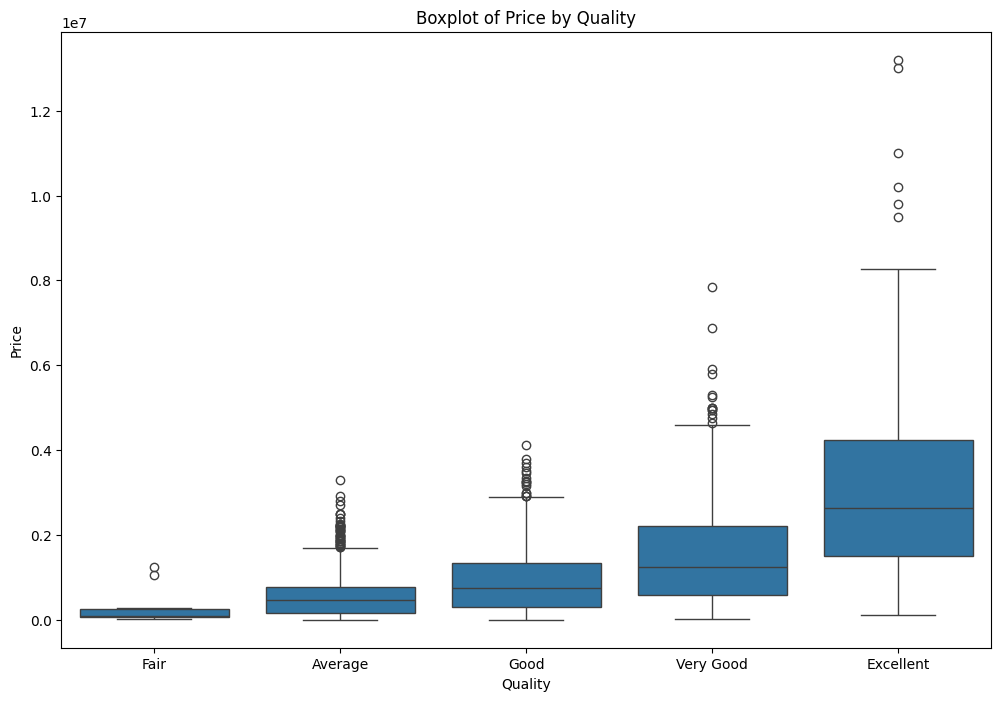

In [60]:
# Create boxplot of most recent sales Price vs Quality
plt.figure(figsize=(12, 8))
sns.boxplot(data=master_df, x='quality', y='price')

# Add labels and title
plt.title('Boxplot of Price by Quality')
plt.xlabel('Quality')
plt.ylabel('Price')

### address

To begin, we will take a look at the addresses to explore if there are any addresses with multiple strap values

In [61]:
#Filter for all addresses with multiple straps
multiple_addr = master_df.address.value_counts()[master_df.address.value_counts() > 1]

There are six addresses with different strap values. Let's take a look at that data.

In [62]:
master_df[master_df.address.isin(multiple_addr.index)].sort_values(by='address').sort_values(by='address')

,address,num_of_buildings,effective_year_built,age_of_home,land_class_dscr,market_area,most_recent_trxn_date,num_trxns,price,adjusted_sales_price,price_per_overall_sqft,sales_cd_dscr,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,mill_levy,unincorporated,sub_dscr,design,quality,bldg_class,construction_type,nbr_bed_room,nbr_rooms_nobath,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_total_baths,bath_room_ratio,total_finished_sqft,mainfloor_sqft,enclosed_sqft_total,bsmt_sqft,land_sqft,land_acreage,prop_overall_sqft,mainfloor_to_land_ratio,car_storage_type,ext_wall,ac,heating,bsmt_design,bsmt_finish,market_area_mean,adj_sales_price_vs_mkt_area_mean
strap,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
R0003032,"2108 WALNUT ST, BOULDER CO",1.00,"1,980.00",44.00,Single Family,101,2000-12-25,1.00,"150,000.00",NaN,4.86,Unqualified,"78,575.00","566,650.00","645,225.00","5,265.00","36,123.00","41,388.00",86.36,0.00,Boulder O T East & West & North - BO,2-3 Story House,Average,Single Family Improvements,Frame,2.00,5.00,1.00,0.00,0.00,1.00,0.20,"1,058.00",667.00,667.00,0.00,"30,195.00",0.69,"30,862.00",0.02,No Car Storage,Frame Wood/Shake,0.00,1.00,No Basement,No Basement,"1,202,778.17",NaN
R0004731,"2108 WALNUT ST, BOULDER CO",1.00,"1,980.00",44.00,Single Family,101,2000-12-25,1.00,"150,000.00",NaN,4.86,Unqualified,"78,575.00","566,650.00","645,225.00","5,265.00","36,123.00","41,388.00",86.36,0.00,Boulder O T East & West & North - BO,2-3 Story House,Average,Single Family Improvements,Frame,2.00,5.00,1.00,0.00,0.00,1.00,0.20,"1,058.00",667.00,667.00,0.00,"30,195.00",0.69,"30,862.00",0.02,No Car Storage,Frame Wood/Shake,0.00,1.00,No Basement,No Basement,"1,202,778.17",NaN
R0003031,"2110 WALNUT ST, BOULDER CO",1.00,"1,965.00",59.00,Single Family,101,2023-08-04,2.00,"100,000.00","100,000.00",9.86,Unqualified,"45,962.00","301,125.00","347,087.00","3,079.00","18,332.00","21,411.00",86.36,0.00,Boulder O T East & West & North - BO,1 Story House,Fair,Single Family Improvements,Frame,1.00,2.00,0.00,1.00,0.00,0.75,0.38,589.00,589.00,589.00,0.00,"9,551.00",0.22,"10,140.00",0.06,No Car Storage,Log,0.00,1.00,No Basement,No Basement,"1,202,778.17",0.08
R0004733,"2110 WALNUT ST, BOULDER CO",1.00,"1,965.00",59.00,Single Family,101,2023-08-04,2.00,"100,000.00","100,000.00",9.86,Unqualified,"45,963.00","301,125.00","347,088.00","3,080.00","18,332.00","21,412.00",86.36,0.00,Boulder O T East & West & North - BO,1 Story House,Fair,Single Family Improvements,Frame,1.00,2.00,0.00,1.00,0.00,0.75,0.38,589.00,589.00,589.00,0.00,"9,551.00",0.22,"10,140.00",0.06,No Car Storage,Log,0.00,1.00,No Basement,No Basement,"1,202,778.17",0.08
R0004062,"2425 PINE ST, BOULDER CO",1.00,"1,980.00",44.00,Single Family,109,1983-08-02,1.00,"80,000.00",NaN,14.58,Unqualified,"651,900.00","775,500.00","1,427,400.00","43,677.00","48,274.00","91,951.00",86.36,0.00,Ducky Flats - BO,2-3 Story House,Good,Single Family Improvements,Masonry,2.00,6.00,2.00,0.00,0.00,2.00,0.33,"1,741.00",981.00,981.00,0.00,"4,505.00",0.10,"5,486.00",0.22,No Car Storage,Frame Wood/Shake,0.00,1.00,No Basement,No Basement,"2,063,471.08",NaN
R0093134,"2425 PINE ST, BOULDER CO",1.00,"1,985.00",39.00,Single Family,109,1992-12-15,3.00,"100,000.00",NaN,29.19,Unqualified,"574,500.00","662,600.00","1,237,100.00","38,492.00","40,709.00","79,201.00",86.36,0.00,Ducky Flats - BO,2-3 Story House,Average,Single Family Improvements,Frame,1.00,5.00,1.00,0.00,1.00,1.50,0.30,"1,239.00",664.00,664.00,0.00,"2,762.00",0.06,"3,426.00",0.24,Carport,Frame Wood/Shake,0.00,1.00,No Basement,No Basement,"2,063,471.08",NaN
R0508618,"2635 MAPLETON AVE, BOULDER CO",NaN,NaN,NaN,Vacant/Other,109,2004-12-08,1.00,"2,900,000.00",NaN,NaN,Qualified,0.00,"3,300,000.00","3,300,000.00",NaN,NaN,"217,415.00",86.36,0.00,Mapleton Mhp Sub,nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,"447,958.00",10.28,NaN,NaN,No Car Storage,NaN,NaN,NaN,No Bas

It appears that there is some variety in these rows. For example, the property at 2425 Pine St. has two different transaction dates. This may be because the address has two different single family homes on it. Since we do not want to lose this data, we will keep all the above rows in the master_df.

### num_of_buildings

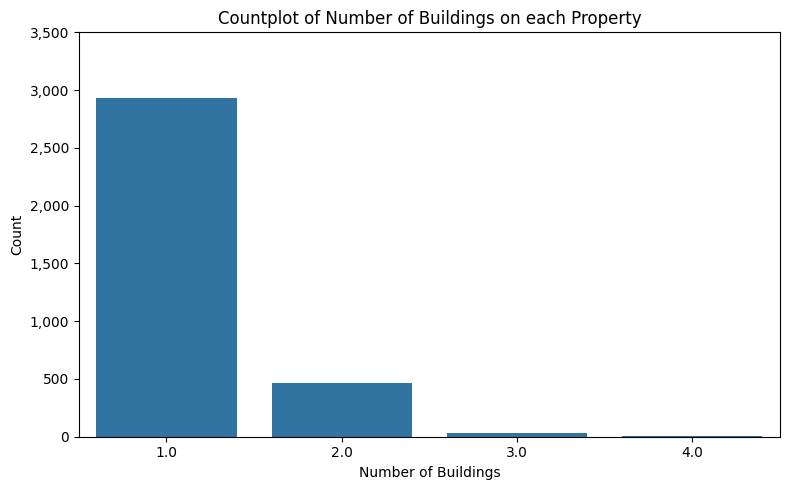

In [63]:
fig, ax = plt.subplots(figsize=(8, 5))

#Plot num_of_buildings CountPlot
sns.countplot(x = 'num_of_buildings',
              data = master_df)

#Format axes and title
ax.set_xlabel('Number of Buildings')
ax.set_ylabel('Count')
ax.set_title('Countplot of Number of Buildings on each Property')

#Format yticks with commas
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([f'{y:,.0f}' for y in ax.get_yticks()])

plt.tight_layout()

As expected, the vast majority of properties include a single building, while a handful of properties include up to four buildings. This is reasonable to expect within the data.

### effective_year_built and age_of_home

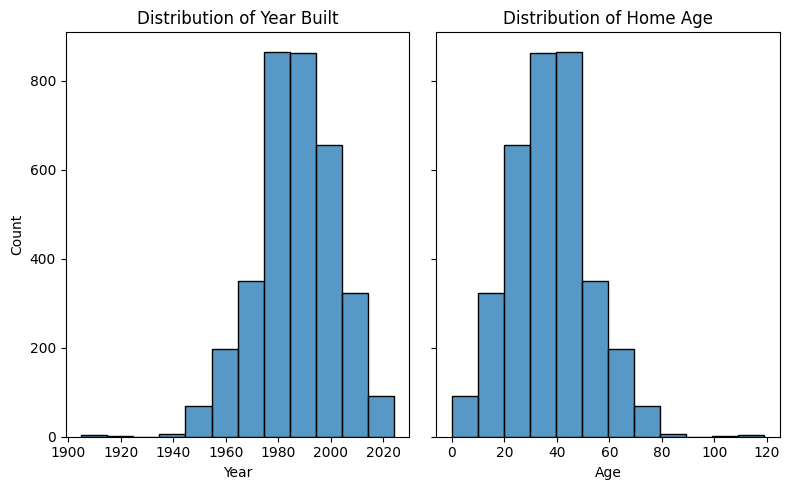

In [64]:
fig, (axes_left, axes_right) = plt.subplots(1, 2, sharey=True, figsize=(8, 5))

#Plot histogram of effective_year_built
sns.histplot(x = 'effective_year_built',
             binwidth=10,
             data = master_df,
             ax = axes_left)
#Add labels to histogram
axes_left.set_xlabel('Year')
axes_left.set_title('Distribution of Year Built')
axes_left.set_ylabel('Count')

#Plot histogram  of age_of_home
sns.histplot(x = 'age_of_home',
             binwidth=10,
             data = master_df,
             ax = axes_right)
#Add labels to histogram
axes_right.set_xlabel('Age')
axes_right.set_title('Distribution of Home Age')

plt.tight_layout()

These visualization show that there are not an abundance of new or old homes within the dataset. It may be interesting to explore how the older homes are valued, however the majority of homes are around 40 years old and therefore we do not have notable differences in home ages.

### land_class_dscr

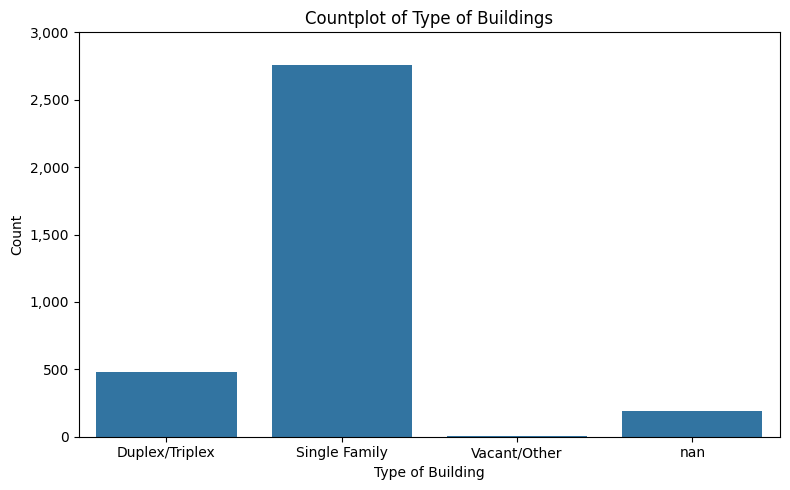

In [65]:
fig, ax = plt.subplots(figsize=(8, 5))

#Plot countplot of land_class_dscr
sns.countplot(x = 'land_class_dscr',
              data = master_df)

#Add labels and title to plot
ax.set_xlabel('Type of Building')
ax.set_ylabel('Count')
ax.set_title('Countplot of Type of Buildings')
#Format yticks with commas
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([f'{y:,.0f}' for y in ax.get_yticks()])

plt.tight_layout()

The majority of the buildings in the dataset are single family homes. However, we also have some duplex/triplex buildings, as these values could be re-convereted to single family homes, we will keep these values in the dataset. The Vacant/Other count is interesting and will require some exploration.

In [66]:
#Filter the master_df for Vacant/Other properties
master_df[master_df['land_class_dscr'] == 'Vacant/Other']

,address,num_of_buildings,effective_year_built,age_of_home,land_class_dscr,market_area,most_recent_trxn_date,num_trxns,price,adjusted_sales_price,price_per_overall_sqft,sales_cd_dscr,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,mill_levy,unincorporated,sub_dscr,design,quality,bldg_class,construction_type,nbr_bed_room,nbr_rooms_nobath,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_total_baths,bath_room_ratio,total_finished_sqft,mainfloor_sqft,enclosed_sqft_total,bsmt_sqft,land_sqft,land_acreage,prop_overall_sqft,mainfloor_to_land_ratio,car_storage_type,ext_wall,ac,heating,bsmt_design,bsmt_finish,market_area_mean,adj_sales_price_vs_mkt_area_mean
strap,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
R0508618,"2635 MAPLETON AVE, BOULDER CO",NaN,NaN,NaN,Vacant/Other,109,2004-12-08,1.00,"2,900,000.00",NaN,NaN,Qualified,0.00,"3,300,000.00","3,300,000.00",NaN,NaN,"217,415.00",86.36,0.00,Mapleton Mhp Sub,nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,"447,958.00",10.28,NaN,NaN,No Car Storage,NaN,NaN,NaN,No Basement,No Basement,"2,063,471.08",NaN
R0508632,"2635 MAPLETON AVE, BOULDER CO",NaN,NaN,NaN,Vacant/Other,109,2004-12-08,1.00,"2,900,000.00",NaN,NaN,Qualified,0.00,"1,550,000.00","1,550,000.00",NaN,NaN,"100,165.00",86.36,0.00,Mapleton Mhp Sub,nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,"179,310.00",4.12,NaN,NaN,No Car Storage,NaN,NaN,NaN,No Basement,No Basement,"2,063,471.08",NaN
R0607233,"757 12TH ST, BOULDER CO",1.00,"1,916.00",108.00,Vacant/Other,102,2020-12-17,1.00,"720,000.00","939,816.00",NaN,Qualified,0.00,"764,760.00","764,760.00",0.00,"213,368.00","213,368.00",86.36,0.00,University Place Rplt D,Detached Garage,Average,Other,Masonry,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,0.00,"6,116.00",0.14,NaN,NaN,No Car Storage,Brick on Block,0.00,0.00,No Basement,No Basement,"1,810,054.83",0.52


We do not have much information about these properties. However, we do have some price information and, just like the duplex/triplex buildings, these properties could be re-inhabitated and used as a Single Family Home and so we will continue to include them in the dataset.

### market_area

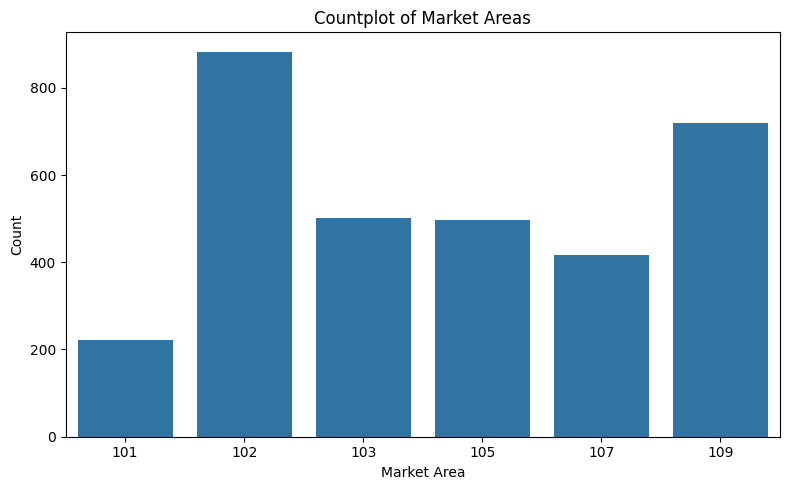

In [67]:
fig, ax = plt.subplots(figsize=(8, 5))

#Plot a countplot of market_area
sns.countplot(x = 'market_area',
              data = master_df)

#Add axis labels and title
ax.set_xlabel('Market Area')
ax.set_ylabel('Count')
ax.set_title('Countplot of Market Areas')

plt.tight_layout()

We have a good representation of properties from each market area.

### most_recent_trxn_date

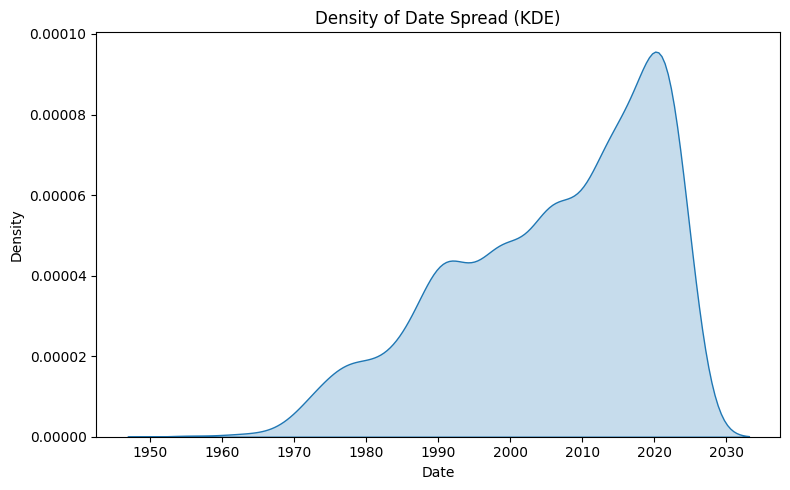

In [68]:
fig, ax = plt.subplots(figsize=(8, 5))

#Create a KDE plot for most_recent_trxn_date
sns.kdeplot(x='most_recent_trxn_date',
            fill=True,
            data=master_df)

#Add axis labels and title
ax.set_title('Density of Date Spread (KDE)')
ax.set_xlabel('Date')
ax.set_ylabel('Density')

plt.tight_layout()

It appears that some homes may not have been sold since they were built, while others have been sold as recently as this year. To confirm the data is accurate, we will check the max sales price to confirm no sales are supposedly taking place in the future.

In [69]:
#Pull the max date value
master_df['most_recent_trxn_date'].max()

Timestamp('2024-09-10 00:00:00')

There is a peak of sales occuring now, however the dates are reasonable.

### num_trxns

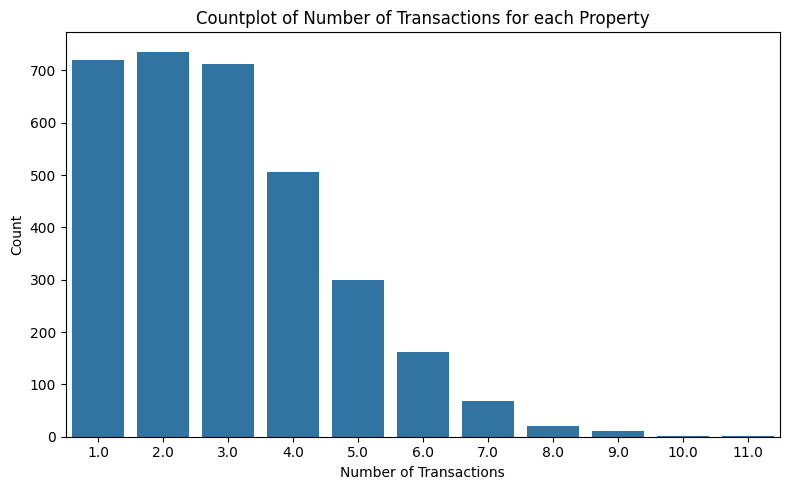

In [70]:
fig, ax = plt.subplots(figsize=(8, 5))

#Create a countplot of num_trxns
sns.countplot(x = 'num_trxns',
              data = master_df)

#Add axis labels and title
ax.set_xlabel('Number of Transactions')
ax.set_ylabel('Count')
ax.set_title('Countplot of Number of Transactions for each Property')

plt.tight_layout()

A proportionally small amount of properties have been sold an extreme number of times. The majority of these properties have been sold less than 4 times, which is reasonable to expect for a dataframe that spans over 100 years.

### price and adjusted_sales_price

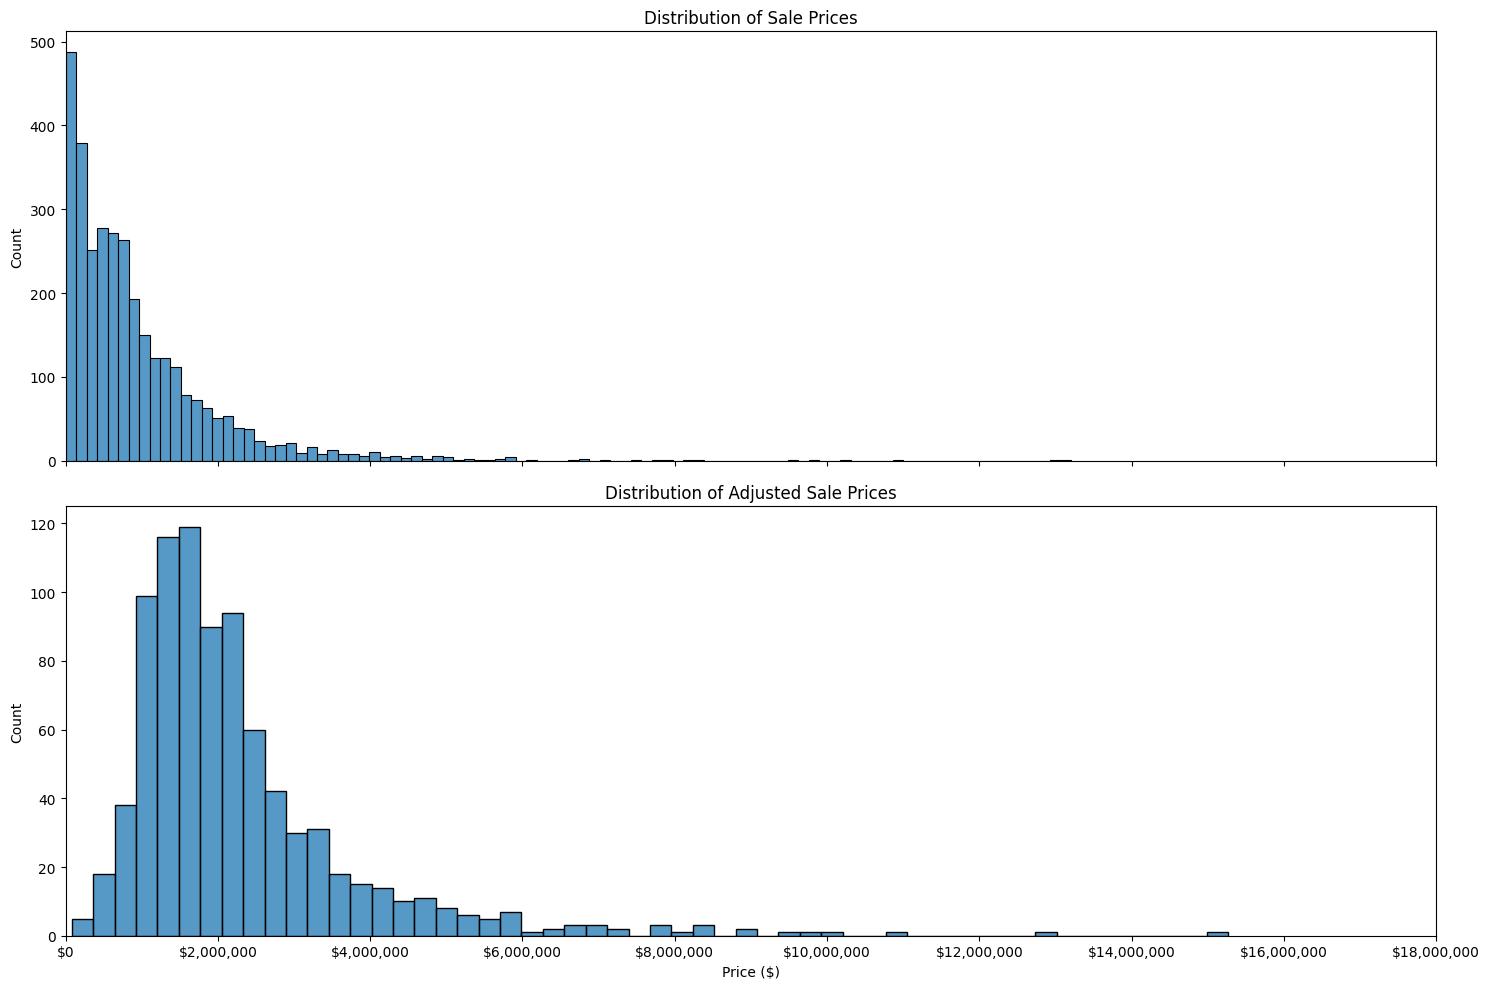

In [71]:
fig, (axes_top, axes_bottom) = plt.subplots(2, 1, sharex=True, figsize=(15, 10))

#Plot a histogram of price
sns.histplot(x = 'price',
             data = master_df,
             ax = axes_top)
axes_top.set_title('Distribution of Sale Prices')

#Plot a histogram of adjusted price
sns.histplot(x = 'adjusted_sales_price',
             data = master_df,
             ax = axes_bottom)
axes_bottom.set_xlabel('Price ($)')
axes_bottom.set_title('Distribution of Adjusted Sale Prices')

#Format xticks with commas and dollar signs
axes_bottom.set_xticks(axes_bottom.get_xticks())
axes_bottom.set_xticklabels([f'${y:,.0f}' for y in axes_bottom.get_xticks()])

#Format graph so that the prices begin at $0
axes_bottom.set_xlim(left=-100)

plt.tight_layout()

As would be expected, adjusted_sale_prices are less spread than sale price. The majority of the adjusted_sale_price data is distributed around the 200,000 mark with a long upper tail to the 1,600,000 value.

### price_per_overall_sqft

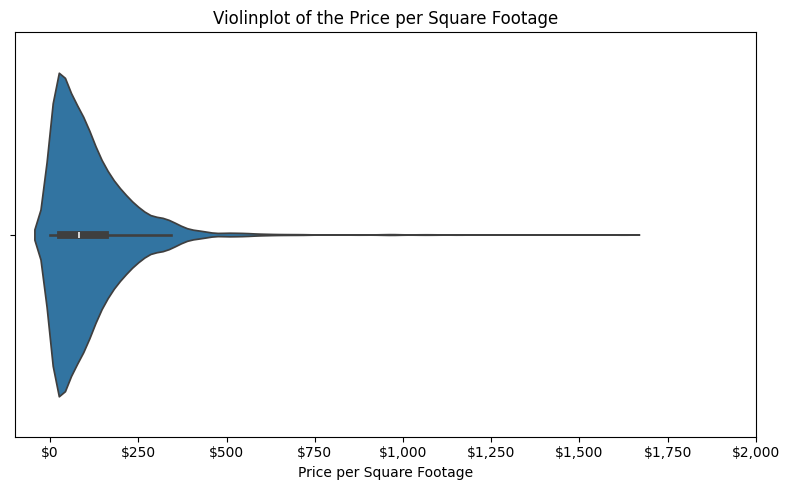

In [72]:
fig, ax = plt.subplots(figsize=(8, 5))

#Plot a violineplot of price_per_overall_sqft
sns.violinplot(x = 'price_per_overall_sqft',
              data = master_df)

#Add axis labels
ax.set_xlabel('Price per Square Footage')
ax.set_title('Violinplot of the Price per Square Footage')

#Format xticks with commas and dollar signs
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels([f'${y:,.0f}' for y in ax.get_xticks()])

#Format graph so that the prices begin at $0
ax.set_xlim(left=-100)

plt.tight_layout()

This data is significantly spread out. It may be helpful to see the specific spread of the data.

In [73]:
#Spread of price_per_overall_sqft
master_df['price_per_overall_sqft'].describe()

,price_per_overall_sqft
count,"3,231.00"
mean,111.55
std,112.78
min,0.18
25%,31.52
50%,81.96
75%,155.43
max,"1,624.28"


This spread is quite extreme and it will be interesting to see why one property cost less than a dollar per square foot and other cost over $1000 per square foot. Let's take a look at these extreme values.

In [74]:
#Find the data for the max value
master_df[master_df['price_per_overall_sqft'] == master_df['price_per_overall_sqft'].max()]

,address,num_of_buildings,effective_year_built,age_of_home,land_class_dscr,market_area,most_recent_trxn_date,num_trxns,price,adjusted_sales_price,price_per_overall_sqft,sales_cd_dscr,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,mill_levy,unincorporated,sub_dscr,design,quality,bldg_class,construction_type,nbr_bed_room,nbr_rooms_nobath,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_total_baths,bath_room_ratio,total_finished_sqft,mainfloor_sqft,enclosed_sqft_total,bsmt_sqft,land_sqft,land_acreage,prop_overall_sqft,mainfloor_to_land_ratio,car_storage_type,ext_wall,ac,heating,bsmt_design,bsmt_finish,market_area_mean,adj_sales_price_vs_mkt_area_mean
strap,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
R0062911,"957 9TH ST, BOULDER CO",1.00,"1,994.00",30.00,Duplex/Triplex,103,2024-04-25,2.00,"1,405,000.00","1,405,000.00","1,624.28",Unqualified,"197,163.00","210,175.00","407,338.00","13,210.00","12,239.00","25,449.00",86.36,0.00,Rose Hill - BO,2-3 Story House,Average,Duplex/Triplex Improvements,Frame,4.00,9.00,2.00,2.00,0.00,3.50,0.39,"1,200.00",840.00,"1,230.00",390.00,25.00,0.00,865.00,33.60,No Car Storage,Frame Wood/Shake,0.00,1.00,Walk-Out,Finished,"3,079,339.09",0.46


It appears that this extreme value is because of a very small land_sqft value (25.0). Let's look at the original dataframe to find this value.

In [75]:
land.sort_values(by='sqft')

,strap,land_class,land_class_dscr,sqft,acreage
2978,R0062911,1115,DUP/TRIPLEXES-LAND,25,0.00
3094,R0081600,1112,SINGLE FAM.RES.-LAND,520,0.01
3067,R0081572,1112,SINGLE FAM.RES.-LAND,524,0.01
3118,R0083988,1112,SINGLE FAM.RES.-LAND,541,0.01
3041,R0081546,1112,SINGLE FAM.RES.-LAND,546,0.01
...,...,...,...,...,...
2903,R0033213,1112,SINGLE FAM.RES.-LAND,127736,2.93
2922,R0033598,1112,SINGLE FAM.RES.-LAND,153741,3.53
3371,R0508632,1140,MANUF HOME PARK LAND,179310,4.12
2920,R0033535,1112,SINGLE FAM.RES.-LAND,202485,4.65


This square feet value seems to be an outlier, it is significantly smaller than the next closest value. This may be an example of incorrectly inputted data. In order to avoid a skewed distribution, we will drop this row from the dataframe.

In [76]:
master_df = master_df.drop('R0062911')

In [77]:
#Find the data for the min value
master_df[master_df['price_per_overall_sqft'] == master_df['price_per_overall_sqft'].min()]

,address,num_of_buildings,effective_year_built,age_of_home,land_class_dscr,market_area,most_recent_trxn_date,num_trxns,price,adjusted_sales_price,price_per_overall_sqft,sales_cd_dscr,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,mill_levy,unincorporated,sub_dscr,design,quality,bldg_class,construction_type,nbr_bed_room,nbr_rooms_nobath,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_total_baths,bath_room_ratio,total_finished_sqft,mainfloor_sqft,enclosed_sqft_total,bsmt_sqft,land_sqft,land_acreage,prop_overall_sqft,mainfloor_to_land_ratio,car_storage_type,ext_wall,ac,heating,bsmt_design,bsmt_finish,market_area_mean,adj_sales_price_vs_mkt_area_mean
strap,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
R0002963,"1625 BLUEBELL AVE, BOULDER CO",1.00,"1,960.00",64.00,Single Family,102,1979-09-14,1.00,"2,000.00",NaN,0.18,Unqualified,"305,700.00","1,012,900.00","1,318,600.00","20,482.00","64,179.00","84,661.00",86.36,0.00,Floral Park & Weihofen Resub - BO,1 Story House,Average,Single Family Improvements,Masonry,4.00,9.00,2.00,0.00,0.00,2.00,0.22,"1,939.00","1,939.00","1,939.00",0.00,"9,134.00",0.21,"11,073.00",0.21,Detached Garage,Brick Veneer,1.00,1.00,No Basement,No Basement,"1,810,054.83",NaN


This property has not been sold since 1979 and therefore we do not have an adjusted sales price for it. This may account for the realitivly small price_per_overall_sqft so we will keep the data point in the dataframe. Now, that we have made some updates, let's look at the distribution again.

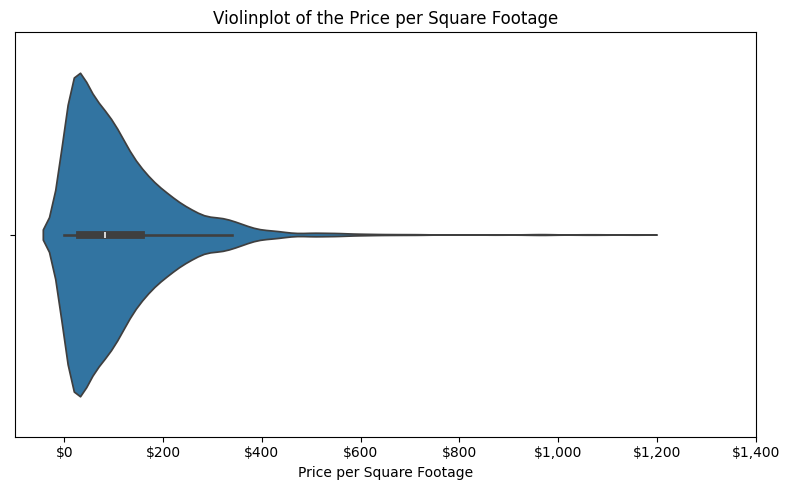

In [78]:
fig, ax = plt.subplots(figsize=(8, 5))

#Plot a violineplot of price_per_overall_sqft
sns.violinplot(x = 'price_per_overall_sqft',
              data = master_df)

#Add axis labels
ax.set_xlabel('Price per Square Footage')
ax.set_title('Violinplot of the Price per Square Footage')

#Format xticks with commas and dollar signs
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels([f'${y:,.0f}' for y in ax.get_xticks()])

#Format graph so that the prices begin at $0
ax.set_xlim(left=-100)

plt.tight_layout()

### sales_cd_dscr

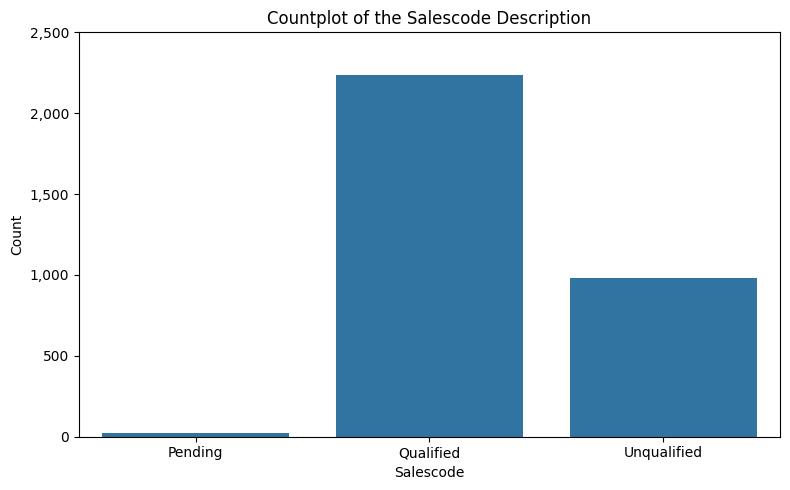

In [79]:
fig, ax = plt.subplots(figsize=(8, 5))

#Create a countplot of sales_cd_dscr
sns.countplot(x = 'sales_cd_dscr',
              data = master_df)

#Add axis labels and title
ax.set_xlabel('Salescode')
ax.set_ylabel('Count')
ax.set_title('Countplot of the Salescode Description')

#Format yticks with commas
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([f'{y:,.0f}' for y in ax.get_yticks()])

plt.tight_layout()

These salescodes appear reasonable for the dataframe.

### bld_appraised_val_2024, land_appraised_val_2024, and total_appraised_val_2024

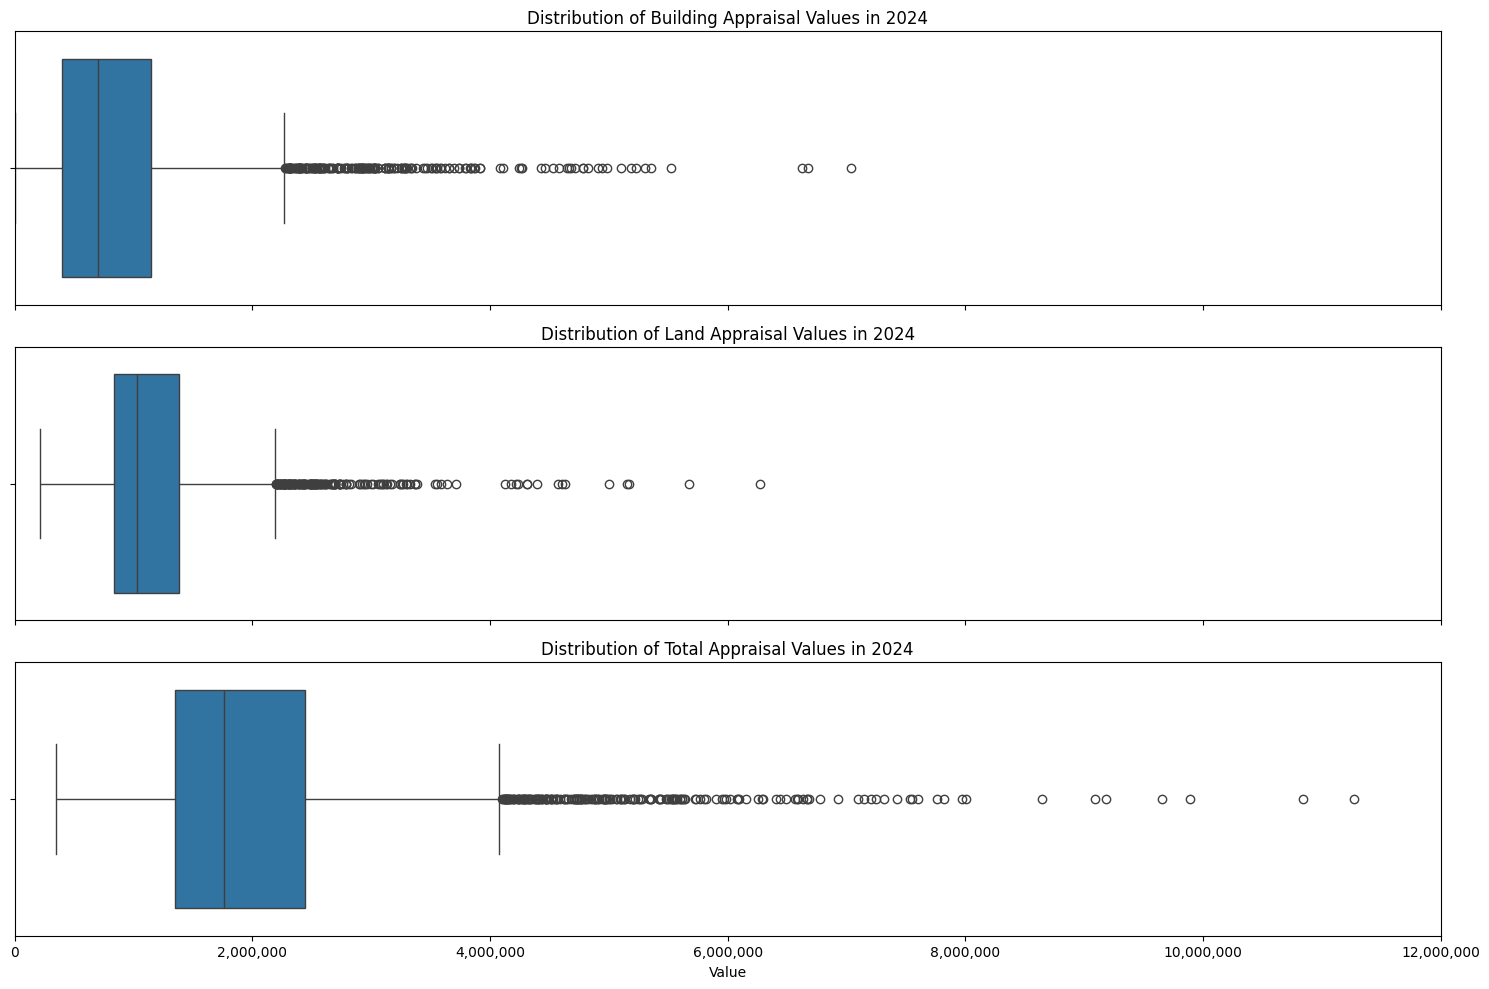

In [80]:
fig, (a, b, c) = plt.subplots(3, 1, sharex=True, figsize=(15, 10))

#Create boxplot of bld_appraised_val_2024
sns.boxplot(x = 'bld_appraised_val_2024',
             data = master_df,
             ax = a)
a.set_title('Distribution of Building Appraisal Values in 2024')

#Create boxplot of land_appraised_val_2024
sns.boxplot(x = 'land_appraised_val_2024',
             data = master_df,
             ax = b)
b.set_title('Distribution of Land Appraisal Values in 2024')

#Create boxplot of total_appraised_val_2024
sns.boxplot(x = 'total_appraised_val_2024',
             data = master_df,
             ax = c)
c.set_title('Distribution of Total Appraisal Values in 2024')
c.set_xlabel('Value')

#Format xticks with commas
c.set_xticks(c.get_xticks())
c.set_xticklabels([f'{y:,.0f}' for y in c.get_xticks()])

#Format graph so that the prices begin at $0
c.set_xlim(left=-100)

plt.tight_layout()

There is a fair amount of spread in the total appraisal value for the properties. Further analysis about the correlation of these values with the adjusted sales price will be needed.

### bld_assessed_val_2024, land_assessed_val_2024, and total_assessed_val_2024

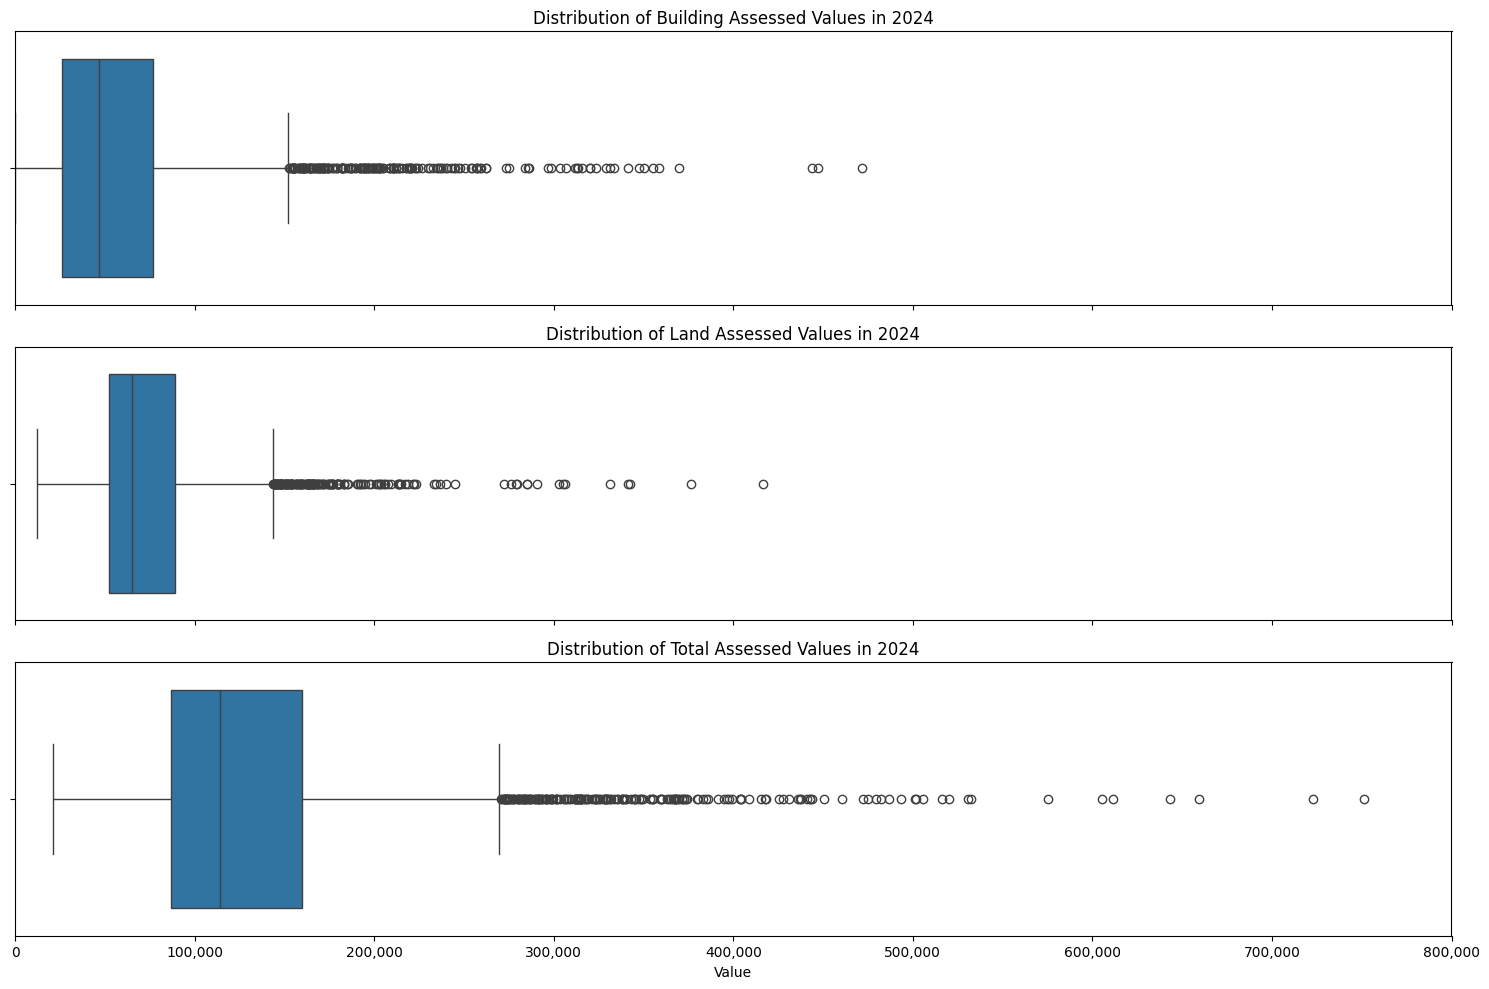

In [81]:
fig, (a, b, c) = plt.subplots(3, 1, sharex=True, figsize=(15, 10))

#Create boxplot of bld_assessed_val_2024
sns.boxplot(x = 'bld_assessed_val_2024',
             data = master_df,
             ax = a)
a.set_title('Distribution of Building Assessed Values in 2024')

#Create boxplot of land_assessed_val_2024
sns.boxplot(x = 'land_assessed_val_2024',
             data = master_df,
             ax = b)
b.set_title('Distribution of Land Assessed Values in 2024')

#Create boxplot of total_assessed_val_2024
sns.boxplot(x = 'total_assessed_val_2024',
             data = master_df,
             ax = c)
c.set_xlabel('Value')
c.set_title('Distribution of Total Assessed Values in 2024')

#Format xticks with commas
c.set_xticks(c.get_xticks())
c.set_xticklabels([f'{y:,.0f}' for y in c.get_xticks()])

#Format graph so that the prices begin at $0
c.set_xlim(left=-100)

plt.tight_layout()

As with the appraisal value, there is a fair amount of spread in the total assessed value for the properties. Further analysis about the correlation of these values with the adjusted sales price will be needed.

### mill_levy

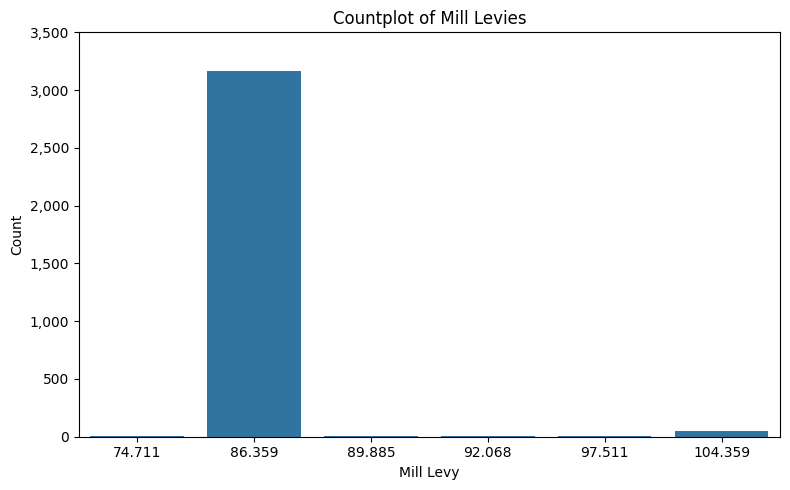

In [82]:
fig, ax = plt.subplots(figsize=(8, 5))

#Create a countplot for mill_levy
sns.countplot(x = 'mill_levy',
              data = master_df)

#Add axis labels and title
ax.set_xlabel('Mill Levy')
ax.set_ylabel('Count')
ax.set_title('Countplot of Mill Levies')

#Format yticks with commas
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([f'{y:,.0f}' for y in ax.get_yticks()])

plt.tight_layout()

It appears that, with a few outliers, nearly the entire dataset has the same mill levy value. As mill levies are likely set by physical, let's first confirm that these levies are not set by market area.

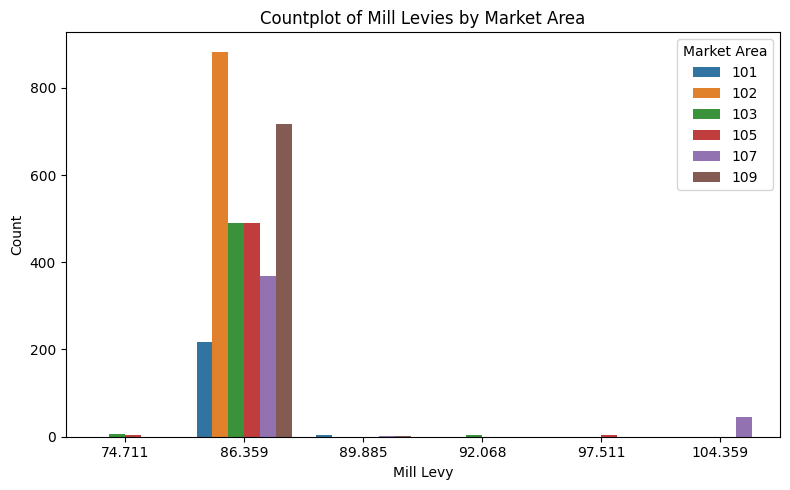

In [83]:
fig, ax = plt.subplots(figsize=(8, 5))

#Update mill_levy countplot to color by market area
sns.countplot(x = 'mill_levy',
              hue='market_area',
              data = master_df)

#Format labels and title
ax.set_xlabel('Mill Levy')
ax.set_ylabel('Count')
ax.set_title('Countplot of Mill Levies by Market Area')
ax.legend(title='Market Area')

plt.tight_layout()

It seems that there is a variety of market areas for each mill levy. Let's take a look at the values that do not have the most popular mill levy.

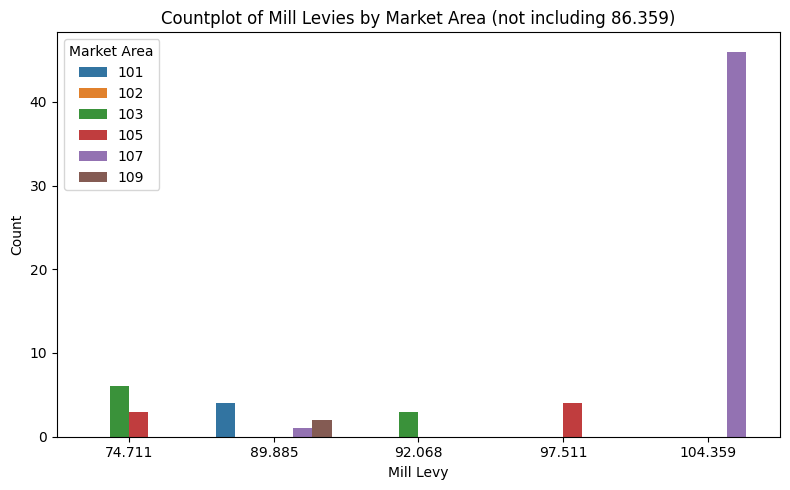

In [84]:
fig, ax = plt.subplots(figsize=(8, 5))

#Re-create previous plot, but remove value with the extreme count
sns.countplot(x = 'mill_levy',
              hue='market_area',
              data = master_df[master_df.mill_levy != 86.359])

#Format labels
ax.set_xlabel('Mill Levy')
ax.set_ylabel('Count')
ax.set_title('Countplot of Mill Levies by Market Area (not including 86.359)')
ax.legend(title='Market Area')

plt.tight_layout()

It appears that there continues to be variation in mill levy. Though the vast majority of the data has one mill levy, there still is a proportion with the other values.

### unincorporated

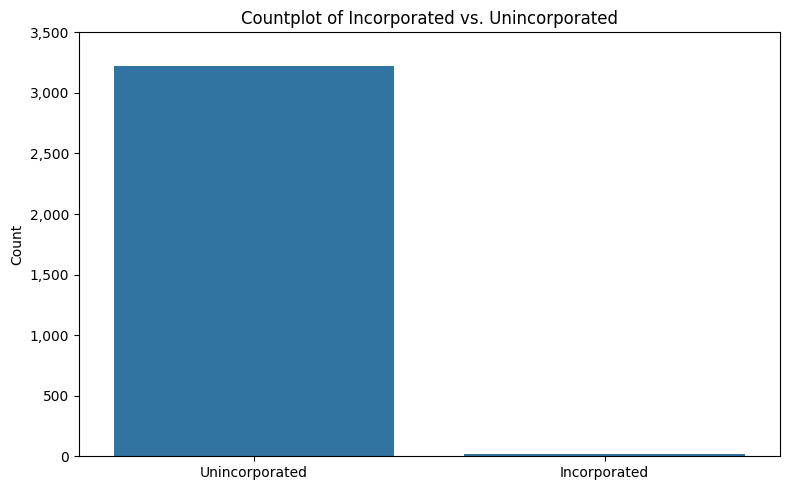

In [85]:
fig, ax = plt.subplots(figsize=(8, 5))

#Create a countplot for unincorporated
sns.countplot(x = 'unincorporated',
              data = master_df)

#Set axis labels and title
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.set_title('Countplot of Incorporated vs. Unincorporated')

#Convert the 0,1 xticks to be unincorporated/incorporated
ax.set_xticks([0, 1])
ax.set_xticklabels(['Unincorporated', 'Incorporated'])

#Format yticks with commas
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([f'{y:,.0f}' for y in ax.get_yticks()])

plt.tight_layout()

The vast majority of properties in the dataframe are unincorporated. This will therefore likely not be a very helpful variable in determining the valuation of the property.

### sub_dscr

In [86]:
#Determine the count of each sub_dscr
master_df.sub_dscr.value_counts()

,count
sub_dscr,
University Place - BO,535
Boulder O T East & West & North - BO,385
Interurban Park - BO,156
Chautauqua Heights - BO,105
Floral Park & Weihofen Resub - BO,103
...,...
Bellevue Vista,1
Jason One Jessica Two - BO,1
1622/1624 18Th Street Sub,1


There are over 200 unique sub descriptions that range from including one property to over 500 properties. Location may be a helpful variable for determining valuation in later analysis. Therefore, we will convert the sub_dscr to a numeric code value and save it as sub_code.

In [87]:
#Save all of the unique sub_dscr values in subs
subs = master_df.sub_dscr.unique()

#iterate through all possible sub_dscr values and assign a numeric value to the sub. Save these values in the dictionary sub_dict
i = 1
sub_dict = {}
for val in subs:
    sub_dict[val] = i
    i = i + 1

In [88]:
#Create sub_code column and assign the correct numeric code based on the sub_dscr value
master_df['sub_code'] = 0
for val in master_df.sub_dscr:
    master_df.loc[master_df.sub_dscr == val,'sub_code'] = sub_dict[val]

### design

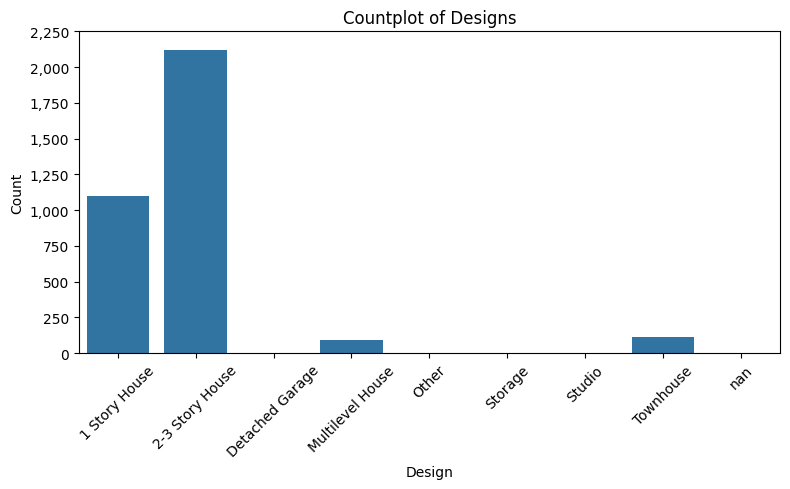

In [89]:
fig, ax = plt.subplots(figsize=(8, 5))

#Create a countplot for design
sns.countplot(x = 'design',
              data = master_df)

#Add axis labels and title
ax.set_xlabel('Design')
ax.set_ylabel('Count')
ax.set_title('Countplot of Designs')

#Sets ticks on x-axis so that we can rotate
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

#Format yticks with commas
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([f'{y:,.0f}' for y in ax.get_yticks()])

plt.tight_layout()

There is some variation in building design, however, as would be expected, the far majority of buildings are single and multi-story homes.

### quality

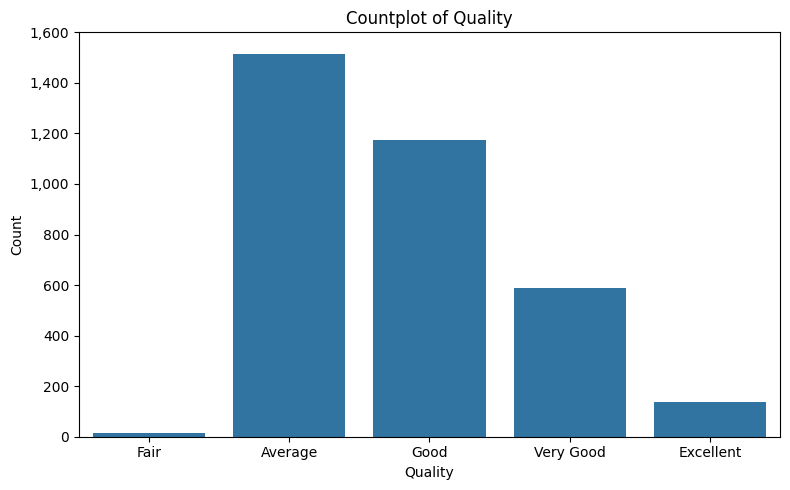

In [90]:
fig, ax = plt.subplots(figsize=(8, 5))

#Create a countplot of quality
sns.countplot(x = 'quality',
              data = master_df)

#Set axis labels and title
ax.set_xlabel('Quality')
ax.set_ylabel('Count')
ax.set_title('Countplot of Quality')

#Format yticks with commas
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([f'{y:,.0f}' for y in ax.get_yticks()])

plt.tight_layout()

We have a variety of quality ratings, with average as the most frequent. This quality rating will be an interesting measure to correlate with price and valuations.

### bldg_class

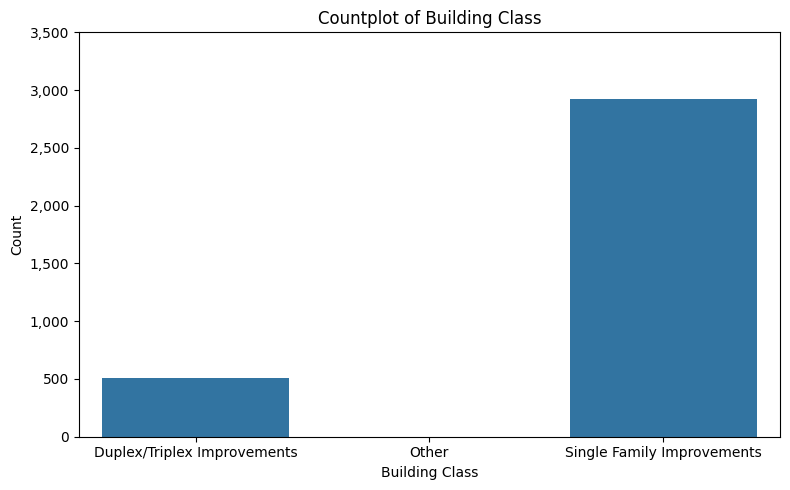

In [91]:
fig, ax = plt.subplots(figsize=(8, 5))

#Create countplot for bldg_class
sns.countplot(x = 'bldg_class',
              data = master_df)

#Set axis labels and title
ax.set_xlabel('Building Class')
ax.set_ylabel('Count')
ax.set_title('Countplot of Building Class')

#Format yticks with commas
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([f'{y:,.0f}' for y in ax.get_yticks()])

plt.tight_layout()

This distribution is reasonable for the dataset.

### construction_type

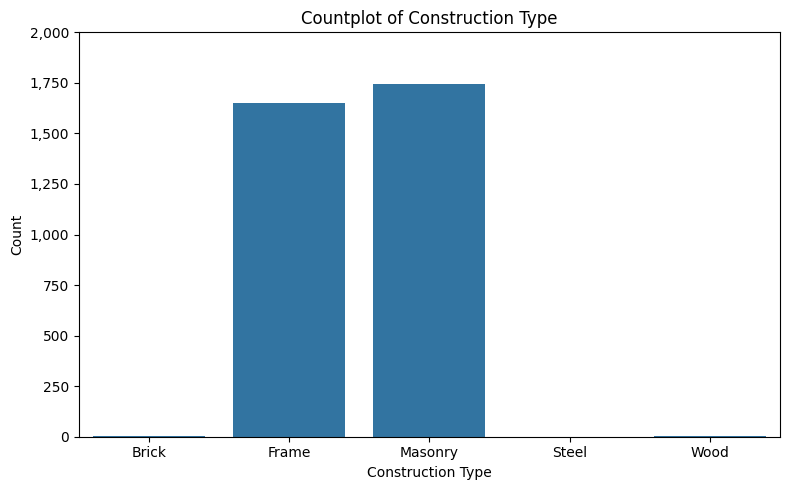

In [92]:
fig, ax = plt.subplots(figsize=(8, 5))

#Plot counts of construction_type
sns.countplot(x = 'construction_type',
              data = master_df)

#Set axis labels and title
ax.set_xlabel('Construction Type')
ax.set_ylabel('Count')
ax.set_title('Countplot of Construction Type')

#Format yticks with commas
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([f'{y:,.0f}' for y in ax.get_yticks()])

plt.tight_layout()

This distribution is reasonable for the dataset. There is a clear preference for masonry and frame construction types.

### nbr_bed_room and nbr_rooms_nobath

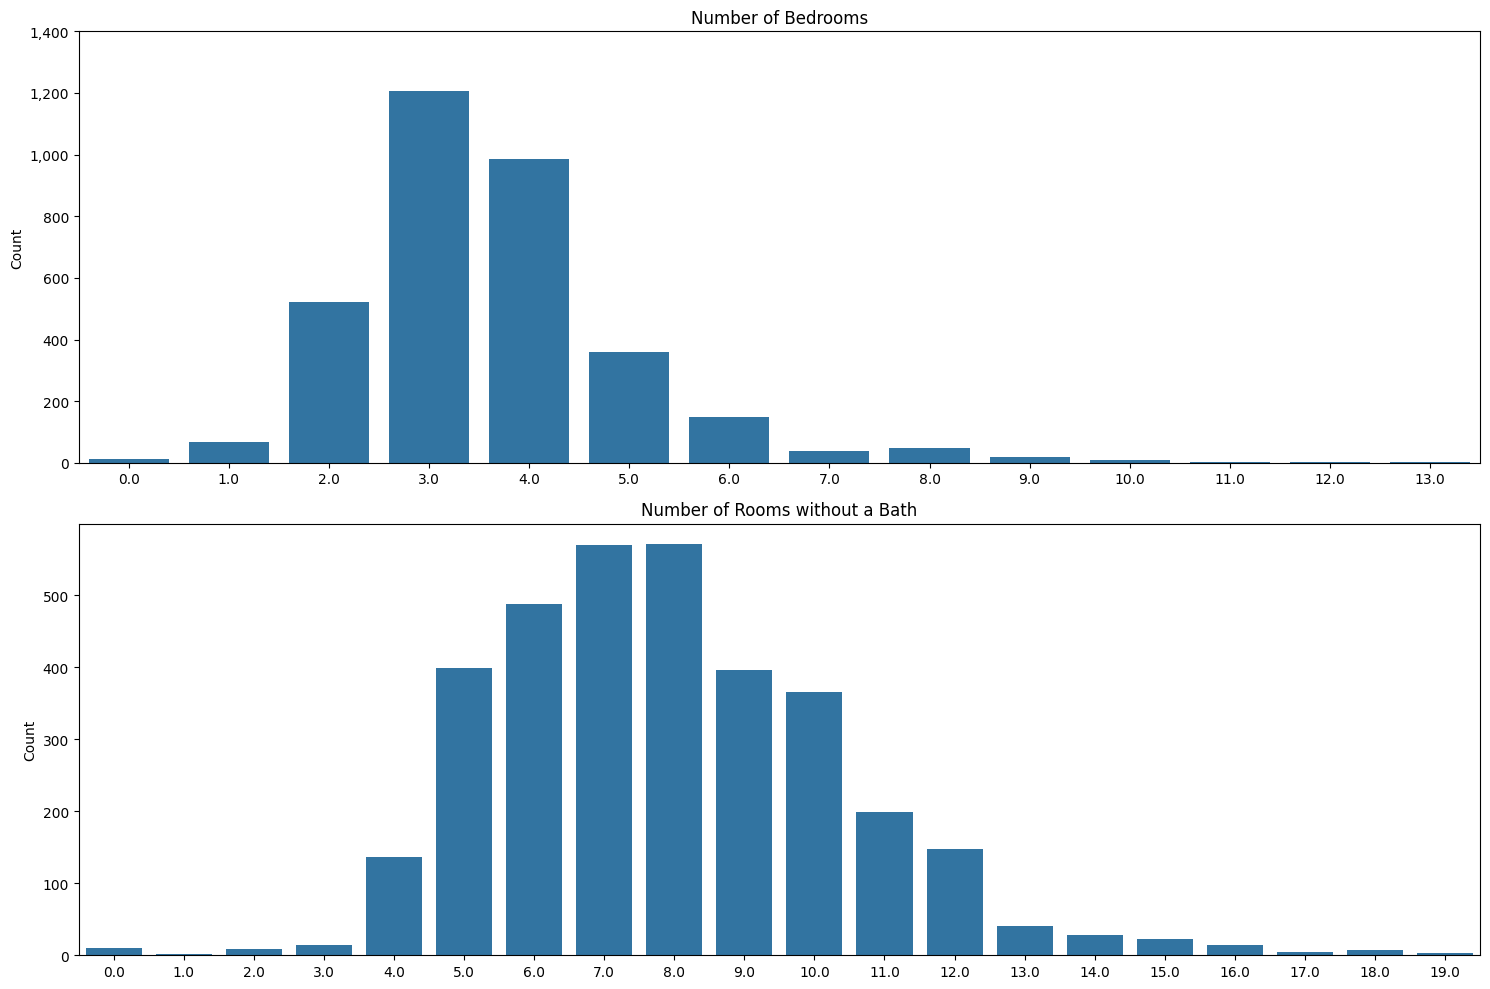

In [93]:
fig, (a, b) = plt.subplots(2, 1, sharex=False, figsize=(15, 10))

#Plot a countplot of nbr_bed_room
sns.countplot(x = 'nbr_bed_room',
             data = master_df,
             ax = a)
#Format labels for nbr_bed_room
a.set_title('Number of Bedrooms')
a.set_xlabel('')
a.set_ylabel('Count')
#Format yticks with commas
a.set_yticks(a.get_yticks())
a.set_yticklabels([f'{y:,.0f}' for y in a.get_yticks()])

#Plot a countplot of nbr_rooms_nobath
sns.countplot(x = 'nbr_rooms_nobath',
             data = master_df,
             ax = b)
#Format labels for nbr_rooms_nobath
b.set_title('Number of Rooms without a Bath')
b.set_ylabel('Count')
b.set_xlabel('')

plt.tight_layout()

Both the number of bedrooms and number of non-bath rooms in the home are normal-like, but have upper tails.

### nbr_full_baths, nbr_three_qtr_baths, and nbr_half_baths

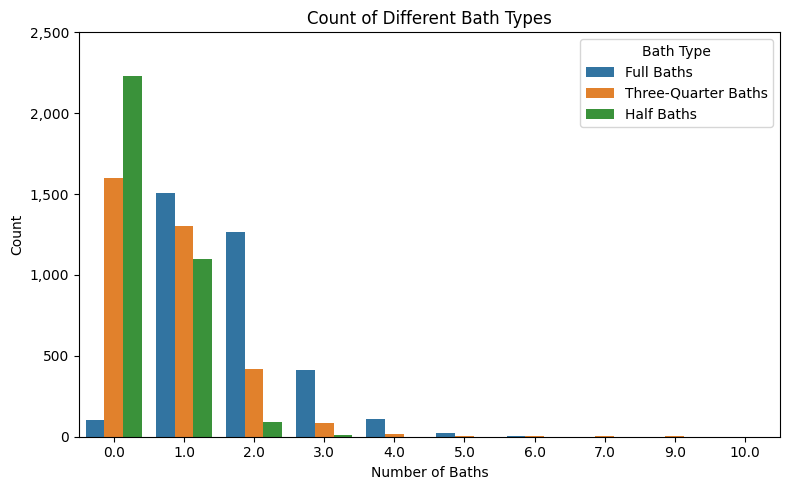

In [94]:
#Combine all the bath columns into one dataframe to visualize
bath_df = pd.melt(master_df,
                  value_vars=['nbr_full_baths', 'nbr_three_qtr_baths', 'nbr_half_baths'],
                  var_name='bath_type', value_name='count')

#Visualize the counts of bathroom types
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(x='count',
              hue='bath_type',
              data=bath_df)

#Add labels
ax.set_title('Count of Different Bath Types')
ax.set_xlabel('Number of Baths')
ax.set_ylabel('Count')
ax.legend(labels=['Full Baths', 'Three-Quarter Baths', 'Half Baths'], title='Bath Type')
#Format yticks with commas
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([f'{y:,.0f}' for y in ax.get_yticks()])

plt.tight_layout()

This seems to be a reasonable distribution of bathroom types on a property. We hypothesize that bathroooms may have a strong correlation with property valuation and so we will revisit bath room counts in later exploration.

### nbr_total_baths

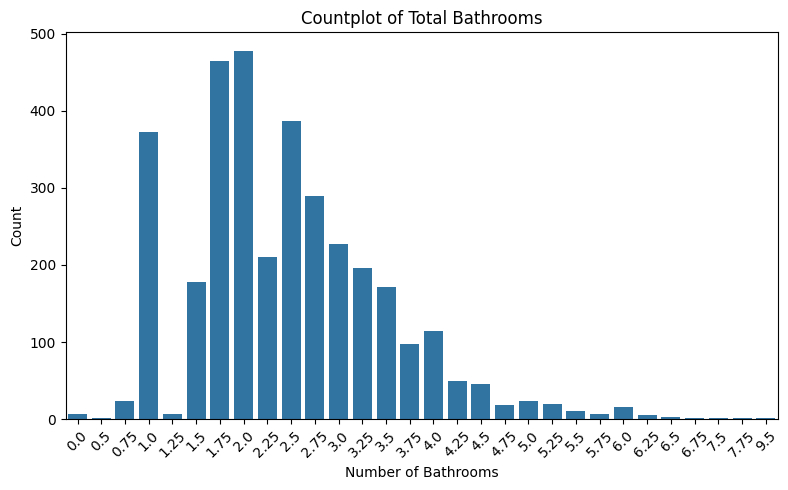

In [95]:
fig, ax = plt.subplots(figsize=(8, 5))

#Create countplot for nbr_total_baths
sns.countplot(x = 'nbr_total_baths',
              data = master_df)

#Set labels and title
ax.set_xlabel('Number of Bathrooms')
ax.set_ylabel('Count')
ax.set_title('Countplot of Total Bathrooms')

#Sets ticks on x-axis so that we can rotate
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.tight_layout()

As mentioned above, we hypothesize that bathroooms may have a strong correlation with property valuation and so we will revisit this overall bath room count in later exploration.

In [96]:
#master_df.nbr_total_baths.mean()
#master_df.nbr_total_baths.median()
#master_df.nbr_total_baths.std()
#master_df.nbr_total_baths.min()
master_df.nbr_total_baths.max()

9.5

### bath_room_ratio

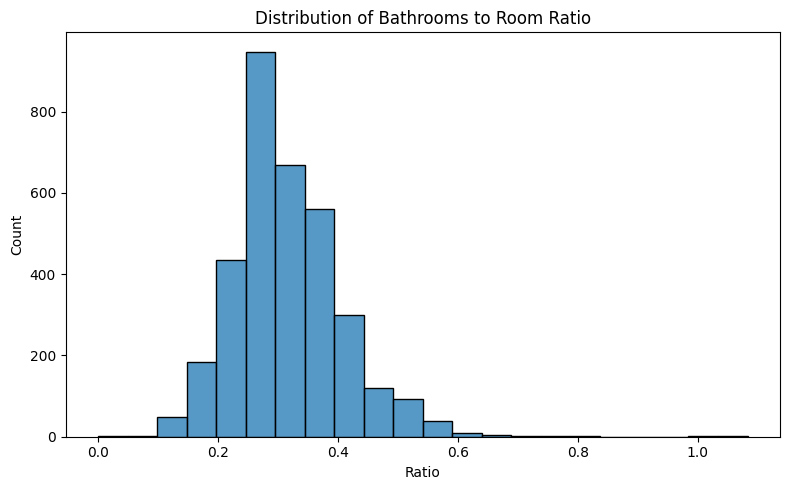

In [97]:
fig, ax = plt.subplots(figsize=(8, 5))

#Create histogram for distribution of bath_room_ratio
sns.histplot(x = 'bath_room_ratio',
             binwidth=.05,
              data = master_df)

#Add plot labels
ax.set_xlabel('Ratio')
ax.set_ylabel('Count')
ax.set_title('Distribution of Bathrooms to Room Ratio')

plt.tight_layout()

The distribution of the ratio of bathrooms to rooms is again normal-like, with a slight upper tail. This will be an interesting value to revisit in exploring the relationship between bathroom:room ratio and price.

### total_finished_sqft

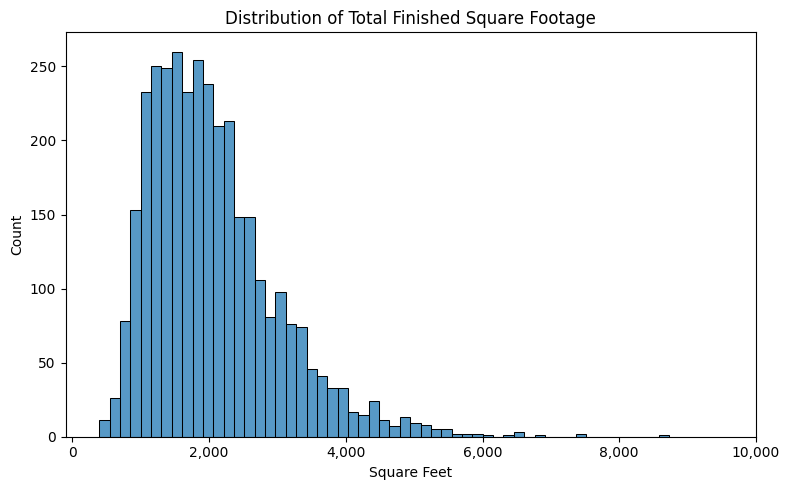

In [98]:
fig, ax = plt.subplots(figsize=(8, 5))

#Plot a histogram of the distribution of total_finished_sqft
sns.histplot(x = 'total_finished_sqft',
              data = master_df)

#Add labels
ax.set_xlabel('Square Feet')
ax.set_ylabel('Count')
ax.set_title('Distribution of Total Finished Square Footage')

#Format xticks with commas
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels([f'{y:,.0f}' for y in ax.get_xticks()])

#Format graph so that the prices begin at 0
ax.set_xlim(left=-100)

plt.tight_layout()

The distribution of total finished square feet is centered around 2,000 square feet with a long upper tail. This is reasonable to expect as we cannot have negative square feet so the distribution must be bounded on the left by zero, but does not technically have an upper bound.

### mainfloor_sqft, enclosed_sqft_total, and bsmt_sqft

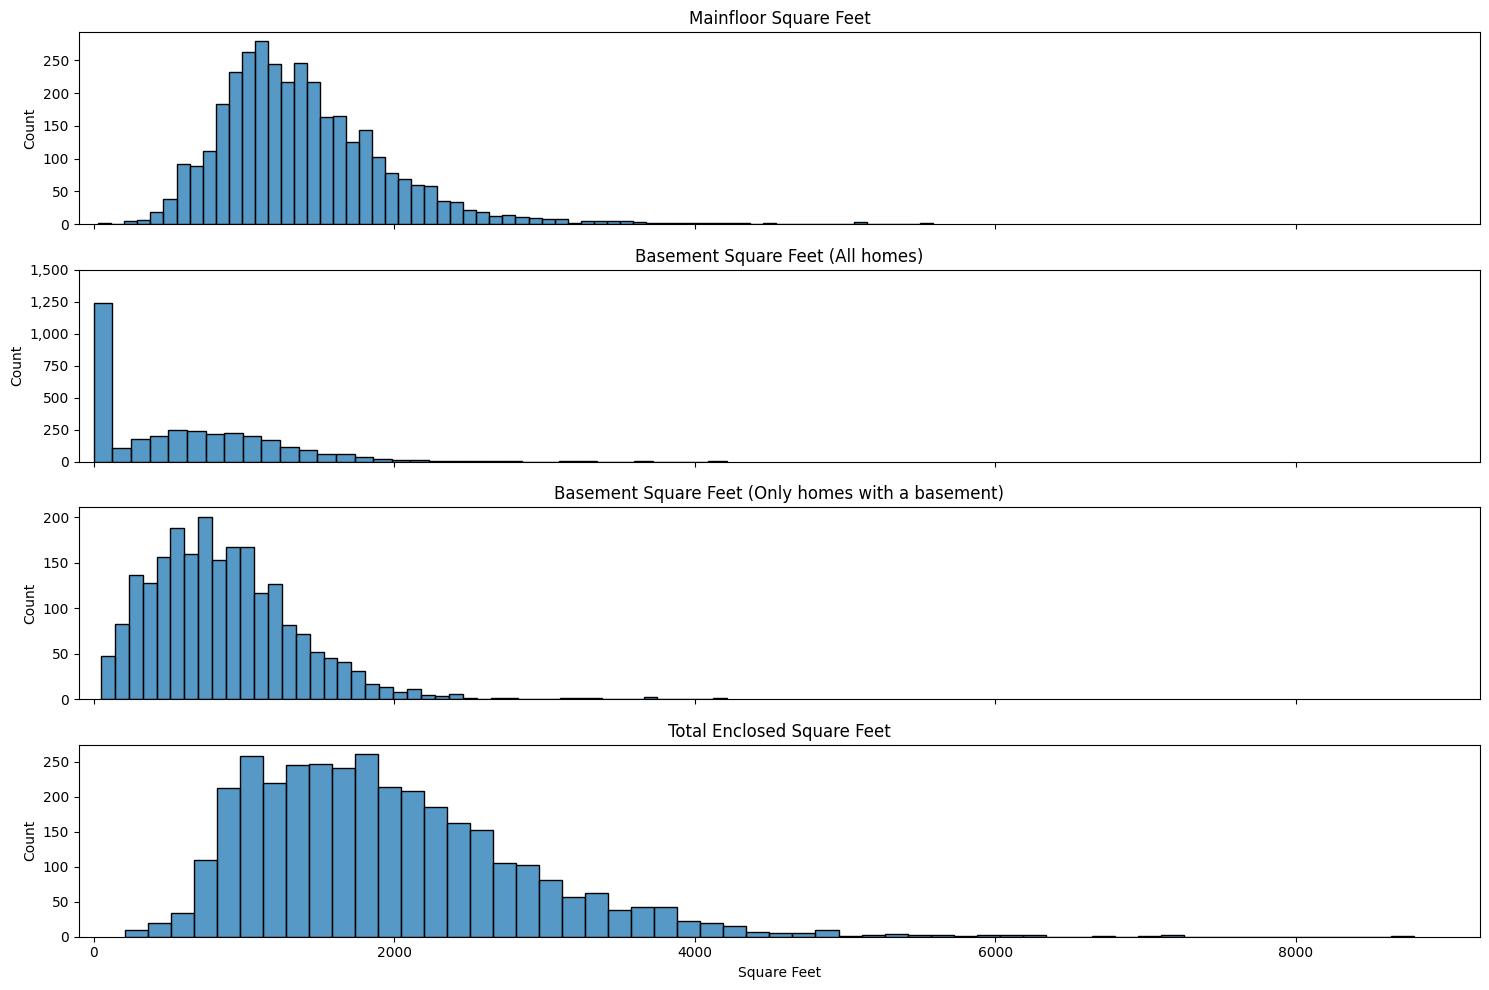

In [99]:
fig, (a, b, c,d) = plt.subplots(4, 1, sharex=True, figsize=(15, 10))

#Create a histogram of the distribution of mainfloor_sqft
sns.histplot(x = 'mainfloor_sqft',
             data = master_df,
             ax = a)
a.set_title('Mainfloor Square Feet')
a.set_xlabel('')

#Create a histogram of the distribution of bsmt_sqft
sns.histplot(x = 'bsmt_sqft',
             data = master_df,
             ax = b)
b.set_title('Basement Square Feet (All homes)')
b.set_xlabel('')
#Format yticks with commas
b.set_yticks(b.get_yticks())
b.set_yticklabels([f'{y:,.0f}' for y in b.get_yticks()])

#Create a histogram of the distribution of bsmt_sqft excluding homes with no basement
sns.histplot(x = 'bsmt_sqft',
             data = master_df[master_df.bsmt_sqft > 0],
             ax = c)
c.set_title('Basement Square Feet (Only homes with a basement)')
c.set_xlabel('')

#Create a histogram of the distribution of enclosed_sqft_total
sns.histplot(x = 'enclosed_sqft_total',
             data = master_df,
             ax = d)
d.set_title('Total Enclosed Square Feet')
d.set_xlabel('Square Feet')

#Format graph so that the prices begin at $0
d.set_xlim(left=-100)

plt.tight_layout()

As mentioned above, we can expect to see normal-like distributions of square feet with an upper tail due to the variable's lower bound. It is notable that the far majority of homes do not have a basement.

### land_sqft, land_acreage, and prop_overall_sqft

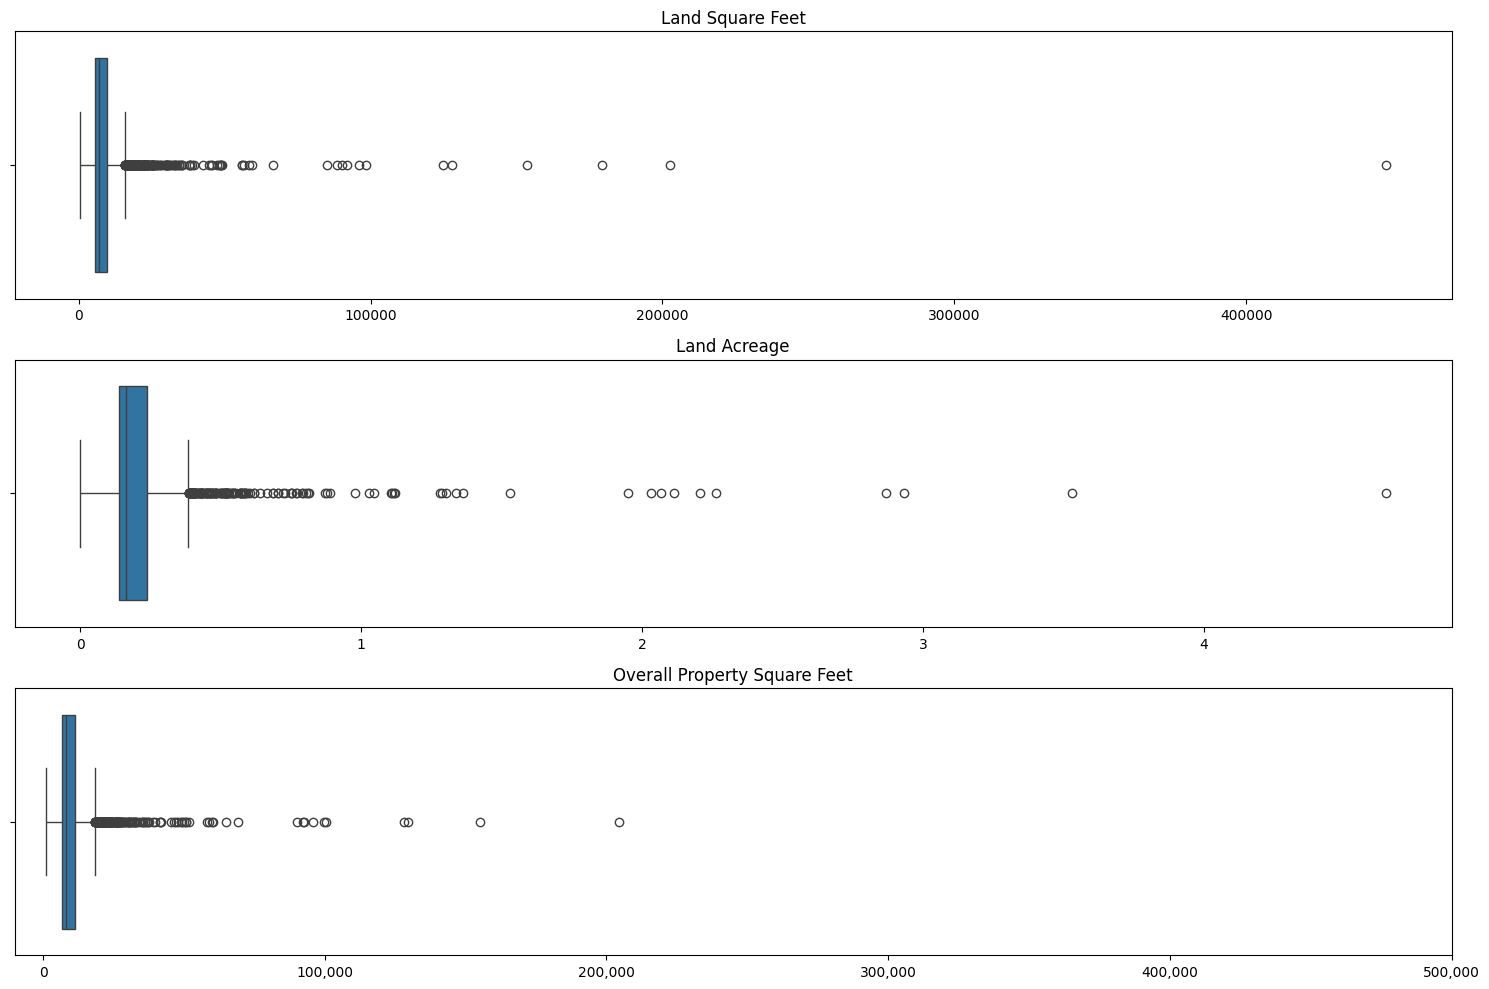

In [100]:
fig, (a, b, c) = plt.subplots(3, 1, sharex=False, figsize=(15, 10))

#Create a boxplot of the distribution of land_sqft
sns.boxplot(x = 'land_sqft',
             data = master_df,
             ax = a)
a.set_title('Land Square Feet')
a.set_xlabel('')

#Create a boxplot of the distribution of land_acreage
sns.boxplot(x = 'land_acreage',
             data = master_df[master_df.bsmt_sqft > 0],
             ax = b)
b.set_title('Land Acreage')
b.set_xlabel('')

#Create a boxplot of the distribution of prop_overall_sqft
sns.boxplot(x = 'prop_overall_sqft',
             data = master_df,
             ax = c)
c.set_title('Overall Property Square Feet')
c.set_xlabel('')

#Format xticks with commas
c.set_xticks(a.get_xticks())
c.set_xticklabels([f'{y:,.0f}' for y in c.get_xticks()])

#Format graph so that the prices begin at $0
c.set_xlim(left=-10000)

plt.tight_layout()

The boxplots above show that there are some properties that are signficantly larger than other properties.

These visualizations show that the far majority of properties have less than 25,000 total square feet (less than 0.5 acre), however there are some properties with a large amount of land.

### mainfloor_to_land_ratio

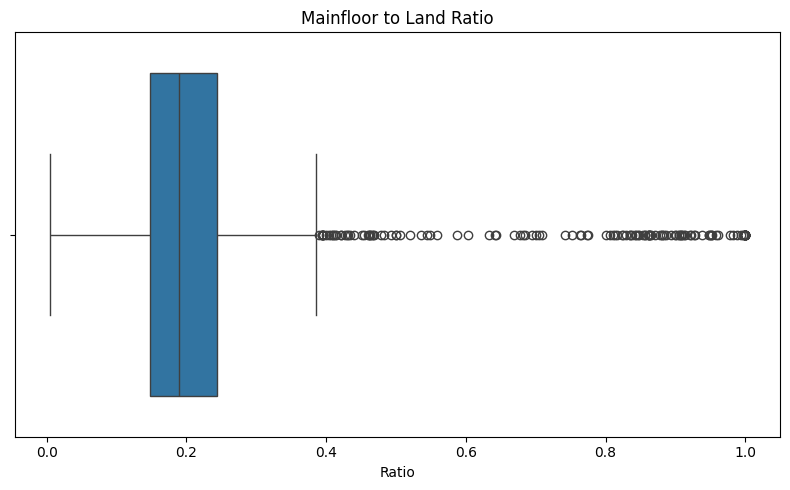

In [101]:
fig, ax = plt.subplots(figsize=(8, 5))

#Create a boxplot of mainfloor_to_land_ratio
sns.boxplot(x = 'mainfloor_to_land_ratio',
              data = master_df)

#Add labels
ax.set_xlabel('Ratio')
ax.set_ylabel('')
ax.set_title('Mainfloor to Land Ratio')

plt.tight_layout()

The distribution is centered at 0.2 with the majority of data less than or equal 0.4. However, there are a fair number of outliers on the upper tail.

### car_storage_type

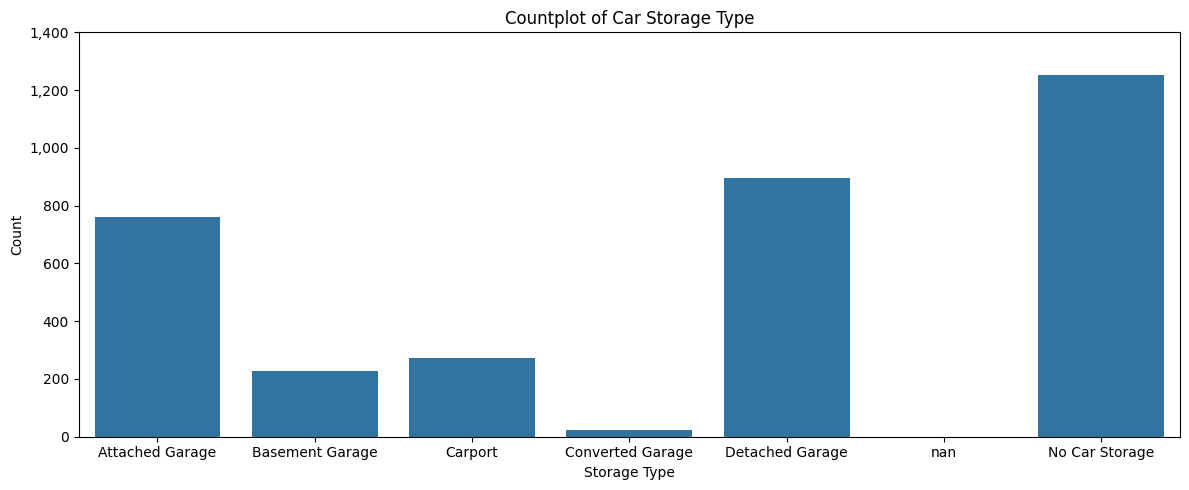

In [102]:
fig, ax = plt.subplots(figsize=(12, 5))

#Create a countplot of car_storage_type
sns.countplot(x = 'car_storage_type',
              data = master_df)

#Add axis labels and title
ax.set_xlabel('Storage Type')
ax.set_ylabel('Count')
ax.set_title('Countplot of Car Storage Type')

#Format yticks with commas
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([f'{y:,.0f}' for y in ax.get_yticks()])

plt.tight_layout()

The plot shows a label for nan values. Let's take a look at those rows in the table.

In [103]:
master_df[master_df.car_storage_type.isna()]

,address,num_of_buildings,effective_year_built,age_of_home,land_class_dscr,market_area,most_recent_trxn_date,num_trxns,price,adjusted_sales_price,price_per_overall_sqft,sales_cd_dscr,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,mill_levy,unincorporated,sub_dscr,design,quality,bldg_class,construction_type,nbr_bed_room,nbr_rooms_nobath,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_total_baths,bath_room_ratio,total_finished_sqft,mainfloor_sqft,enclosed_sqft_total,bsmt_sqft,land_sqft,land_acreage,prop_overall_sqft,mainfloor_to_land_ratio,car_storage_type,ext_wall,ac,heating,bsmt_design,bsmt_finish,market_area_mean,adj_sales_price_vs_mkt_area_mean,sub_code
strap,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


We have zero rows with na values in the table. Therefore this a reasonable distribution of values for Car Storage. It is notable that the majority of properties do not have any car storage. In future exploration, we will look at the existence of car storage vs. none to explore if there is a correlation with price valuation.

### ext_wall

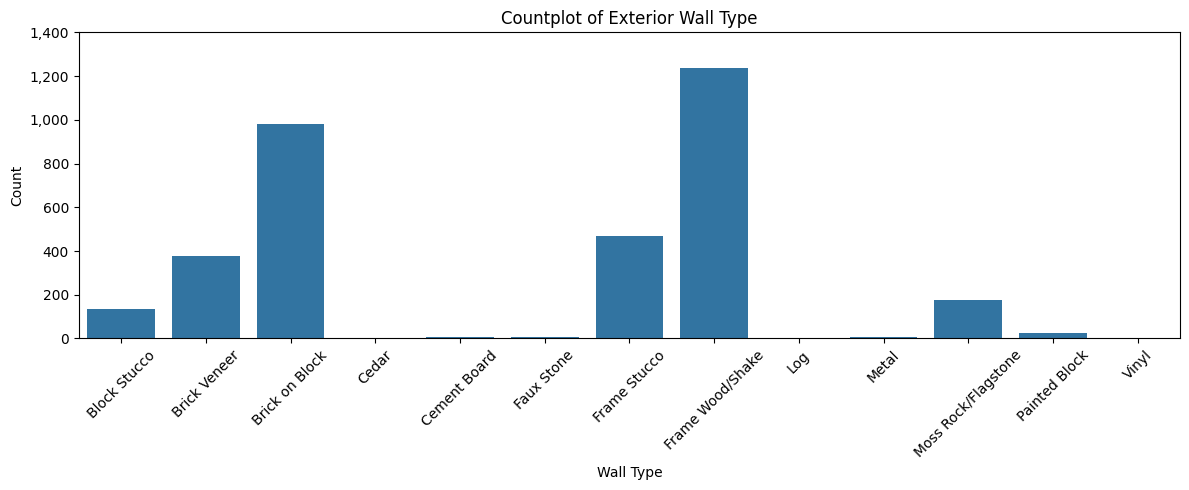

In [104]:
fig, ax = plt.subplots(figsize=(12, 5))

#Create a countplot of ext_wall
sns.countplot(x = 'ext_wall',
              data = master_df)

#Add labels
ax.set_xlabel('Wall Type')
ax.set_ylabel('Count')
ax.set_title('Countplot of Exterior Wall Type')

#Sets ticks on x-axis so that we can rotate
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

#Format yticks with commas
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([f'{y:,.0f}' for y in ax.get_yticks()])

plt.tight_layout()

There is a variety of wall types used on the exterior wall of the home.

### ac and heating

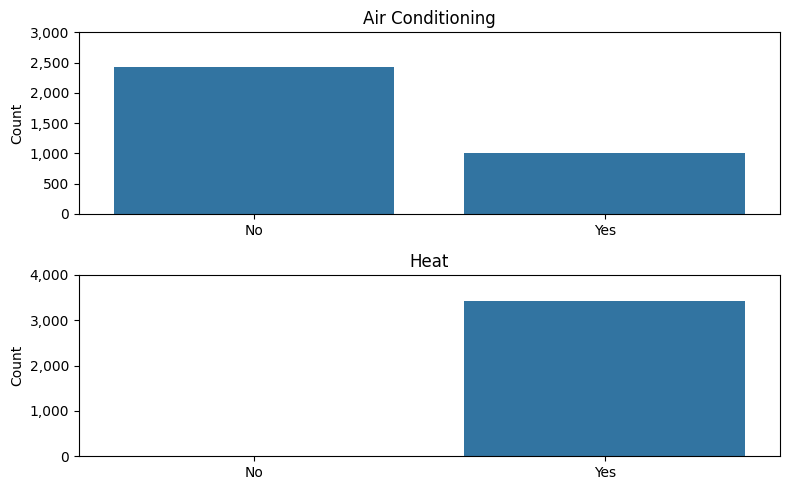

In [105]:
fig, (a, b) = plt.subplots(2, 1, sharex=False, figsize=(8, 5))

#Plot Air Conditioning
sns.countplot(x = 'ac',
             data = master_df,
             ax = a)

#Convert the 0,1 xticks to be no/yes
a.set_xticks([0, 1])
a.set_xticklabels(['No', 'Yes'])

a.set_xlabel('')
a.set_title("Air Conditioning")
a.set_ylabel('Count')
#Format yticks with commas
a.set_yticks(a.get_yticks())
a.set_yticklabels([f'{y:,.0f}' for y in a.get_yticks()])

#Plot Heating
sns.countplot(x = 'heating',
             data = master_df,
             ax = b)

#Convert the 0,1 xticks to be no/yes
b.set_xticks([0, 1])
b.set_xticklabels(['No', 'Yes'])

b.set_xlabel('')
b.set_title("Heat")
b.set_ylabel('Count')
#Format yticks with commas
b.set_yticks(b.get_yticks())
b.set_yticklabels([f'{y:,.0f}' for y in b.get_yticks()])

plt.tight_layout()

As can be expected in a colder climate like Boulder, all properties have heating, while a majority do not have air conditioning.

### bsmt_design and bsmt_finish

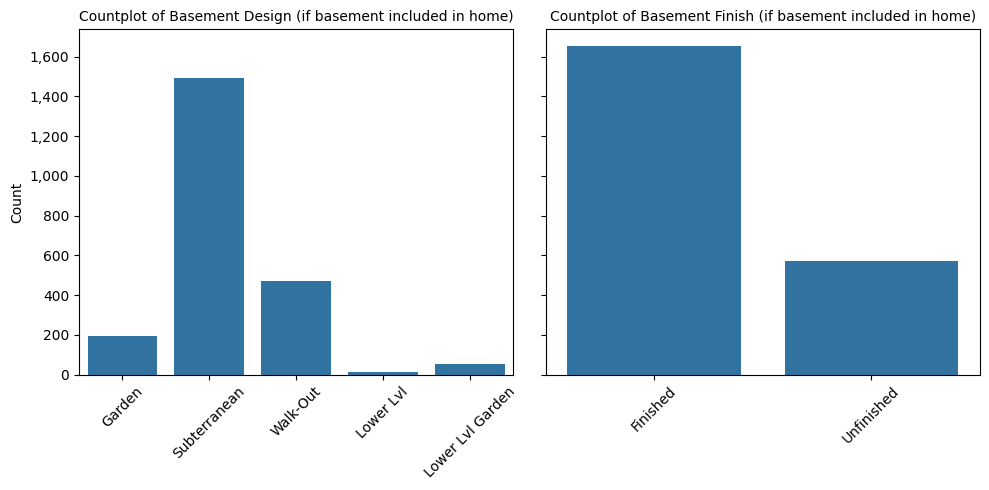

In [106]:
fig, (a, b) = plt.subplots(1, 2, sharey=True, figsize=(10, 5))

#Plot bsmt_design
sns.countplot(x = 'bsmt_design',
              data = master_df[master_df.bsmt_design != 'No Basement'],
             ax=a)
a.set_ylabel('Count')
a.set_xlabel('')
a.set_title('Countplot of Basement Design (if basement included in home)', fontsize=10)
#Sets ticks on x-axis so that we can rotate
a.set_xticks(a.get_xticks())
a.set_xticklabels(a.get_xticklabels(), rotation=45)
#Format yticks with commas
a.set_yticks(a.get_yticks())
a.set_yticklabels([f'{y:,.0f}' for y in a.get_yticks()])

#Plot bsmt_finish
sns.countplot(x = 'bsmt_finish',
              data = master_df[master_df.bsmt_finish != 'No Basement'],
             ax=b)
b.set_xlabel('')
b.set_title('Countplot of Basement Finish (if basement included in home)', fontsize=10)
#Sets ticks on x-axis so that we can rotate
b.set_xticks(b.get_xticks())
b.set_xticklabels(b.get_xticklabels(), rotation=45)

plt.tight_layout()

As has been noted above, there are a substantial amount of properties without a basement. However, in the properties with a basement, we see some variety in the design.

### adj_sales_price_vs_mkt_area_mean

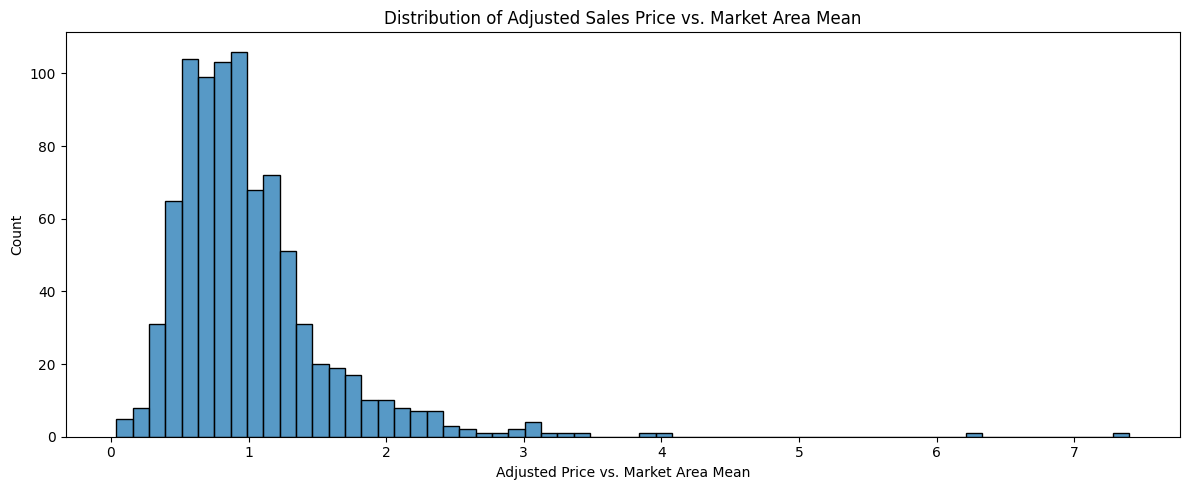

In [107]:
fig, ax = plt.subplots(figsize=(12, 5))

#Plot the distribution of adj_sales_price_vs_mkt_area_mean
sns.histplot(x = 'adj_sales_price_vs_mkt_area_mean',
              data = master_df)

#Add plot labels and title
ax.set_xlabel('Adjusted Price vs. Market Area Mean')
ax.set_ylabel('Count')
ax.set_title('Distribution of Adjusted Sales Price vs. Market Area Mean')

plt.tight_layout()

The adjusted price vs. market area mean normalizes the adjusted price across all market areas so that we can more easily compare between different areas. This is a right tailed distribution with a few outliers that are significantly higher than their market area mean.

## Multivariate Exploration

### Adjusted Sales Price and Market Area

Our group was interested in reviewing relationship between adjusted sale price and quality. In order to contextualize the values available for us, we created a boxplot to see how price increased based on the assessed quality of the home, to determine whether additional inquiry into the assessment methodology was necessary.

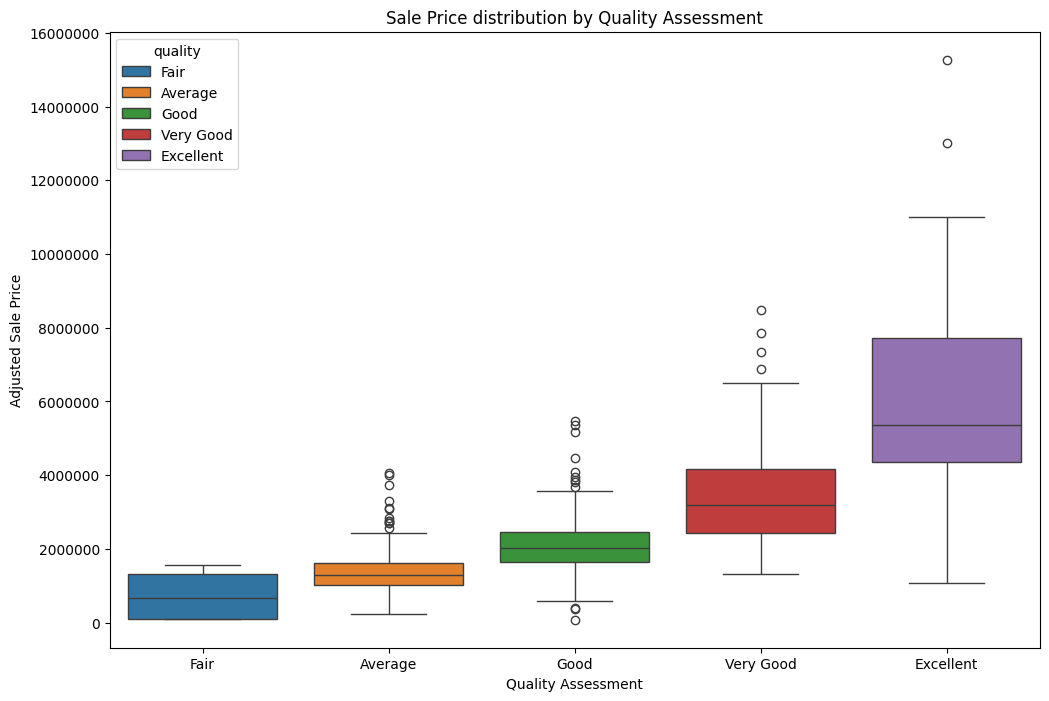

In [108]:
# Create boxplot of most recent sales Price vs Quality
plt.figure(figsize=(12, 8))
sns.boxplot(data=master_df, x='quality', y='adjusted_sales_price', hue='quality')

# Add labels and title
plt.title('Sale Price distribution by Quality Assessment')
plt.xlabel('Quality Assessment')
plt.ylabel('Adjusted Sale Price')
plt.ticklabel_format(axis='y', style='plain', scilimits=(0, 0))

### Adjusted Sales Price and Market Area

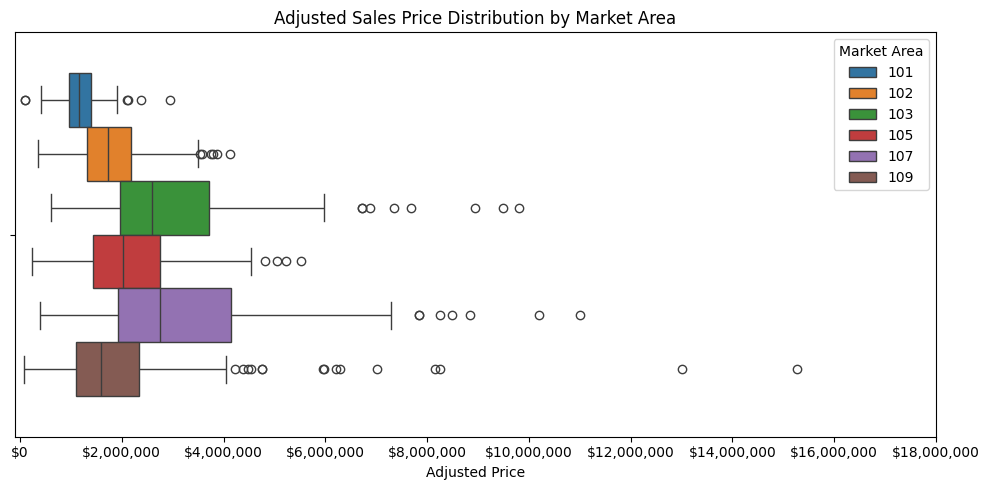

In [109]:
fig, ax = plt.subplots(figsize=(10, 5))

#Create boxplots of the distribution of adjusted_sales_price for each market area
sns.boxplot(x = 'adjusted_sales_price',
            hue='market_area',
            data = master_df)

#Add labels
ax.set_xlabel('Adjusted Price')
ax.set_title('Adjusted Sales Price Distribution by Market Area')
ax.legend(title='Market Area')

#Format xticks with commas and dollar signs
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels([f'${y:,.0f}' for y in ax.get_xticks()])

#Format graph so that the prices begin at $0
ax.set_xlim(left=-100000)

plt.tight_layout()

The market areas has a fair amount of variability in their adjusted price distributions. Market area 101 has a small spread spread, whereas market area 109 is significantly spread out. The other market areas' spreads fall inbetween these two. Based on reviewing the distribution of adjusted sales price, there is not a notable difference in values between market areas. The highest values do fall in market area 109, however so too do the lowest values.

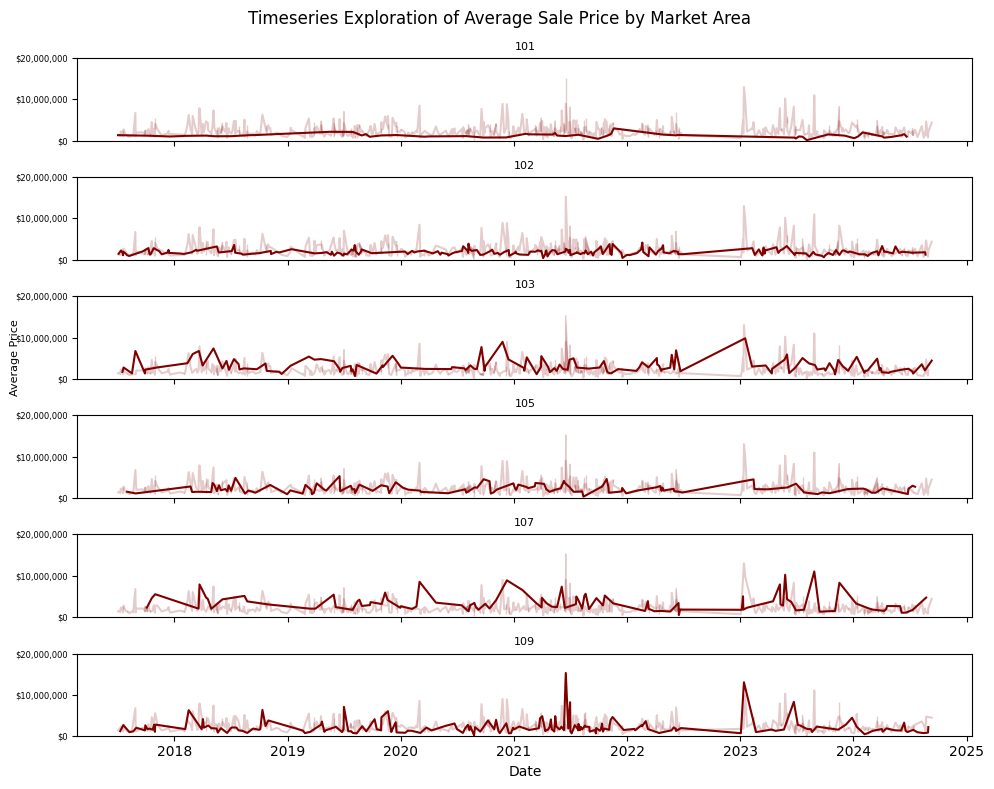

In [110]:
#Create a dataframe grouped by date and market_area to find the average adjusted sales price for each market area over time
price_trend_df = master_df.groupby(['most_recent_trxn_date', 'market_area']).agg({'adjusted_sales_price':'mean'}, observed=True).reset_index()
price_trend_df = price_trend_df.rename(columns={'adjusted_sales_price':'avg_price'})

#Create an array of the unique market area values
market_areas = np.sort(price_trend_df['market_area'].unique())

#Create timeseries graphs that focus on each individual market area over time.
fig, axes = plt.subplots(6, 1, figsize=(10, 8), sharex=True)

#Loop through each market area and graph it on an axis in the figure
for i, market_area in enumerate(market_areas):
    ax = axes[i]

    #Graph all the other market areas so they are visible behind the market area of interest
    sns.lineplot(x='most_recent_trxn_date',
                 y='avg_price',
                 data=price_trend_df[price_trend_df['market_area'] != market_area],
                 alpha=0.2,
                 color='maroon',
                 ax=ax)

    #Graph the market area of interest on top of the other market areas
    sns.lineplot(x='most_recent_trxn_date',
                 y='avg_price',
                 data=price_trend_df[price_trend_df['market_area'] == market_area],
                 ax=ax,
                 color='maroon')
    ax.set_title(market_area, fontsize=8)
    ax.set_ylabel('')
    #Format yticks with commas and dollar signs
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels([f'${y:,.0f}' for y in ax.get_yticks()], fontsize=6)
    #Format graph so that the prices begin at $0
    ax.set_ylim(bottom=-100)

fig.text(0.01, 0.5, 'Average Price', rotation='vertical', fontsize=8)
axes[5].set_xlabel('Date')
fig.suptitle('Timeseries Exploration of Average Sale Price by Market Area')

plt.tight_layout()

Some market areas have had little variety in average price, while others have fluctuated frequently. Market area 101 has a notably smooth timeseries, with only one distribution around 2022. In general, the other five market areas tend to follow similar trends, however the extremes of these trends vary by market area. Each of these five markets experienced a notable event around the start of 2023. All these market areas experienced an increase in average price and then a sharp decrease. Overall, market area 109 seems to have the most variability in prices, with frequent ups and downs starting in the second half of 2020 and lasting until the end of 2021.

In [111]:
#Create a dataframe grouped by year and market area to find the average sales price per year per market area
price_df = master_df.groupby([pd.to_datetime(master_df['most_recent_trxn_date']).dt.year, 'market_area'], observed=True).agg({'adjusted_sales_price':'mean'}).reset_index()
price_df.most_recent_trxn_date = pd.to_numeric(price_df['most_recent_trxn_date'], errors='coerce').astype('Int64')

#Pivot the data into a readable table
price_table = price_df[price_df.adjusted_sales_price.notna()].pivot(index='market_area',
                                                      columns='most_recent_trxn_date',
                                                      values='adjusted_sales_price').reset_index().rename(columns={'market_area':''})

#Display Title
from IPython.display import display, Markdown
display(Markdown("### Average Market Area Price by Year"))

#Customize table styles by adding color to the header and alternating between white and gray rows of data
table_styled = price_table.style \
    .set_table_styles([
        {'selector': 'thead th', 'props': [('background-color', 'navy'), ('color', 'white')]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
        {'selector': 'tbody tr:nth-child(odd)', 'props': [('background-color', 'white')]},
    ]) \
    .hide(axis="index") \
    .highlight_max(axis=0, color='yellow', subset=price_table.columns[1:])

#Format the prices in the table
format_dict = {}
#Loop over all the columns in the price_table and save a financial formatting for the prices in a dictionary by column
for col in price_table.columns:
    if isinstance(col, int):
        format_dict[col] = '${:,.0f}'

#Apply the formatting to the table
table_styled.format(format_dict)

### Average Market Area Price by Year

,2017,2018,2019,2020,2021,2022,2023,2024
101,"$1,156,223","$1,153,558","$1,500,952","$899,046","$1,484,384","$1,348,333","$748,889","$1,224,045"
102,"$1,708,563","$1,852,988","$1,752,898","$1,817,220","$1,806,532","$1,984,879","$1,807,987","$1,780,047"
103,"$2,641,376","$3,439,204","$3,245,201","$3,487,986","$2,780,991","$3,314,838","$3,387,488","$2,399,059"
105,"$1,232,675","$2,096,735","$2,338,552","$2,194,457","$2,343,828","$1,866,438","$2,101,070","$1,938,889"
107,"$4,067,187","$3,965,096","$3,237,998","$3,300,361","$3,720,091","$1,838,822","$3,886,421","$2,177,250"
109,"$1,700,266","$2,163,745","$2,020,570","$1,680,973","$2,454,000","$1,810,303","$2,859,853","$1,300,221"


### Adjusted Sales Price and Age of Home

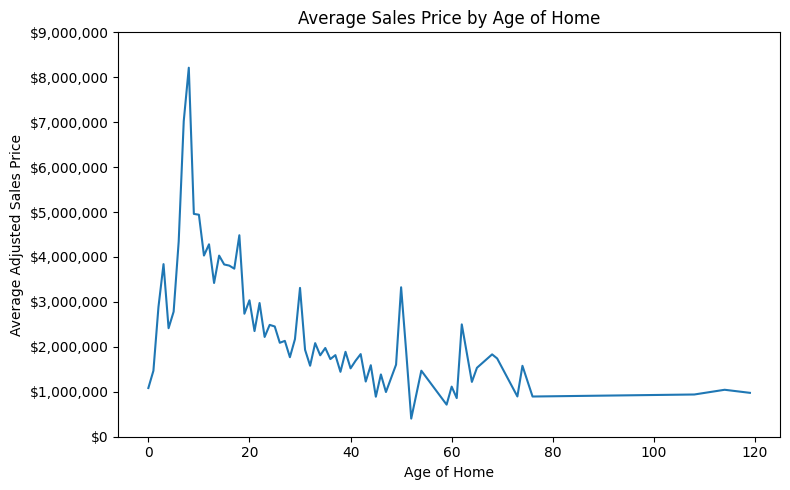

In [112]:
#Price of new vs. historic homes
price_age_df = master_df.groupby('age_of_home').agg({'adjusted_sales_price':'mean'}).reset_index()

#Plot a lineplot of adjusted sales price for different ages of the home
fig, axes = plt.subplots(figsize=(8, 5))
sns.lineplot(x='age_of_home',
             y='adjusted_sales_price',
             data=price_age_df)

#Add labels
axes.set_xlabel('Age of Home')
axes.set_ylabel('Average Adjusted Sales Price')
axes.set_title('Average Sales Price by Age of Home')

#Format yticks with commas and dollar signs
axes.set_yticks(axes.get_yticks())
axes.set_yticklabels([f'${y:,.0f}' for y in axes.get_yticks()])

plt.tight_layout()

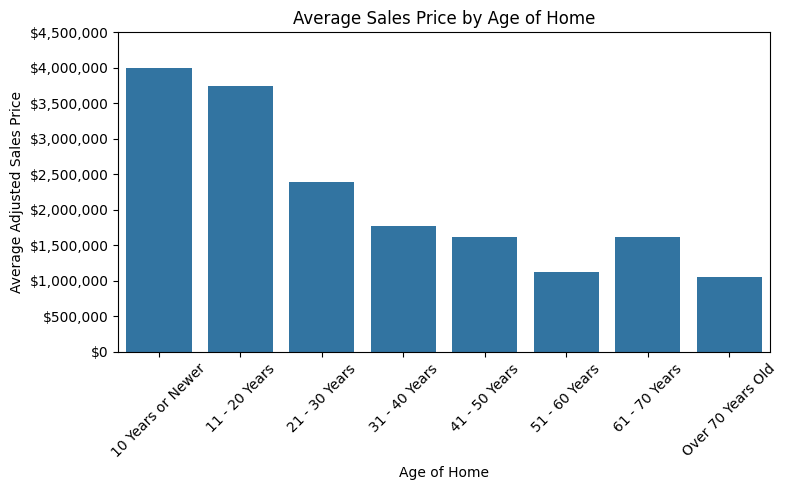

In [113]:
#Cluster the age_of_home value into 10-year buckets
price_age_df['age_ranges'] = pd.cut(price_age_df['age_of_home'],
                                    bins=[-1,10,20,30,40,50,60,70,500],
                                    labels=['10 Years or Newer','11 - 20 Years','21 - 30 Years','31 - 40 Years','41 - 50 Years',
                                            '51 - 60 Years','61 - 70 Years','Over 70 Years Old'])

fig, axes = plt.subplots(figsize=(8, 5))
#Plot the average adjusted sales for each age_range bucket
sns.barplot(x='age_ranges',
            y='adjusted_sales_price',
            data=price_age_df.groupby('age_ranges', observed=True).agg({'adjusted_sales_price':'mean'}))

#Add labels and format axes
axes.set_xticks(price_age_df['age_ranges'].values.unique())
axes.set_xticklabels(axes.get_xticklabels(), rotation=45)
axes.set_xlabel('Age of Home')
axes.set_ylabel('Average Adjusted Sales Price')
#Format yticks with commas and dollar signs
axes.set_yticks(axes.get_yticks())
axes.set_yticklabels([f'${y:,.0f}' for y in axes.get_yticks()])

axes.set_title('Average Sales Price by Age of Home')

plt.tight_layout()

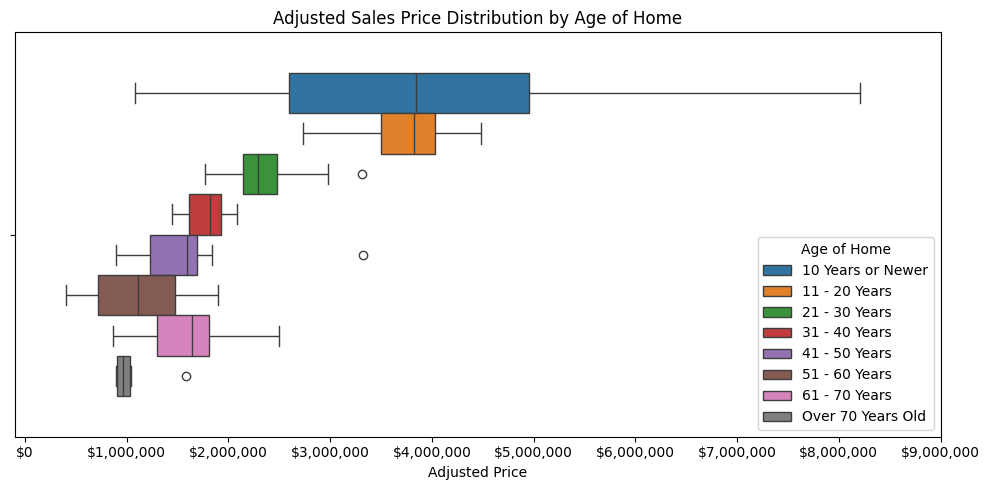

In [114]:
fig, ax = plt.subplots(figsize=(10, 5))

#Create boxplots of the distribution of adjusted_sales_price for each home age
sns.boxplot(x = 'adjusted_sales_price',
            hue='age_ranges',
            data = price_age_df)

#Add labels
ax.set_xlabel('Adjusted Price')
ax.set_title('Adjusted Sales Price Distribution by Age of Home')
ax.legend(title='Age of Home')

#Format xticks with commas and dollar signs
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels([f'${y:,.0f}' for y in ax.get_xticks()])

#Format graph so that the prices begin at $0
ax.set_xlim(left=-100000)

plt.tight_layout()

The visualizations above are helpful in understanding the price trend for properties based on their age. It appears that there are some historic homes (older than 70 years) in this area, however the historic nature of the property does not result in a higher price. The alternative is true as the data shows that newer homes have significantly higher average prices than older homes. However, it is helpful to note that in the distribution plot, the newest homes have the largest spread of data, which could be contributing to the high average value.

### Bucket Qualitative Variables to Compare to Adjusted Price

Some of the variables, such as design, car_storage_type, bsmt_design, and bsmt_finish have mutliple categories that may affect the correlation with adjusted_sales_price. In this section, we will bucket categories together to create 'codes' for these variables and then determine the correlation of the bucketed values with adjusted_sales_price.

design_code currently includes 8 qualitative values. Based on the value_counts, it appears that the 2-3 Story House and 1 Story House are most popular. We will therefore create buckets for each of these values and collect all other values into a third bucket.

In [115]:
pd.set_option('future.no_silent_downcasting', True)

#Create a numeric code for designs
master_df.design.value_counts()
master_df['design_code'] = master_df.design

#Create a bucket_mapping of new values
#Keep 2-3 Story House and 1 Story House sepearate and combine everything else
bucket_mapping = {'2-3 Story House': 1,
                  '1 Story House': 2,
                  'Townhouse': 0,
                  'Multilevel House':0,
                  'Studio':0,
                  'Detached Garage': 0,
                  'Other':0,
                  'Storage': 0}
#Map the old values into the buckets
master_df.design_code = master_df.design_code.map(bucket_mapping)
#Convert design_code to an int
master_df['design_code'] = pd.to_numeric(master_df['design_code'], errors='coerce').astype('Int64')

car_storage type includes 6 qualitative values about the various types of car storage available in the properties. While the variety of styles may have some effect on price, we would like to know if having car storage versus not having it is an indicator of price. Therefore, we will combine all the types of car storage into one bucket and compare it to properties with No Car Storage.

In [116]:
#Create a numeric code for car_storage_type to compare properties with and without garages
master_df.car_storage_type.value_counts()
master_df['car_storage_code'] = master_df.car_storage_type
#Create the buckets
bucket_mapping = {'No Car Storage': 0,
                  'Detached Garage': 1,
                  'Attached Garage': 1,
                  'Carport': 1,
                  'Basement Garage': 1,
                  'Converted Garage': 1}
#Map the old values into the buckets
master_df.car_storage_code = master_df.car_storage_code.map(bucket_mapping)
#Convert car_storage_code to an int
master_df['car_storage_code'] = pd.to_numeric(master_df['car_storage_code'], errors='coerce').astype('Int64')

Much like car_storage, bsmt_design has 6 qualitative variables, however it may be that prices are more connected to whether a property has a basement and not the specific type. Therefore, we will combine all the types of basement into one bucket and compare it to properties with No Basement.

In [117]:
#Create a numeric code for bsmt_design to compare properties with and without basements
master_df.bsmt_design.value_counts()
master_df['bsmt_design_code'] = master_df.bsmt_design
master_df.bsmt_design_code = master_df.bsmt_design_code.replace({'Subterranean':1,
                                                                 'No Basement':0,
                                                                 'Walk-Out':1,
                                                                 'Garden':1,
                                                                 'Lower Lvl Garden':1,
                                                                 'Lower Lvl':1})
#Convert bsmt_design_code to an int
master_df['bsmt_design_code'] = pd.to_numeric(master_df['bsmt_design_code'], errors='coerce').astype('Int64')

Our bsmt_design_code variable will capture information about whether a property has a basement or not. In bsmt_finish, we would like to know if having a finished basement versus an unfinished basement affects the price. We do not want the values with No Basement to affect this analysis and so we will create a bsmt_finish code that keeps No Basement as NA and so we can compare Finished vs. Unfinished.

In [118]:
master_df.bsmt_finish.value_counts()
master_df['bsmt_finish_code'] = master_df.bsmt_finish
master_df.bsmt_finish_code=master_df.bsmt_finish_code.replace({'Finished':1,
                                                               'No Basement': np.nan,
                                                               'Unfinished':0})
#Convert bsmt_finish_code to an int
master_df['bsmt_finish_code'] = pd.to_numeric(master_df['bsmt_finish_code'], errors='coerce').astype('Int64')

Now that we have converted these qualitative variables into numbered buckets, we can create a correlation matrix with adjusted_sales_price. We will include sub_code that was created earlier in this exploration.

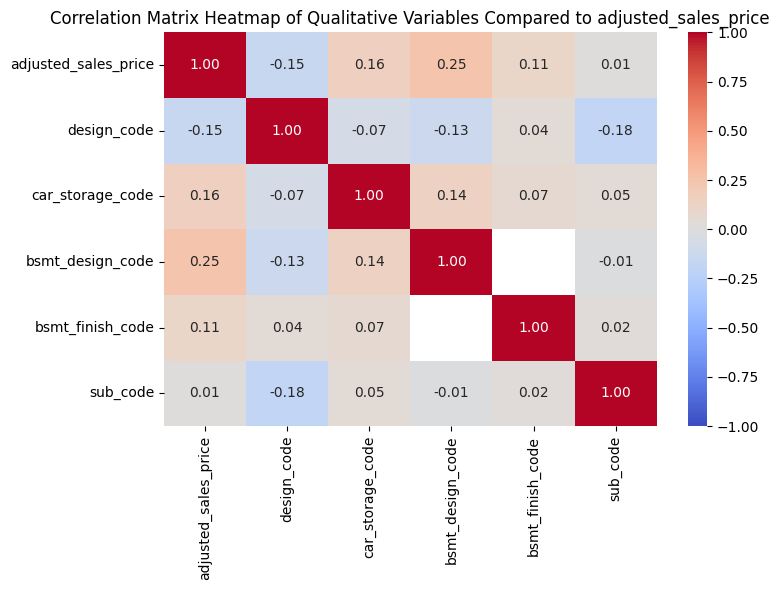

In [119]:
#Determine the correlation of the bucketed variables to adjusted_sales_price
qual_corr = master_df[['adjusted_sales_price','design_code','car_storage_code','bsmt_design_code','bsmt_finish_code','sub_code']].corr()

#Create a heatmap of the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(qual_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)

plt.title('Correlation Matrix Heatmap of Qualitative Variables Compared to adjusted_sales_price')
plt.tight_layout()

According to the heatmap above, it appears that there is a weak relationship between adjusted_sales_price and all of the tested qualitative variables. The highest correlation is a value of 0.25 for the basement design which compared properties with basements to properties without them. This correlation value is still relatively low, however, it may warrant further testing.

### Assessing base sizes by Quality Score and proportions of each Market Area.

Below we conducted some exploratory analysis on the quality variable, looking for potentially erroneous/inconclusive data to anticipate issues in our analysis.

In [120]:
fair_mask=master_df['quality']=='Fair'
average_mask=master_df['quality']=='Average'
good_mask=master_df['quality']=='Good'
very_good_mask=master_df['quality']=='Very Good'
excellent_mask=master_df['quality']=='Excellent'

In [121]:
#pull all values by quality score to look at prop by market area
fair_market_area=master_df[fair_mask]['market_area'].value_counts()
average_market_area=master_df[average_mask]['market_area'].value_counts()
good_market_area=master_df[good_mask]['market_area'].value_counts()
very_good_market_area=master_df[very_good_mask]['market_area'].value_counts()
excellent_market_area=master_df[excellent_mask]['market_area'].value_counts()

In [122]:
#VERY LOW BASE SIZE
fair_homes=fair_market_area.iloc[1:].sum()
fair_percent=fair_market_area.iloc[1:]/fair_homes
fair_percent

,count
market_area,
105,0.67
107,0.17
109,0.17
102,0.00
103,0.00


In [123]:
average_homes=average_market_area.iloc[1:].sum()
average_percent=average_market_area.iloc[1:]/average_homes
average_percent

,count
market_area,
109,0.36
105,0.25
101,0.18
103,0.11
107,0.09


In [124]:
good_homes=good_market_area.iloc[1:].sum()
good_percent=good_market_area.iloc[1:]/good_homes
good_percent

,count
market_area,
109,0.31
103,0.23
105,0.22
107,0.20
101,0.04


In [125]:
very_good_homes=very_good_market_area.iloc[1:].sum()
very_good_percent=very_good_market_area.iloc[1:]/very_good_homes
very_good_percent

,count
market_area,
107,0.32
102,0.26
109,0.23
105,0.17
101,0.01


In [126]:
excellent_homes=excellent_market_area.iloc[1:].sum()
excellent_percent=excellent_market_area.iloc[1:]/excellent_homes
excellent_percent

,count
market_area,
107,0.48
109,0.25
102,0.16
105,0.11
101,0.00


### Examining Correlation between Numeric variables

Below, we created a heatmap of the correlation matrix consisting of each numeric variable in our data frame. At this stage, we are searching for variables of interest that can help to further our understanding of the data and variables that influence prices of homes in our dataset.

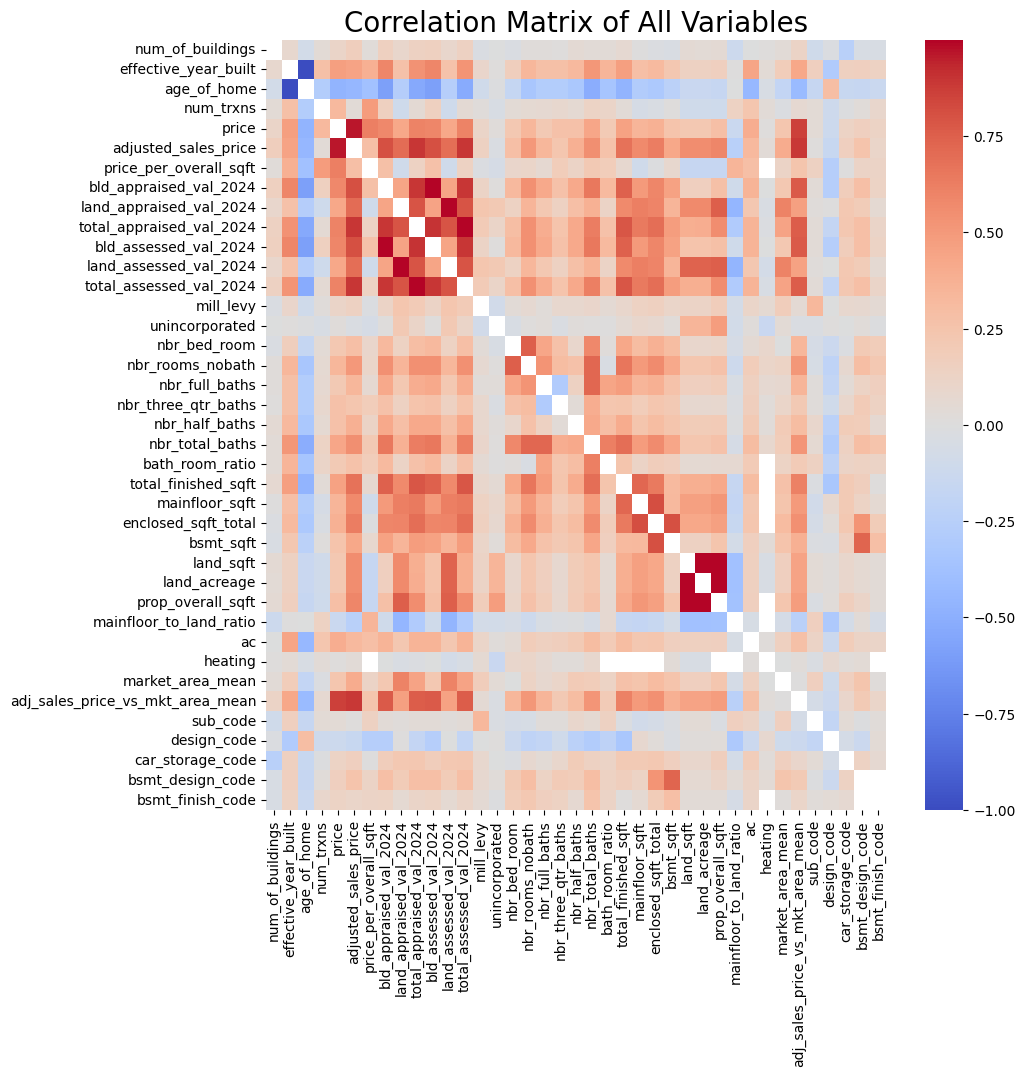

In [127]:
corr_matrix=master_df.select_dtypes(include='number').corr()
masked_corr = corr_matrix[corr_matrix<1]


plt.figure(figsize=(10,10))
sns.heatmap(masked_corr, cmap='coolwarm')
plt.title('Correlation Matrix of All Variables', fontsize=20)
plt.show()

In reviewing the graph above, we found that our adjusted sales prices were most strongly correlated with square footage and square footage variants. Chief among these was our total_finished_sqft variable, which combines the interior living square footage with the square footage of finished basements, where applicable. As shown below, the correlation increases as the square footage is narrowed down from total property square footage, to indoor square footage, to finished square footage.

In [128]:
#adj price correlated with total finished, enclosed sq ft, total prop sqft

high_corr_cols=['adjusted_sales_price', 'total_finished_sqft', 'enclosed_sqft_total', 'prop_overall_sqft', 'nbr_total_baths']

master_df[high_corr_cols].corr()

#pretty high correlation here, looks like sqft<indoor sqft<FINISHED sqft

,adjusted_sales_price,total_finished_sqft,enclosed_sqft_total,prop_overall_sqft,nbr_total_baths
adjusted_sales_price,1.00,0.67,0.63,0.59,0.55
total_finished_sqft,0.67,1.00,0.64,0.42,0.69
enclosed_sqft_total,0.63,0.64,1.00,0.47,0.57
prop_overall_sqft,0.59,0.42,0.47,1.00,0.27
nbr_total_baths,0.55,0.69,0.57,0.27,1.00


In our EDA, we touched upon the increase in sale price relative to changes in assessed quality, and we see a strong correlation upon including our ranked numerical quality assessment below.

In [129]:
# looking at quality scores relative to high corr attrib
if master_df['quality'].dtype.name == 'category':
    master_df['quality_numeric'] = master_df['quality'].cat.codes

quality_corr_cols=['adjusted_sales_price','quality_numeric', 'total_finished_sqft', 'enclosed_sqft_total', 'prop_overall_sqft']

master_df[quality_corr_cols].corr()

,adjusted_sales_price,quality_numeric,total_finished_sqft,enclosed_sqft_total,prop_overall_sqft
adjusted_sales_price,1.00,0.72,0.67,0.63,0.59
quality_numeric,0.72,1.00,0.72,0.57,0.38
total_finished_sqft,0.67,0.72,1.00,0.64,0.42
enclosed_sqft_total,0.63,0.57,0.64,1.00,0.47
prop_overall_sqft,0.59,0.38,0.42,0.47,1.00


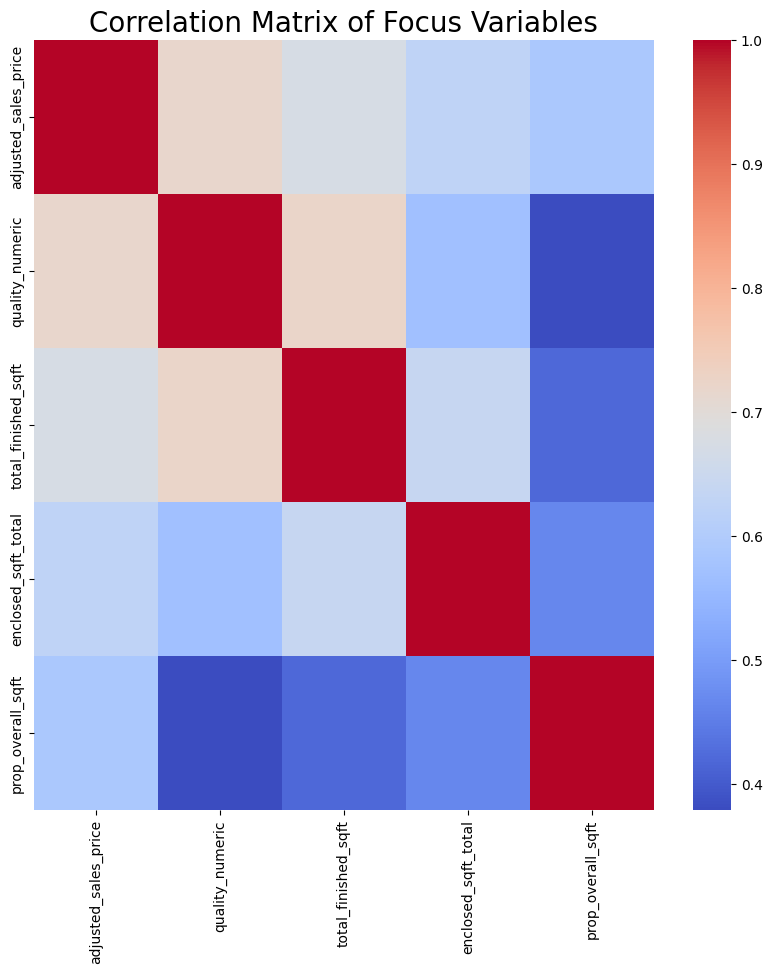

In [130]:
plt.figure(figsize=(10,10))
sns.heatmap(master_df[quality_corr_cols].corr(), cmap='coolwarm')
plt.title('Correlation Matrix of Focus Variables', fontsize=20)
plt.show()

There were not many numerical attributes that had an adverse effect on the home, which we explored below.

In [131]:
#low correlations
corr_matrix=master_df.select_dtypes(include='number').corr()
masked_corr = corr_matrix[corr_matrix<.71]


# plt.figure(figsize=(15,15))
# sns.heatmap(masked_corr, cmap='coolwarm')
masked_corr

#nothing super compelling here with respect to price here

,num_of_buildings,effective_year_built,age_of_home,num_trxns,price,adjusted_sales_price,price_per_overall_sqft,bld_appraised_val_2024,land_appraised_val_2024,total_appraised_val_2024,bld_assessed_val_2024,land_assessed_val_2024,total_assessed_val_2024,mill_levy,unincorporated,nbr_bed_room,nbr_rooms_nobath,nbr_full_baths,nbr_three_qtr_baths,nbr_half_baths,nbr_total_baths,bath_room_ratio,total_finished_sqft,mainfloor_sqft,enclosed_sqft_total,bsmt_sqft,land_sqft,land_acreage,prop_overall_sqft,mainfloor_to_land_ratio,ac,heating,market_area_mean,adj_sales_price_vs_mkt_area_mean,sub_code,design_code,car_storage_code,bsmt_design_code,bsmt_finish_code,quality_numeric
num_of_buildings,NaN,0.08,-0.08,0.04,0.11,0.17,0.03,0.15,0.09,0.15,0.15,0.09,0.15,-0.03,-0.01,-0.02,0.02,0.02,0.01,0.05,0.04,0.03,0.07,0.01,-0.02,-0.04,0.05,0.05,0.05,-0.12,-0.01,0.01,0.03,0.12,-0.10,-0.02,-0.25,-0.04,-0.05,0.10
effective_year_built,0.08,NaN,-1.00,0.28,0.47,0.45,0.38,0.59,0.27,0.53,0.59,0.26,0.53,0.10,0.01,0.17,0.34,0.27,0.28,0.32,0.51,0.34,0.47,0.29,0.32,0.23,0.15,0.15,0.16,0.01,0.44,0.04,0.18,0.42,0.16,-0.30,0.15,0.16,0.14,0.57
age_of_home,-0.08,-1.00,NaN,-0.28,-0.47,-0.45,-0.38,-0.59,-0.27,-0.53,-0.59,-0.26,-0.53,-0.10,-0.01,-0.17,-0.34,-0.27,-0.28,-0.32,-0.51,-0.34,-0.47,-0.29,-0.32,-0.23,-0.15,-0.15,-0.16,-0.01,-0.44,-0.04,-0.18,-0.42,-0.16,0.30,-0.15,-0.16,-0.14,-0.57
num_trxns,0.04,0.28,-0.28,NaN,0.32,0.03,0.49,0.15,-0.10,0.05,0.15,-0.10,0.05,0.02,-0.05,0.04,0.06,0.07,0.08,0.06,0.13,0.11,0.03,-0.06,-0.03,0.01,-0.10,-0.10,-0.11,0.14,0.24,0.04,-0.02,0.07,0.04,-0.11,-0.01,0.03,0.09,0.10
price,0.11,0.47,-0.47,0.32,NaN,NaN,0.62,0.58,0.43,0.61,0.59,0.42,0.61,0.12,0.02,0.22,0.34,0.21,0.27,0.27,0.43,0.20,0.45,0.35,0.37,0.26,0.22,0.22,0.28,-0.14,0.39,0.01,0.24,NaN,0.04,-0.12,0.13,0.16,0.13,0.49
adjusted_sales_price,0.17,0.45,-0.45,0.03,NaN,NaN,0.29,NaN,0.70,NaN,NaN,0.69,NaN,0.15,-0.03,0.28,0.51,0.34,0.23,0.38,0.55,0.26,0.67,0.57,0.63,0.43,0.56,0.55,0.59,-0.24,0.33,0.03,0.40,NaN,0.01,-0.15,0.16,0.25,0.11,NaN
price_per_overall_sqft,0.03,0.38,-0.38,0.49,0.62,0.29,NaN,0.27,-0.10,0.14,0.27,-0.10,0.14,-0.02,-0.06,0.09,0.10,0.07,0.18,0.12,0.21,0.18,0.07,-0.10,-0.01,0.08,-0.16,-0.16,-0.16,0.35,0.28,NaN,0.12,0.25,0.15,-0.26,0.01,0.12,0.12,0.19
bld_appraised_val_2024,0.15,0.59,-0.59,0.15,0.58,NaN,0.27,NaN,0.44,NaN,NaN,0.44,NaN,0.12,0.01,0.33,0.55,0.42,0.27,0.41,0.66,0.31,NaN,0.50,0.59,0.46,0.16,0.16,0.28,-0.10,0.36,-0.00,0.22,NaN,0.03,-0.26,0.17,0.28,0.13,NaN
land_appraised_val_2024,0.09,0.27,-0.27,-0.10,0.43,0.70,-0.10,0.44,NaN,NaN,0.45,NaN,NaN,0.23,0.22,0.14,0.35,0.22,0.15,0.28,0.37,0.12,0.57,0.62,0.60,0.35,0.57,0.57,NaN,-0.46,0.23,-0.03,0.61,0.46,0.02,0.00,0.22,0.19,0.05,0.57
total_appraised_val_2024,0.15,0.53,-0.53,0.05,0.61,NaN,0.14,NaN,NaN,NaN,NaN,NaN,NaN,0.20,0.12,0.29,0.54,0.40,0.25,0.42,0.63,0.27,NaN,0.64,0.69,0.48,0.39,0.39,0.56,-0.29,0.36,-0.02,0.45,NaN,0.03,-0.18,0.23,0.29,0.11,NaN


In [132]:
#uninincorp and floor to land ratio are not highly correlated with adj price

low_corr_cols=['adjusted_sales_price','unincorporated', 'mainfloor_to_land_ratio']

master_df[low_corr_cols].corr()

#not super compelling here

,adjusted_sales_price,unincorporated,mainfloor_to_land_ratio
adjusted_sales_price,1.00,-0.03,-0.24
unincorporated,-0.03,1.00,-0.08
mainfloor_to_land_ratio,-0.24,-0.08,1.00


In preparation for a closer analysis on home quality assessment by market area, our team reviewed the data frame, finding homes that were not yet assessed. These were left in the data frame and filtered for our subsequent visualization.

In [133]:
#not sure why there is a negative 1
only_109=master_df['market_area']==109


master_df[only_109]['quality_numeric'].value_counts()

#they are NA values bc there is no quality score, will exclude
no_eval=master_df['quality_numeric']==-1
master_df[only_109][no_eval]

has_eval=master_df['quality_numeric']!=-1

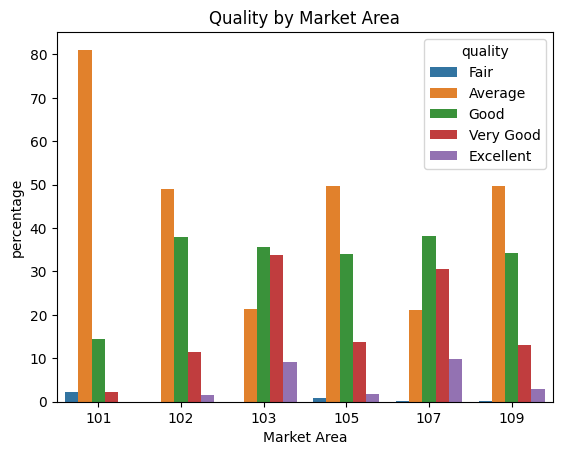

In [134]:
qual_eval= master_df[has_eval].groupby(['market_area', 'quality']).size().reset_index(name='count')
divisor = qual_eval.groupby('market_area')['count'].transform('sum')
qual_eval['percentage'] = qual_eval['count']/divisor*100


sns.barplot(data=qual_eval,
            x='market_area',
            y='percentage',
            hue='quality')
plt.title('Quality by Market Area')
plt.xlabel('Market Area')
plt.ylabel('percentage')
plt.show()

In an effort to refine the variables of interest for our KNN model, we return to the correlations from earlier and review the prices of homes with various basement types, to see if homes with finished basements are valued higher than those without. Based on these results, the data demonstrates that homes with additional square footage are valued higher on the market than those with less. We refine the scope of our analysis to focus on the finished area rather than the various forms this are takes.

In our EDA, we found the quality assessment useful as a surrogate for price, given the high correlation between the two variables. As such, we visualized the total square footage by quality measure, and the finished sq. footage by quality measure. Based on the relationship between the measures of center for both graphs we found that finished square footage was the more robust variable (mean is very close to median) to include in our model for predicting the sale price of a home.

In [135]:
#adj price correlated with total finished, enclosed sq ft, total prop sqft

high_corr_cols=['adjusted_sales_price', 'total_finished_sqft', 'enclosed_sqft_total', 'prop_overall_sqft', 'nbr_total_baths']

master_df[high_corr_cols].corr()


,adjusted_sales_price,total_finished_sqft,enclosed_sqft_total,prop_overall_sqft,nbr_total_baths
adjusted_sales_price,1.00,0.67,0.63,0.59,0.55
total_finished_sqft,0.67,1.00,0.64,0.42,0.69
enclosed_sqft_total,0.63,0.64,1.00,0.47,0.57
prop_overall_sqft,0.59,0.42,0.47,1.00,0.27
nbr_total_baths,0.55,0.69,0.57,0.27,1.00


In [136]:
#looking at basements based on finish type, since we see that finished square is so highly correlated with sale price
basement_type=master_df.groupby('bsmt_finish')
mean_adj_price_bsmt=basement_type['adjusted_sales_price'].mean()
mean_adj_price_bsmt=mean_adj_price_bsmt.apply(lambda x: f"{x:,.2f}")
mean_adj_price_bsmt


median_adj_price_bsmt=basement_type['adjusted_sales_price'].median()
median_adj_price_bsmt=median_adj_price_bsmt.apply(lambda x: f"{x:,.2f}")
median_adj_price_bsmt

mean_bsmt_conclusion = f"The mean adj price of home based on basement type is Finished: {mean_adj_price_bsmt['Finished']}, No Basement: {mean_adj_price_bsmt['No Basement']}, Unfinished: {mean_adj_price_bsmt['Unfinished']}"
mean_bsmt_conclusion

'The mean adj price of home based on basement type is Finished: 2,644,926.19, No Basement: 1,724,187.05, Unfinished: 2,180,833.59'

In [137]:
median_bsmt_conclusion=f"The median adj price of home based on basement type is Finished: {median_adj_price_bsmt['Finished']}, No Basement: {median_adj_price_bsmt['No Basement']}, Unfinished: {median_adj_price_bsmt['Unfinished']}"
median_bsmt_conclusion

#mean is def right skewed based on median information.
# BUT, even when using the median we see notably higher adj home prices among homes with finished basements.

'The median adj price of home based on basement type is Finished: 2,204,129.00, No Basement: 1,444,455.00, Unfinished: 1,848,120.00'

In [138]:
stats = master_df.groupby('quality', observed=True)['prop_overall_sqft'].agg(['mean', 'median', 'min', 'max', 'std', 'count'])

stats.drop('Fair')

#pretty stark diff here between property groups in terms of overall property sq footage.
#going to compare finished sqft among same groups. obv we can only use this directionally but there is a story emerging i think!

,mean,median,min,max,std,count
quality,,,,,,
Average,"7,323.23","7,363.00",992.00,"36,175.00","3,370.59",1409
Good,"9,629.16","8,203.00","1,082.00","204,403.00","9,507.30",1115
Very Good,"13,939.36","12,049.00","1,690.00","100,613.00","9,043.66",565
Excellent,"22,622.15","16,749.00","7,067.00","128,013.00","18,509.58",131


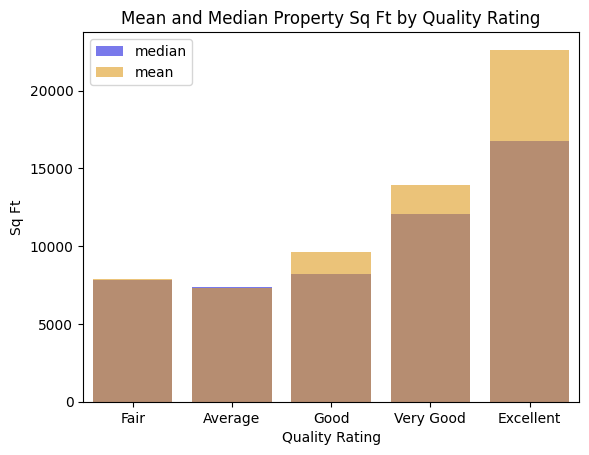

In [139]:
sns.barplot(stats, x='quality', y='median', alpha=.6, color='blue', label='median')
sns.barplot(stats, x='quality', y='mean', alpha=.6, color='orange', label='mean')

plt.title('Mean and Median Property Sq Ft by Quality Rating')
plt.xlabel('Quality Rating')
plt.ylabel('Sq Ft')
plt.show()

In [140]:
finished_stats = master_df.groupby('quality', observed=True)['total_finished_sqft'].agg(['mean', 'median', 'min', 'max', 'std', 'count'])

finished_stats.drop('Fair')

,mean,median,min,max,std,count
quality,,,,,,
Average,"1,476.05","1,392.00",424.00,"7,514.00",538.25,1513
Good,"2,108.36","2,042.00",493.00,"5,005.00",600.17,1170
Very Good,"3,014.10","2,979.00",391.00,"5,901.00",807.49,588
Excellent,"4,018.21","3,861.00",874.00,"8,734.00","1,147.26",137


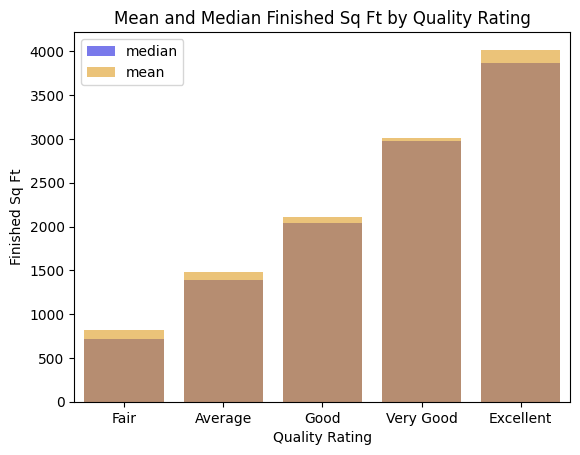

In [141]:
sns.barplot(finished_stats, x='quality', y='median', alpha=.6, color='blue', label='median')
sns.barplot(finished_stats, x='quality', y='mean', alpha=.6, color='orange', label='mean')

plt.title('Mean and Median Finished Sq Ft by Quality Rating')
plt.xlabel('Quality Rating')
plt.ylabel('Finished Sq Ft')
plt.show()

#we see that higher finished sq footage is associated with higher quality ranking. We know that price is affected by both the quality and the finished square footage.
#Will there look to see if construction style has a role.

# Part D - Statistical Inference





## Part D #1 - Hypothesis Testing

All of the following hypothesis tests have their own conditions for inference. However, every test includes the condition that the data must be a random sample which accurately reflects the population. The data included in this assessment was not randomly collected and we, the assessors, are unsure the extent to which data is missing from this sample or is incorrectly represented. Therefore, this is not a random sample that accurately reflects the population of homes in Boulder at this moment. We will continue with our statistical inference, however we caution all readers to note that all following conclusions will be made from biased data and therefore may not be representative of parameter values.

In [142]:
# review construction types
master_df['construction_type'].value_counts()

,count
construction_type,
Masonry,1745
Frame,1650
Brick,4
Wood,2
Steel,1


In [143]:
#among the most prevalent construction styles
mask=master_df['construction_type']=='Frame'
mask2=master_df['construction_type']=='Masonry'
combined_mask=mask|mask2
home_style= master_df[combined_mask].groupby(['quality','construction_type'], observed=True).size().reset_index(name='count')
total = home_style.groupby('quality')['count'].transform('sum')
home_style['percentage'] = home_style['count']/total*100

home_style

,quality,construction_type,count,percentage
0,Fair,Frame,12,92.31
1,Fair,Masonry,1,7.69
2,Average,Frame,725,48.08
3,Average,Masonry,783,51.92
4,Good,Frame,515,44.32
5,Good,Masonry,647,55.68
6,Very Good,Frame,314,54.33
7,Very Good,Masonry,264,45.67
8,Excellent,Frame,84,62.69
9,Excellent,Masonry,50,37.31


In [144]:
fair_mask=home_style['quality']=='Fair'
not_fair_mask=home_style['quality']!='Fair'
#looking specifically at masonry and framed homes, the most common build types
home_style

,quality,construction_type,count,percentage
0,Fair,Frame,12,92.31
1,Fair,Masonry,1,7.69
2,Average,Frame,725,48.08
3,Average,Masonry,783,51.92
4,Good,Frame,515,44.32
5,Good,Masonry,647,55.68
6,Very Good,Frame,314,54.33
7,Very Good,Masonry,264,45.67
8,Excellent,Frame,84,62.69
9,Excellent,Masonry,50,37.31


### Hypothesis Test - Are construction styles independent of quality scores?

$$
\begin{aligned}
    H_0: &\ \text{Construction styles are independent of quality score} \\
    H_a: &\ \text{Construction styles are not independent of quality scores}
\end{aligned}
$$

As mentioned, the random sample requirement for this test is not met, so we recommend that our results are used to direct further inquiry rather than large-scale changes to tax assessment procedures.
While the observed counts (shown below) are low, the expected counts are > 5, satisfying our conditions for inference for this test. Lastly, each observation pertains to one home, ensuring that no home contributes to both columns of data.

In [145]:
home_style[fair_mask]

,quality,construction_type,count,percentage
0,Fair,Frame,12,92.31
1,Fair,Masonry,1,7.69


In [146]:
home_style

table_quality_counts = home_style.pivot(index='quality', columns='construction_type', values='count').fillna(0)
chi2, p, dof, expected = chi2_contingency(table_quality_counts.values)

chi2

36.855960762850884

In [147]:
expected

array([[  6.31811487,   6.68188513],
       [732.90132548, 775.09867452],
       [564.74226804, 597.25773196],
       [280.91310751, 297.08689249],
       [ 65.12518409,  68.87481591]])

In [148]:
p

# at the 95% level, we have evidence that construction style is not independent of the quality score
# So we reject the null hypothesis.

1.928667951777733e-07

At the 95% level, we have evidence that construction style is not independent of the quality score, so we reject the null hypothesis. Our result points to a statistically significant relationship between quality assessment and home type. We recommend returning to this conclusion and confirming when a random sample of all homes becomes available.

### Hypothesis Test - Are the home quality rankings uniform across all market areas?

$$
\begin{aligned}
    H_0: &\ \text{The home quality rankings are uniform across market areas} \\
    H_a: &\ \text{The home quality rankings are not uniform across market areas}
\end{aligned}
$$

Before conducting this test, we will confirm that the conditions for inference are met. We have addressed above the need for a random sample. We now need to show that the expected frequencies are at least 5.

In [149]:
#Create a dataframe with the observed count for each quality in each market area
ma_quality = master_df[['market_area','quality']].value_counts().reset_index()
ma_quality = ma_quality.rename(columns={'count':'observed'})

#Add in zero counts for missing quality values in each market area
ma_quality.loc[len(ma_quality)] = {'market_area': 101, 'quality': 'Excellent', 'observed': 0}
ma_quality.loc[len(ma_quality)] = {'market_area': 102, 'quality': 'Fair', 'observed': 0}
ma_quality.loc[len(ma_quality)] = {'market_area': 103, 'quality': 'Fair', 'observed': 0}

num_mkt_area = len(ma_quality.market_area[ma_quality.market_area.notna()].unique())
num_quality = len(ma_quality.quality[ma_quality.quality.notna()].unique())
num_observations = sum(ma_quality.observed)

print(f'Number of Market Areas: {num_mkt_area}')
print(f'Number of Quality Scores: {num_quality}')
print(f'Number of Observations: {num_observations}')
print(f'Expected count for each market area and quality is {num_observations/(num_mkt_area*num_quality)}')

Number of Market Areas: 6
Number of Quality Scores: 5
Number of Observations: 3236
Expected count for each market area and quality is 107.86666666666666


The expected count is 107.9, which is greater than 5. Therefore, our conditions for inference have been met and we can proceed with the hypothesis test.

In [150]:
#Add quality ordering into the df for simplicity
ma_quality['quality'] = ma_quality['quality'].astype('category')
ma_quality['quality'] = ma_quality['quality'].cat.reorder_categories(['Fair', 'Average', 'Good', 'Very Good', 'Excellent'], ordered=True)

#Sort the df by market_area and quality rating
ma_quality = ma_quality.sort_values(by=['market_area', 'quality'])

#Add expected column with uniformly distributed counts
ma_quality['expected'] = sum(ma_quality.observed) / 30 #We use 30 because we have 5 levels of quality and 6 market areas

Now that we have a dataframe with the observed and expected counts, we can calculate the chi-squared test statistic and p-value

In [151]:
#Calculate the chi-squared test statistic
from scipy.stats import chi2
test_stat = sum((ma_quality.observed - ma_quality.expected)**2 / ma_quality.expected)
p_val = 1-chi2.cdf(test_stat, ma_quality.shape[0]-1)
print(f'The chi-squared test statistic is {round(test_stat,2)} and the p-value is {round(p_val,4)}.')

The chi-squared test statistic is 3794.35 and the p-value is 0.0.


Since the p-value is extremely small (near zero), we reject the null hypothesis and conclude that we have evidence to believe quality rankings are not uniform across market areas. We recommend returning to this conclusion and confirming when a random sample of all homes becomes available.

### Hypothesis Test - Are new homes more expensive than old homes on average?

$$
\begin{aligned}
    H_0: &\ \ \mu_{new} = \mu_{old} \\
    H_a: &\ \ \mu_{new} > \mu_{old} \\
\end{aligned}
$$

In this test, $ \mu_{new} $ is the average sales prices for homes that are 10 years old or younger and $ \mu_{old} $ is the average sales prices for homes that are older than 10.

First we will check our conditions for inference. We do not know if these distributions are normal and so we will take a look at the distribution of prices in each group.

We have 442 new homes
We have 2986 old homes


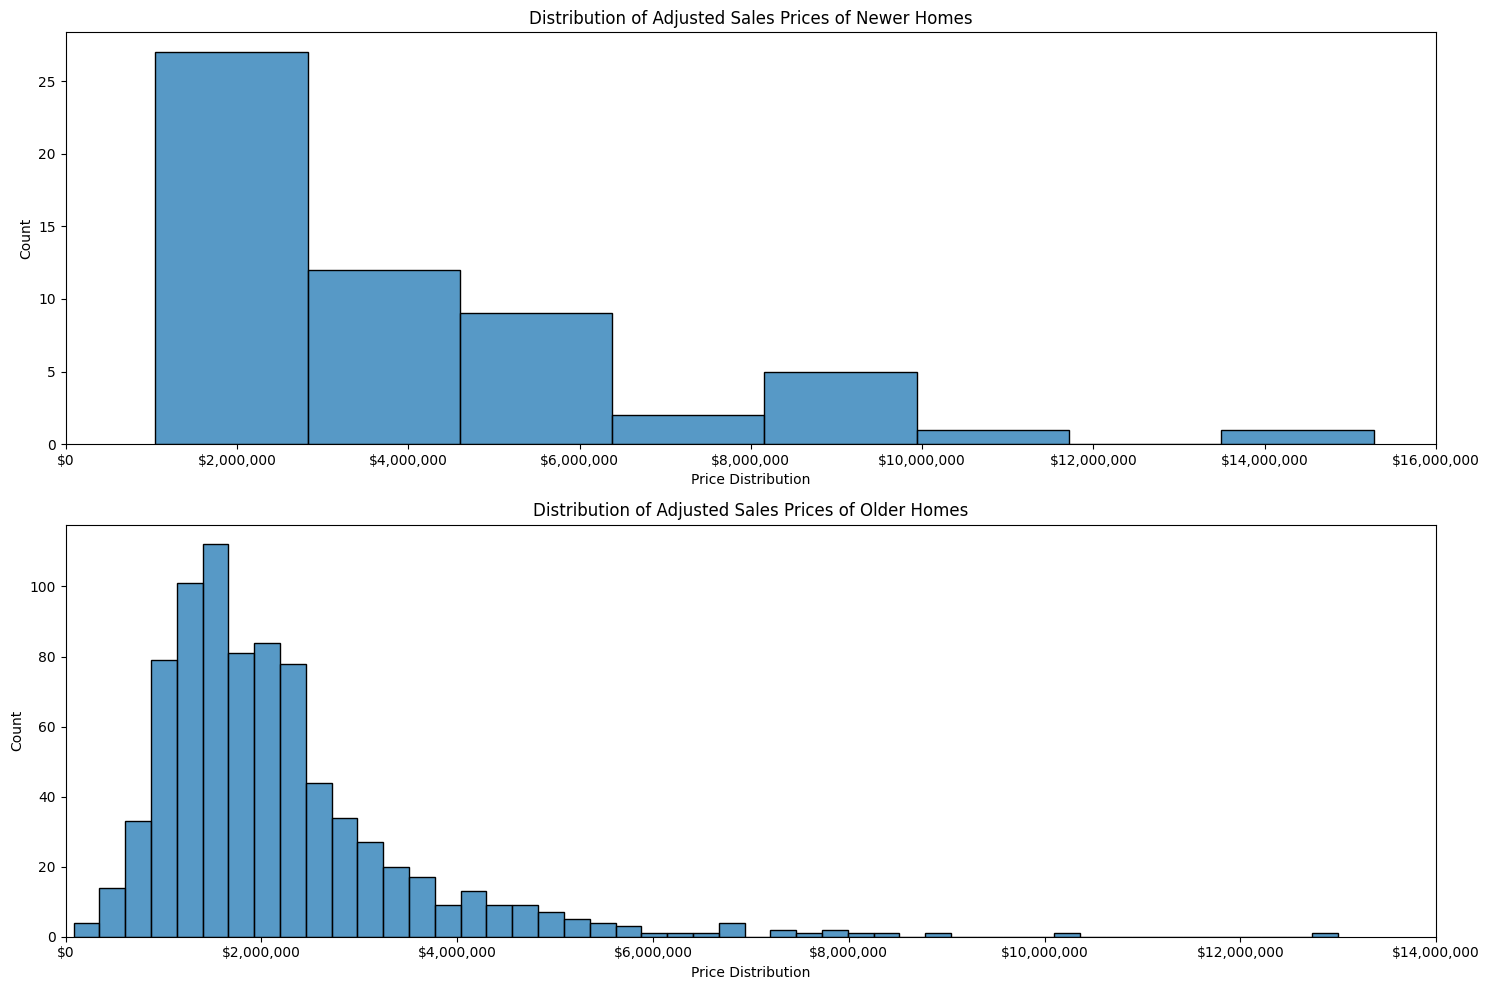

In [152]:
fig, (a, b) = plt.subplots(2, 1, sharex=False, figsize=(15, 10))

#Create a histogram of adjusted_sales_price for new homes
sns.histplot(x = 'adjusted_sales_price',
            data = master_df[master_df.age_of_home <= 10],
            ax=a)

#Add axis labels and title
a.set_xlabel('Price Distribution')
a.set_ylabel('Count')
a.set_title('Distribution of Adjusted Sales Prices of Newer Homes')

#Format xticks with commas and dollar signs
a.set_xticks(a.get_xticks())
a.set_xticklabels([f'${y:,.0f}' for y in a.get_xticks()])

#Format graph so that the prices begin at $0
a.set_xlim(left=-100)

#Create a histogram of adjusted_sales_price for old homes
sns.histplot(x = 'adjusted_sales_price',
            data = master_df[master_df.age_of_home > 10],
            ax=b)

#Add axis labels and title
b.set_xlabel('Price Distribution')
b.set_ylabel('Count')
b.set_title('Distribution of Adjusted Sales Prices of Older Homes')

#Format xticks with commas and dollar signs
b.set_xticks(b.get_xticks())
b.set_xticklabels([f'${y:,.0f}' for y in b.get_xticks()])

#Format graph so that the prices begin at $0
b.set_xlim(left=-100)

plt.tight_layout()

print(f'We have {len(master_df.adjusted_sales_price[master_df.age_of_home <= 20])} new homes')
print(f'We have {len(master_df.adjusted_sales_price[master_df.age_of_home > 20])} old homes')

Neither set of data is normally distributed, however the sample size is very large so by the central limit theorem, we can conclude that the sampling distribution of sample means is normal. Therefore, our conditions for inference are met and we can conduct a hypothesis test for two independent means with a large sample.

In [153]:
#Make array values for the prices from each set
new_homes = np.array(master_df.adjusted_sales_price[(master_df.age_of_home <=10) &
                     (master_df.age_of_home.notna()) &
                     (master_df.adjusted_sales_price.notna())])
old_homes = np.array(master_df.adjusted_sales_price[(master_df.age_of_home > 10) &
                     (master_df.age_of_home.notna()) &
                     (master_df.adjusted_sales_price.notna())])

#Run the t-test
t_statistic, p_value = ttest_ind(new_homes, old_homes, alternative="greater", equal_var=False)
print(f'The test statistic is {round(t_statistic, 4)} and the p-value is {round(p_value, 4)}.')

The test statistic is 4.5576 and the p-value is 0.0.


Since the p-value is extremely small (near zero), we reject the null hypothesis and conclude that we have evidence to believe newer homes have a higher adjusted sales price than older homes. We recommend returning to this conclusion and confirming when a random sample of all homes becomes available.

### Hypothesis Test - Independence between Market Area and Price

$$
\begin{aligned}
    H_0: &\ \text{The price bucket and market area values are independent} \\
    H_a: &\ \text{The price bucket and market area values are not independent}
\end{aligned}
$$

We would like to test the relationship between the market area and adjusted sales price. However, a hypothesis test between a categorical and quantiative variable is outside of the scope of this class. Therefore, we will bucket the adjusted sales prices into categories and test the independence of market area and price category.

In [154]:
master_df['price_buckets'] = pd.cut(master_df.adjusted_sales_price[master_df.adjusted_sales_price.notna()],
                                    bins=[-1,1000000,2000000,3000000,4000000,1000000000],
                                    labels=['Less than $1 million','$1 - 2 million','$2 - 3 million','$3 - 4 million','Over $4 million'])

#Create a contingency table for the price buckets and market area
ma_price = pd.crosstab(index=master_df['market_area'],
                      columns=master_df['price_buckets'])

Now that we have the prices organized into categories, we must check if the expected value counts are at least five as our condition for inference.

In [155]:
#Use the chi2_contingency function to calculate the expected frequency table
chi2_contingency(ma_price, correction = False).expected_freq

array([[  5.86062718,  25.86759582,  15.08943089,   5.2543554 ,
          5.92799071],
       [ 23.54355401, 103.91637631,  60.61788618,  21.10801394,
         23.81416957],
       [ 14.44947735,  63.77700348,  37.20325203,  12.95470383,
         14.6155633 ],
       [ 12.63066202,  55.74912892,  32.5203252 ,  11.32404181,
         12.77584204],
       [ 10.81184669,  47.72125436,  27.83739837,   9.69337979,
         10.93612079],
       [ 19.70383275,  86.96864111,  50.73170732,  17.66550523,
         19.93031359]])

All values in the expected frequency table are above five and so the conditions for inference are met.

In [156]:
#Perform the chi-squared test for independence
chi_test = chi2_contingency(ma_price, correction = False)

print(f'The chi-squared test statistic is {round(chi_test.statistic,4)} and the p-value is {round(chi_test.pvalue,4)}.')

The chi-squared test statistic is 218.1305 and the p-value is 0.0.


Since the p-value is extremely small (near zero), we reject the null hypothesis and conclude that we have evidence to believe the price bucket and the market area variables are not independent of each other. We recommend returning to this conclusion and confirming when a random sample of all homes becomes available.

## 2 - Bootstrap Confidence Interval

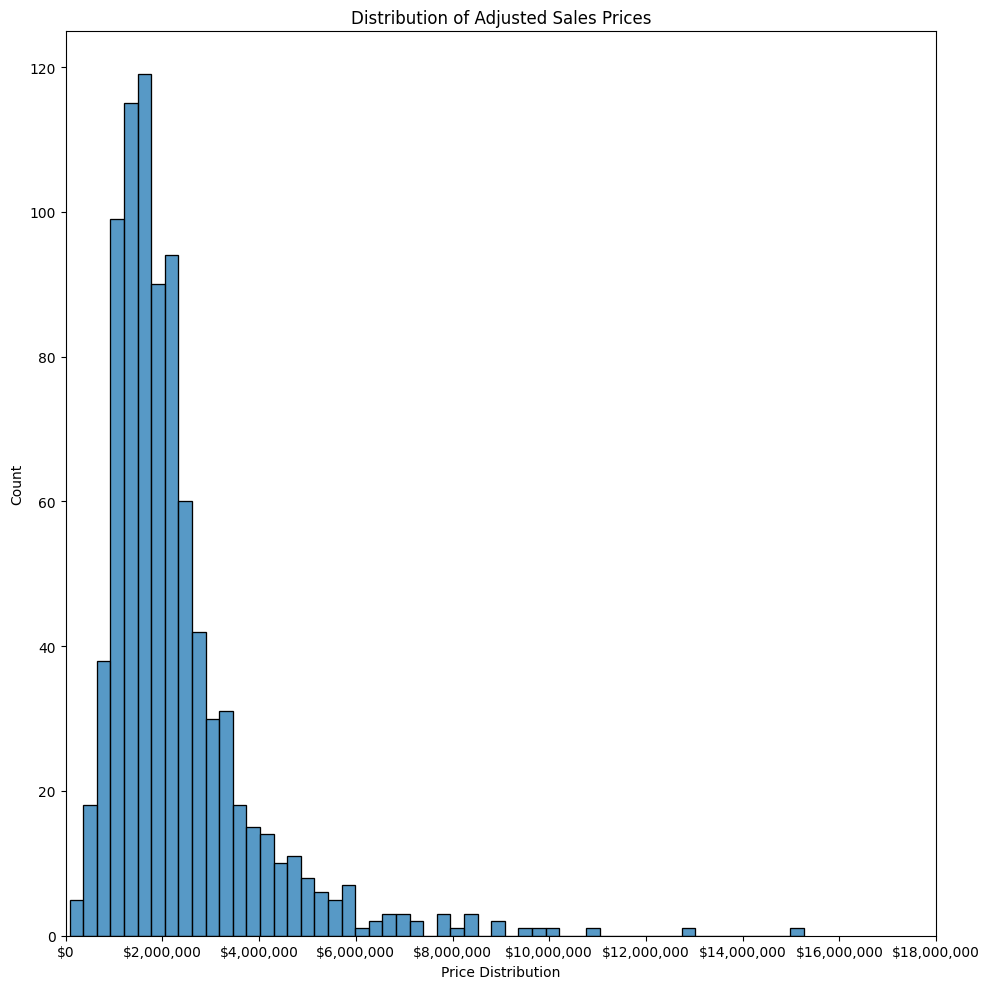

In [157]:
fig, axes = plt.subplots(figsize=(10, 10))

#Create a histogram of adjusted_sales_price
sns.histplot(x = 'adjusted_sales_price',
            data = master_df)

#Add axis labels and title
axes.set_xlabel('Price Distribution')
axes.set_ylabel('Count')
axes.set_title('Distribution of Adjusted Sales Prices')

#Format xticks with commas and dollar signs
axes.set_xticks(axes.get_xticks())
axes.set_xticklabels([f'${y:,.0f}' for y in axes.get_xticks()])

#Format graph so that the prices begin at $0
axes.set_xlim(left=-100)

plt.tight_layout()

1. The median value would be more useful to the assessor because the median is less affected than the mean by outliers. In this distribution there are some extreme outliers that will increase the value of the mean away from the center of the distribution. Therefore, in this case, it would be beneficial to use the median because the exterme outliers will have less of an affet on it and therefore the median will better represent the center of the data.
2. The human impact of using the median instead of the mean is that the outliers will be considered even more extreme when compared to the median than the mean. Additionally, policy makers will have less information about the outliers, which can be useful. For example, if the distribution included a handful of low outliers that are less influential on the median, policy makers may not be aware of low-income houses or areas that are decreasing in value. This can be helpful information for government officials as they consider city planning and budget allocation.

In [158]:
#Create an array of price values
prices = np.array(master_df.adjusted_sales_price[master_df.adjusted_sales_price.notna()])
num_prices = len(prices)

#Set seed for reproducibility
random.seed(2846)
iters = 1000
median_vals = np.full((iters, 1), np.nan)

#Randomly choose values from the curret set of data and find the median of the set.
for i in range(iters):
    median_vals[i] = statistics.median(random.choices(prices, k=num_prices))

#Calculate the statistics needed for the confidence interval calculation
med = statistics.median(median_vals)
sd = median_vals.std()
n = len(median_vals)
t = abs(t.ppf(.025, n-1))

#Perform the confidence interval calculation
upper = med+(t*sd/math.sqrt(n))
lower = med-(t*sd/math.sqrt(n))

print(f'The 95% Confidence Interval is ({round(lower[0],4)},{round(upper[0],4)})')

The 95% Confidence Interval is (1891645.311,1897594.689)


We are 95% confident that the true median value for the property value is between `$1,891,645 and $1,8975,94`. This means that if used 100 samples and repeated our methods to create 100 intervals, 95 of them would include the actual population median value. Therefore, we can not be certain that this interval does include the true median, but we can be 95% confident.

# Part E - Predicting Home Values
Implement a custom K-Nearest Neighbors (KNN) Regression model from scratch.

After discussing the various findings in sections C and D, we determined that the variables that seem most important and also don't overlap with one another are:
- Total finished square feet
- Land acreage
- Age of home

We'll now build a KNN model using the variables to predict prices based on market area.

First, let's created a filtered dataframe to run through the model. As requested in the assignment instructions, we will limit the dataset to "Qualified" sales. We have also dropped any rows where we did not have an adjusted_sales_price as those rows will not help our model make predictions.

In [159]:
# Filtered Dataframe for the Algorithm
qualified_sales = master_df[master_df.sales_cd_dscr == "Qualified"].copy()
filtered_df_for_knn = qualified_sales[['adjusted_sales_price', 'market_area', 'total_finished_sqft', 'land_acreage', 'age_of_home', 'total_appraised_val_2024']].copy()
filtered_df_for_knn.rename(columns={'adjusted_sales_price' : 'price', 'total_finished_sqft': 'finished_sqft'}, inplace=True)
filtered_df_for_knn = filtered_df_for_knn.dropna(subset=['price'])
filtered_df_for_knn.sample(5)

,price,market_area,finished_sqft,land_acreage,age_of_home,total_appraised_val_2024
strap,,,,,,
R0004268,"1,451,000.00",102,"1,170.00",0.18,49.00,"1,369,100.00"
R0009069,"1,728,335.00",105,"1,724.00",0.04,29.00,"1,475,800.00"
R0088954,"1,460,000.00",105,"1,616.00",0.07,49.00,"1,178,900.00"
R0004157,"2,143,800.00",109,"3,009.00",0.17,21.00,"2,296,700.00"
R0004222,"1,624,896.00",102,"3,079.00",0.13,49.00,"1,759,900.00"


In [160]:
filtered_df_for_knn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 683 entries, R0000027 to R0616832
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   price                     683 non-null    float64 
 1   market_area               683 non-null    category
 2   finished_sqft             681 non-null    float64 
 3   land_acreage              683 non-null    float64 
 4   age_of_home               683 non-null    float64 
 5   total_appraised_val_2024  683 non-null    float64 
dtypes: category(1), float64(5)
memory usage: 32.9+ KB


In [161]:
filtered_df_for_knn.describe()

,price,finished_sqft,land_acreage,age_of_home,total_appraised_val_2024
count,683.00,681.00,683.00,683.00,683.00
mean,"2,285,041.73","2,042.44",0.18,33.44,"2,095,072.27"
std,"1,509,985.29",965.76,0.15,14.72,"1,164,145.09"
min,"562,216.80",510.00,0.00,2.00,"516,600.00"
25%,"1,354,286.25","1,352.00",0.12,24.00,"1,342,650.00"
50%,"1,883,035.80","1,848.00",0.15,34.00,"1,792,500.00"
75%,"2,646,373.75","2,458.00",0.21,44.00,"2,448,600.00"
max,"13,000,000.00","7,514.00",2.21,119.00,"8,644,100.00"


There is plenty of detail in the function below but at a high level we're going to take a df, select a market area, and then input values for 3 variables of interest and use them to make a prediction about the price.

In [162]:
# KNN Function
from matplotlib.ticker import FuncFormatter

def knn_3d_minmax(df, k, market_area, finished_sqft, land_acreage, age_of_home, visualize=False, summary=False):
    """
    KNN regression using min-max scaling for features (finished_sqft, land_acreage, age_of_home) to predict price.

    Input:
        - df - DataFrame with 'price', 'market_area', 'finished_sqft', 'land_acreage', and 'age_of_home' columns.
        - k - Number of neighbors to consider.
        - market_area - One of the residential market areas in the county: [101, 102, 103, 105, 107, 109].
        - finished_sqft - Number of finished square feet.
        - land_acreage - Land acreage for the property.
        - age_of_home - The age of the home in years.
        - visualize - T/F whether to visualize the results.
        - summary - T/F whether to return a df of the k nearest neighbors used for prediction.

    Output:
        - Predicted price of home (and optionally, a visualization and summary including nearest neighbors).
    """

    # List of valid market areas
    valid_market_areas = [101, 102, 103, 105, 107, 109]

    # Validate market area
    if market_area not in valid_market_areas:
        return {
            "error": f"Invalid market area: {market_area}.",
            "valid_market_areas": valid_market_areas
        }

    # Filter dataset by market area
    df_temp = df[df['market_area'] == market_area].copy()

    # Extract features for scaling
    features = df_temp[['finished_sqft', 'land_acreage', 'age_of_home']]

    # Min-max scaling of the df
    min_vals = features.min()
    max_vals = features.max()
    scaled_features = (features - min_vals) / (max_vals - min_vals)
    df_temp[['scaled_finished_sqft', 'scaled_land_acreage', 'scaled_age_of_home']] = scaled_features

    # Min-max scaling of the target values
    target = [
        (finished_sqft - min_vals['finished_sqft']) / (max_vals['finished_sqft'] - min_vals['finished_sqft']),
        (land_acreage - min_vals['land_acreage']) / (max_vals['land_acreage'] - min_vals['land_acreage']),
        (age_of_home - min_vals['age_of_home']) / (max_vals['age_of_home'] - min_vals['age_of_home'])
    ]

    # Compute distances
    actual = df_temp[['scaled_finished_sqft', 'scaled_land_acreage', 'scaled_age_of_home']].to_numpy()
    df_temp['distance'] = np.sqrt(np.sum((actual - target)**2, axis=1))

    # Get k-nearest neighbors
    df_knn = df_temp.loc[df_temp.distance.nsmallest(k).index]

    # Predict price
    y_pred = df_knn.price.mean().round()

    # Visualization if requested
    if visualize:
        figure, axes = plt.subplots(1, 1, figsize=(8, 6))
        axes.axvline(finished_sqft, color='lightgrey', linestyle='dashed')
        axes.scatter(df_temp.finished_sqft, df_temp.price, color='lightblue', label="All data points in Mkt")
        axes.scatter(df_knn.finished_sqft, df_knn.price, color='red', label=f"{k} Nearest Neighbors")
        axes.scatter(
            finished_sqft, y_pred,
            color='black', marker='x', s=75, label=f"Prediction: ${y_pred:,.0f}"
        )
        axes.set_title(
            f"Prediction for Market Area {market_area}:\n{finished_sqft} ft², {land_acreage} acres, {age_of_home} year old home",
            fontsize=16
        )
        axes.set_xlabel("Finished Square Feet ($ft^2$)")
        axes.set_ylabel("Price")
        axes.legend()

        # Format y-axis as millions
        axes.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x * 1e-6:.1f}M"))
        plt.tight_layout()
        plt.show()

    # Return summary if requested
    if summary:
        return {
            "Predicted_Price": f"${y_pred:,.0f}",
            "nearest_neighbors": df_knn[['price', 'finished_sqft', 'land_acreage', 'age_of_home']]
        }

    # Return predicted price
    return y_pred

### Please use the code block below to run tests of our model.

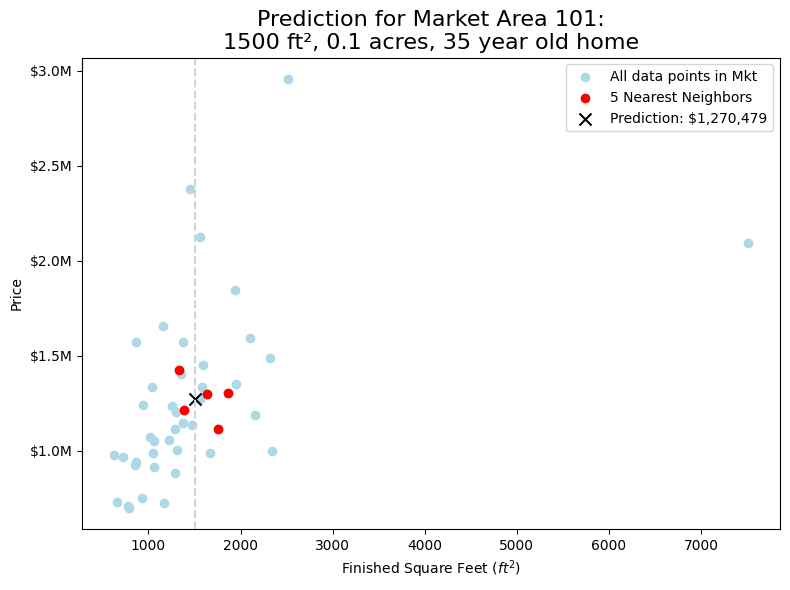

{'Predicted_Price': '$1,270,479',
 'nearest_neighbors':                 price  finished_sqft  land_acreage  age_of_home
 strap                                                          
 R0003461 1,305,894.50       1,868.00          0.10        34.00
 R0002935 1,112,838.00       1,756.00          0.10        39.00
 R0006763 1,297,069.80       1,632.00          0.12        34.00
 R0002794 1,211,595.00       1,390.00          0.08        34.00
 R0008280 1,425,000.00       1,332.00          0.12        34.00}

In [163]:
# Test the model
knn_3d_minmax(
    filtered_df_for_knn,
    k = 5,
    market_area= 101,
    finished_sqft = 1500,
    land_acreage = 0.1,
    age_of_home = 35,
    summary = True,
    visualize = True)

The visualization that is generated is only in 2 dimensions, so it is showing finished square feet on the x-axis and price on the y-axis. However, we are using two other variables to make the prediction. We would need a 4-dimensional chart to properly show that, which is not possible. This is why some of the red marks may appear a little farther away from our predicted value.

As a final step, let's run the function over our entire data frame and add a column for the predicted results.

In [164]:
# Run function over entire df and a column with the result
def predict_price(row):
    return knn_3d_minmax(
        df=filtered_df_for_knn,
        k=5,
        market_area=row['market_area'],
        finished_sqft=row['finished_sqft'],
        land_acreage=row['land_acreage'],
        age_of_home=row['age_of_home'],
        visualize=False,
        summary=False
    )

# Add predicted prices to the test DataFrame
filtered_df_for_knn['predicted_price'] = filtered_df_for_knn.apply(predict_price, axis=1)
filtered_df_for_knn.sample(5)

,price,market_area,finished_sqft,land_acreage,age_of_home,total_appraised_val_2024,predicted_price
strap,,,,,,,
R0004194,"8,947,440.00",103,"3,996.00",0.40,10.00,"7,533,200.00","6,458,530.00"
R0002754,"976,620.00",109,"1,096.00",0.16,119.00,"1,125,000.00","1,317,405.00"
R0076481,"2,290,008.00",105,"2,824.00",0.00,37.00,"1,929,800.00","2,741,059.00"
R0007226,"1,486,660.50",102,"1,226.00",0.07,24.00,"1,328,800.00","1,414,760.00"
R0008294,"1,309,440.00",102,"1,639.00",0.18,34.00,"1,510,900.00","1,536,838.00"


In [165]:
# Check for difference between appraised values and predicted values
f"${(filtered_df_for_knn.total_appraised_val_2024 - filtered_df_for_knn.predicted_price).mean():,.0f}"

'$-137,444'

Using the predictions we have created it looks like on average, the appraised 2024 values are around $137k lower per house than our predicted values. **This would indicate that there is an opportunity for the county to better appraise homes and therefore collect additional tax revenues.**

# Part F - Present Your Results
Please see slide deck for more information about our findings.

# Summary

Throughout this analysis we found that the market area, finished square feet, land acreage, and age of the home are most influential on the valuation of the home. We have utilized these values to build a KNN model for predicting valuation of a property and believe this model will be useful for policy makers going forward. For next steps, we suggest a deeper exploration of the influential variables. This could include a hypothesis test about whether the price is independent of market area and a deeper exploration of market area to determine the factors between areas that cause prices to differ. We recommend returning to this analysis in the next odd-yeared interval with a more robust data set to facilitate the statistical analysis conducted for this project and ensure accurate tax-assessments in subsequent years.

In [166]:
!jupyter nbconvert --to html group1_final_project_v2.ipynb

[NbConvertApp] Converting notebook group1_final_project_v2.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 49 image(s).
[NbConvertApp] Writing 3938270 bytes to group1_final_project_v2.html
